## Imports and Setup

In [1]:

import sys
import pandas as pd
import numpy as np
import torch
from pathlib import Path
import numpy as np
from tqdm import tqdm
import logging
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredOffsetbox, TextArea, VPacker, HPacker, DrawingArea
from matplotlib.patches import Rectangle
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.patheffects as pe
import seaborn as sns
import random
import pickle
import wandb
from collections.abc import Mapping
import gtfparse

import matplotlib.patches as mpatches

from torch.utils.data import Dataset, DataLoader, Subset

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    auc
)

logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s')

PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER")
DATA_DIR = PROJECT_DIR / "cached_data"
CHKPT_DIR = PROJECT_DIR / "checkpoints"
RESULT_DIR = PROJECT_DIR / "testing_results"

sys.path.append(str(PROJECT_DIR))

import scripts.train_tf_to_dna_model as tf_dna_train
import models.tf_to_tg as tf_to_tg_module
import plotting_utils
import stat_utils
import utils
import warnings
import config

if torch.cuda.is_available():
    device = torch.device("cuda")
    logging.info(f"Using GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision("high")
else:
    device = torch.device("cpu")
    logging.info("Using CPU")

warnings.filterwarnings(
    "ignore",
    message="You are using `torch.load` with `weights_only=False`.*",
    category=FutureWarning,
)

font_path = PROJECT_DIR / "fonts" / "Arial.ttf"

fm.fontManager.addfont(font_path)
arial_font = fm.FontProperties(fname=font_path).get_name()

mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = [arial_font, "Helvetica", "Liberation Sans", "DejaVu Sans"]

logging.info(f"Using font: {arial_font}")

rng = np.random.default_rng()

INFO:root:Using CPU
INFO:root:Using font: Arial


### Formatting Dictionaries

In [2]:
OWN_MODEL_METHOD = "TF-TG Model (own test set)"
CROSS_MODEL_METHOD = "TF-TG Model (cross-trained)"

TFTG_MODEL_METHODS = [
    OWN_MODEL_METHOD,
    CROSS_MODEL_METHOD,
]

method_display_name_map = {
    OWN_MODEL_METHOD: "TF-TG Own",
    CROSS_MODEL_METHOD: "TF-TG Cross",
}

sample_order = [
    "E7.5_rep1",
    "E8.5_rep1",
    "buffer_1",
    "buffer_2",
    "sample_1",
    "hepatocytes_1",
    "hepatocytes_3",
]

sample_rename_map = {
    "E7.5_rep1": "mESC-1",
    "E8.5_rep1": "mESC-2",
    "buffer_1": "Macrophage-1",
    "buffer_2": "Macrophage-2",
    "sample_1": "K562",
    "hepatocytes_1": "Hepatocytes-1",
    "hepatocytes_3": "Hepatocytes-2",

    OWN_MODEL_METHOD: "MTGRN-STM", #"TF-TG Model\n(Own)",
    CROSS_MODEL_METHOD: "MTGRN-CTM", #"TF-TG Model\n(Cross)",
}

sample_color_map = {
    "E7.5_rep1": "#4195df",
    "E8.5_rep1": "#86C7E7",
    "buffer_1": "#EF767A",
    "buffer_2": "#F9C60D",
    "sample_1": "#EF9CFA",
    "hepatocytes_1": "#82EC32",
    "hepatocytes_3": "#F98637",
}

method_color_dict = {
    OWN_MODEL_METHOD: "#4195df",
    CROSS_MODEL_METHOD: "#86C7E7",
    "LINGER": "#EF767A",
    "CellOracle": "#F9C60D",
    "Pando": "#EF9CFA",
    "SCENIC+": "#82EC32",
    "FigR": "#FDA7BB",
    "GRaNIE": "#F98637",
}

# method_color_dict = {
#     OWN_MODEL_METHOD: "#1f78b4",
#     CROSS_MODEL_METHOD: "#a6cee3",
#     "LINGER": "#fb9a99",
#     "CellOracle": "#fdbf6f",
#     "Pando": "#cab2d6",
#     "SCENIC+": "#b2df8a",
#     "FigR": "#ffff99",
# }

org_dict = {
    "E7.5_rep1": ("mouse", "mESC"),
    "E8.5_rep1": ("mouse", "mESC"),
    "buffer_1": ("human", "Macrophage"),
    "buffer_2": ("human", "Macrophage"),
    "hepatocytes_1": ("mouse", "mouse_hepatocytes"),
    "hepatocytes_3": ("mouse", "mouse_hepatocytes"),
    "sample_1": ("human", "K562"),
    "WT_D13_rep1": ("human", "iPSC")
}

models_to_plot = [
    "E7.5_rep1",
    "E8.5_rep1",
    "buffer_1",
    "buffer_2",
    "sample_1",
    "hepatocytes_1",
    "hepatocytes_3",
]

all_figure_axes = {}

### Paths

In [3]:
tf_tg_input_cache_dir = DATA_DIR / "tf_tg_training_cache"

score_label_save_dir = RESULT_DIR / "model_generalizability" / "labeled_grns"
score_label_save_dir.mkdir(parents=True, exist_ok=True)

method_comparison_boxplot_dir = PROJECT_DIR / "plots" / "model_vs_other_method_boxplots"
method_comparison_boxplot_dir.mkdir(exist_ok=True, parents=True)

lift_boxplot_dir = method_comparison_boxplot_dir / "lift_boxplots"
lift_boxplot_dir.mkdir(parents=True, exist_ok=True)

model_vs_other_method_curve_dir = PROJECT_DIR / "plots" / "model_vs_other_method_auroc_auprc_curves"
model_vs_other_method_curve_dir.mkdir(exist_ok=True, parents=True)

generalizability_plot_dir = PROJECT_DIR / "plots" / "generalizability"
generalizability_plot_dir.mkdir(parents=True, exist_ok=True)

feature_ablation_plot_dir = PROJECT_DIR / "plots" / "feature_ablation"
feature_ablation_plot_dir.mkdir(parents=True, exist_ok=True)

tf_dna_plots = PROJECT_DIR / "plots" / "tf_dna_binding_plots"
tf_dna_plots.mkdir(parents=True, exist_ok=True)

roc_plot_dir = PROJECT_DIR / "plots" / "roc_curves"
roc_plot_dir.mkdir(parents=True, exist_ok=True)

auprc_plot_dir = PROJECT_DIR / "plots" / "auprc_plots"
auprc_plot_dir.mkdir(parents=True, exist_ok=True)

rank_plot_dir = PROJECT_DIR / "plots" / "rank_plots"
rank_plot_dir.mkdir(parents=True, exist_ok=True)

rank_bar_plot_dir = rank_plot_dir / f"rank_barplots"
rank_lollipop_plot_dir = rank_plot_dir / f"rank_lollipop_plots"
rank_heatmap_plot_dir = rank_plot_dir / f"rank_heatmaps"
rank_boxplot_plot_dir = rank_plot_dir / f"rank_boxplots"

rank_bar_plot_dir.mkdir(parents=True, exist_ok=True)
rank_lollipop_plot_dir.mkdir(parents=True, exist_ok=True)
rank_heatmap_plot_dir.mkdir(parents=True, exist_ok=True)
rank_boxplot_plot_dir.mkdir(parents=True, exist_ok=True)

grn_sizes_by_method_dir = PROJECT_DIR / "plots" / "grn_sizes_by_method"
grn_sizes_by_method_dir.mkdir(parents=True, exist_ok=True)

other_method_stability_grn_dir = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.GRN_BENCHMARKING.MOELLER/multiGRNtools/stability_formatted_GRNs")
stability_result_dir = RESULT_DIR / "stability_evaluation"

stability_plot_dir = PROJECT_DIR / "plots" / "stability"
stability_plot_dir.mkdir(parents=True, exist_ok=True)

scalability_plot_dir = PROJECT_DIR / "plots" / "scalability"
scalability_plot_dir.mkdir(parents=True, exist_ok=True)

tf_dna_prediction_eval_dir = RESULT_DIR / "tf_dna_prediction_eval_data"
tf_dna_prediction_eval_dir.mkdir(parents=True, exist_ok=True)



# Plot showing how the model performs on its own test set, on other samples, on other cell types, and on other species
performance_across_evaluation_sets_plot_path = generalizability_plot_dir / "mean_performance_across_evaluation_sets.png"

# One subplot for each sample
auroc_models_vs_test_set_individual_plot_path = roc_plot_dir / "models_vs_own_test_set_auroc.png"

# Combined plot for all samples (one curve per sample)
auroc_models_vs_test_set_all_samples_plot_path = roc_plot_dir / "models_vs_own_test_set_auroc_combined.png"
auprc_models_vs_test_set_all_samples_plot_path = auprc_plot_dir / "models_vs_own_test_set_auprc_combined.png"
auprc_lift_models_vs_test_set_all_samples_plot_path = auprc_plot_dir / "models_vs_own_test_set_auprc_lift_combined.png"

# PRC curves for our model vs other methods, one figure per sample
model_vs_other_method_prc_curve_fig_dir = model_vs_other_method_curve_dir / "prc_curve_figs"
model_vs_other_method_prc_curve_fig_dir.mkdir(parents=True, exist_ok=True)

# ROC curves for our model vs other methods, one figure per sample
model_vs_other_method_roc_curve_fig_dir = model_vs_other_method_curve_dir / "roc_curve_figs"
model_vs_other_method_roc_curve_fig_dir.mkdir(parents=True, exist_ok=True)


### Load TF-TG model checkpoints

In [4]:
tf_tg_model_checkpoints = {
    "mESC": {
        "E7.5_rep1": CHKPT_DIR / "mESC" / "E7.5_rep1" / "tf_tg_train_E7.5_rep1_3675131" / "epoch_11_best_model.ckpt",
        # "E7.5_rep1": utils.find_latest_checkpoint(CHKPT_DIR, "mESC", "E7.5_rep1"),
        "E7.5_rep2": utils.find_latest_checkpoint(CHKPT_DIR, "mESC", "E7.5_rep2", training_number="3696113"),
        "E8.5_rep1": utils.find_latest_checkpoint(CHKPT_DIR, "mESC", "E8.5_rep1", training_number="3691937"),
        # "E8.5_rep2": utils.find_latest_checkpoint(CHKPT_DIR, "mESC", "E8.5_rep2"),
    },
    "iPSC": {
        "WT_D13_rep1": utils.find_latest_checkpoint(CHKPT_DIR, "iPSC", "WT_D13_rep1", training_number="3709598"),
    },
    "Macrophage": {
        "buffer_1": utils.find_latest_checkpoint(CHKPT_DIR, "Macrophage", "buffer_1", training_number="3685893"),
        "buffer_2": utils.find_latest_checkpoint(CHKPT_DIR, "Macrophage", "buffer_2", training_number="3713132"),
        "buffer_3": utils.find_latest_checkpoint(CHKPT_DIR, "Macrophage", "buffer_3", training_number="3704579"),
        "buffer_4": utils.find_latest_checkpoint(CHKPT_DIR, "Macrophage", "buffer_4", training_number="3696147"),
    },
    "K562": {
        "sample_1": utils.find_latest_checkpoint(CHKPT_DIR, "K562", "sample_1", training_number="3692409"),
    },
    "mouse_liver": {
        "liver_1": utils.find_latest_checkpoint(CHKPT_DIR, "mouse_liver", "liver_1", training_number="3708415"),
        "liver_3": utils.find_latest_checkpoint(CHKPT_DIR, "mouse_liver", "liver_3", training_number="3708657")
    },
    "mouse_hepatocytes": {
        "hepatocytes_1": utils.find_latest_checkpoint(CHKPT_DIR, "mouse_hepatocytes", "hepatocytes_1", training_number="3709466"),
        "hepatocytes_3": utils.find_latest_checkpoint(CHKPT_DIR, "mouse_hepatocytes", "hepatocytes_3", training_number="3709471"),
    }
}

INFO:root:Latest checkpoint for mESC E7.5_rep2: Job 3696113 Epoch 76
INFO:root:Latest checkpoint for mESC E8.5_rep1: Job 3691937 Epoch 42
INFO:root:Latest checkpoint for iPSC WT_D13_rep1: Job 3709598 Epoch 52


INFO:root:Latest checkpoint for Macrophage buffer_1: Job 3685893 Epoch 152
INFO:root:Latest checkpoint for Macrophage buffer_2: Job 3713132 Epoch 46
INFO:root:Latest checkpoint for Macrophage buffer_3: Job 3704579 Epoch 52
INFO:root:Latest checkpoint for Macrophage buffer_4: Job 3696147 Epoch 209
INFO:root:Latest checkpoint for K562 sample_1: Job 3692409 Epoch 63
INFO:root:Latest checkpoint for mouse_liver liver_1: Job 3708415 Epoch 42
INFO:root:Latest checkpoint for mouse_liver liver_3: Job 3708657 Epoch 48
INFO:root:Latest checkpoint for mouse_hepatocytes hepatocytes_1: Job 3709466 Epoch 33
INFO:root:Latest checkpoint for mouse_hepatocytes hepatocytes_3: Job 3709471 Epoch 57


### Functions to Load AUPRC and Generalizability GRNs

In [5]:
def load_auprc_grns_all_methods(sample_list=None):
    auprc_all_method_dfs = {}

    if sample_list is not None:
        sample_list = set(sample_list)

    method_name_from_safe = {
        "celloracle": "CellOracle",
        "scenic": "SCENIC+",
        "linger": "LINGER",
        "pando": "Pando",
        "figr": "FigR",
        "tf-tg model (own test set)": OWN_MODEL_METHOD,
        "tf-tg model (cross-trained)": CROSS_MODEL_METHOD,
    }

    for cell_type_dir in (RESULT_DIR / "labeled_auprc_grns").iterdir():
        if not cell_type_dir.is_dir():
            continue

        for sample_dir in cell_type_dir.iterdir():
            if not sample_dir.is_dir():
                continue

            if sample_list is not None and sample_dir.name not in sample_list:
                continue

            # Create nested dict before assigning methods
            auprc_all_method_dfs.setdefault(sample_dir.name, {})

            for method_file in sample_dir.glob("*.tsv"):
                method_name_safe = method_file.stem

                if method_name_safe not in method_name_from_safe:
                    logging.warning(
                        f"Unrecognized method name: {method_name_safe}. Using as-is."
                    )

                method_name = method_name_from_safe.get(method_name_safe, method_name_safe)

                auprc_df = pd.read_csv(method_file, sep="\t")
                auprc_all_method_dfs[sample_dir.name][method_name] = auprc_df

    return auprc_all_method_dfs


def load_generalizability_df(model_sample_name, test_set_sample_name, sample_size=10000):
    score_label_save_dir = RESULT_DIR / "model_generalizability" / "labeled_grns"
    
    score_label_file = (
        score_label_save_dir
        / f"{model_sample_name}_model_vs_{test_set_sample_name}_grn_{sample_size}.csv"
    )
    
    if not score_label_file.exists():
        logging.warning(f"Score-label file not found for {model_sample_name} vs {test_set_sample_name}. Skipping.")
        return None
    
    score_label_df = pd.read_csv(score_label_file)

    return score_label_df

def load_full_grn_df(model_sample_name, test_set_sample_name):
    score_label_save_dir = RESULT_DIR / "full_test_grns"
    
    score_label_file = (
        score_label_save_dir
        / f"{model_sample_name}_model_vs_{test_set_sample_name}_full_grn.tsv"
    )
    
    if not score_label_file.exists():
        logging.warning(f"Score-label file not found for {model_sample_name} vs {test_set_sample_name}. Skipping.")
        return None
    
    score_label_df = pd.read_csv(score_label_file, sep="\t")

    return score_label_df


---

## Generalizability

### Generalizability Functions

In [6]:
def load_all_comparison_metrics(individual_comparison_dir, subset_size: str="10000"):
    for comparison_file in individual_comparison_dir.glob(f"*{subset_size}.csv"):
        comparison_df = pd.read_csv(comparison_file)
        all_comparison_dfs.append(comparison_df)

    num_comparisons = len(all_comparison_dfs)
    print(f"Loaded {num_comparisons} comparisons")

    generalizability_df = pd.concat(all_comparison_dfs, ignore_index=True)

    celltype_order = ["mESC", "mouse_hepatocytes", "Macrophage", "K562", "iPSC"]

    generalizability_df["Model Organism"] = generalizability_df["Model"].map(lambda x: org_dict.get(x, ("Unknown", "Unknown"))[0])
    generalizability_df["Model Cell Type"] = generalizability_df["Model"].map(lambda x: org_dict.get(x, ("Unknown", "Unknown"))[1])
    generalizability_df["Test Set Organism"] = generalizability_df["Test Set"].map(lambda x: org_dict.get(x, ("Unknown", "Unknown"))[0])
    generalizability_df["Test Set Cell Type"] = generalizability_df["Test Set"].map(lambda x: org_dict.get(x, ("Unknown", "Unknown"))[1])

    generalizability_df["auprc_lift"] = generalizability_df["auprc"] - generalizability_df["rand_auprc"]

    own_test_set = generalizability_df[generalizability_df["Model"] == generalizability_df["Test Set"]]
    same_cell_type = generalizability_df[(generalizability_df["Model Cell Type"] == generalizability_df["Test Set Cell Type"]) & (generalizability_df["Model"] != generalizability_df["Test Set"])]
    different_cell_type = generalizability_df[(generalizability_df["Model Cell Type"] != generalizability_df["Test Set Cell Type"]) & (generalizability_df["Model Organism"] == generalizability_df["Test Set Organism"])]
    different_organism = generalizability_df[generalizability_df["Model Organism"] != generalizability_df["Test Set Organism"]]

    def agg_generalizability_results(df):
        df_grouped = df.groupby(["Model Cell Type"]).agg(
            auroc_mean=("auroc", "mean"),
            auprc_mean=("auprc", "mean"),
            auprc_lift_mean=("auprc_lift", "mean"),
            accuracy_mean=("accuracy", "mean"),
            precision_mean=("precision", "mean"),
            early_precision_mean=("early_precision", "mean"),
            recall_mean=("recall", "mean"),
            f1_mean=("f1", "mean")
        ).reset_index()
        
        df_grouped = df_grouped.sort_values("Model Cell Type", key=lambda x: x.map({celltype: i for i, celltype in enumerate(celltype_order)}))
        
        # Round to 3 decimal places for better readability
        df_grouped = df_grouped.round(3)
        
        return df_grouped

    own_test_set_group = agg_generalizability_results(own_test_set)
    same_cell_type_group = agg_generalizability_results(same_cell_type)
    different_cell_type_group = agg_generalizability_results(different_cell_type)
    different_organism_group = agg_generalizability_results(different_organism)
    
    generalizability_groups = {
        "own_test_set": own_test_set_group,
        "same_cell_type": same_cell_type_group,
        "different_cell_type": different_cell_type_group,
        "different_organism": different_organism_group
    }
    
    return generalizability_df, generalizability_groups

### Generalizability Plotting Functions

In [7]:
def plot_performance_across_evaluation_sets(evaluation, summary_df, metrics, evaluation_order):
    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

    for metric_col, label in metrics.items():
        ax.plot(
            evaluation,
            summary_df[metric_col],
            marker="o",
            markersize=9,
            linewidth=3,
            label=label
        )

    ax.set_xticks(evaluation)
    ax.set_xticklabels(evaluation_order, rotation=20, ha="right", fontsize=14)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)

    # Pad x-axis so labels/points do not hit the edge
    ax.set_xlim(-0.5, len(evaluation_order) - 0.5)

    ax.set_title("Mean Performance Across\nDifferent Evaluation Sets", pad=20, fontsize=17)
    # ax.set_xlabel("Evaluation Set", labelpad=12)
    ax.set_ylabel("Score", labelpad=12, fontsize=14)
    ax.set_ylim(0, 1)

    ax.legend(
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0
    )

    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    
    return fig, ax


def plot_model_vs_test_set_auroc_curves(models_to_plot):
    fig, ax = plt.subplots(1, 7, figsize=(18, 6))

    for i, sample_name in enumerate(models_to_plot):

        ax[i].set_aspect("equal")
        
        score_label_df = load_generalizability_df(sample_name, sample_name)
        scores = score_label_df["Score"].values
        labels = score_label_df["Label"].values
            
        rng = np.random.default_rng(42)
        rand_scores = rng.permutation(scores)

        fpr, tpr, thresholds = roc_curve(labels, scores)
        rand_fpr, rand_tpr, rand_thresholds = roc_curve(labels, rand_scores)
        auroc = roc_auc_score(labels, scores)

        ax[i].plot(
            fpr,
            tpr,
            lw=4,
            color="#4195df",
            label=f"AUROC = {auroc:.3f}",
            zorder=2,
        )

        ax[i].plot(
            rand_fpr,
            rand_tpr,
            color="black",
            linestyle=":",
            lw=2,
            alpha=0.6,
            zorder=1,
        )

        ax[i].set_title(
            sample_rename_map.get(sample_name, sample_name),
            fontsize=16,
        )

        ax[i].set_xlim(0, 1)
        ax[i].set_ylim(0, 1)

        ax[i].text(
            0.15,
            0.05,
            f"AUROC = {auroc:.3f}",
            transform=ax[i].transAxes,
            fontsize=16,
            bbox=dict(facecolor="none", edgecolor="none"),
        )

        ax[i].tick_params(bottom=False, left=False)
        ax[i].set_xticklabels([])
        ax[i].set_yticklabels([])

    fig.suptitle("Model vs Test Set AUROC Curves", fontsize=25, y=0.75)

    fig.text(
        0.5,
        0.18,
        "False Positive Rate",
        ha="center",
        fontsize=20,
    )

    fig.text(
        0.00,
        0.42,
        "True Positive Rate",
        va="center",
        rotation="vertical",
        fontsize=20,
    )

    fig.subplots_adjust(
        left=0.02,
        right=0.99,
        bottom=0.01,
        top=0.85,
        wspace=0.08,
    )
    
    return fig, ax


def plot_model_vs_test_set_auroc_combined(models_to_plot):
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.set_aspect("equal")

    rng = np.random.default_rng(42)
    random_curve_plotted = False

    for sample_name in models_to_plot:

        score_label_df = load_generalizability_df(sample_name, sample_name)
        scores = score_label_df["Score"].values
        labels = score_label_df["Label"].values

        labels = pd.to_numeric(pd.Series(labels), errors="coerce").to_numpy()
        scores = pd.to_numeric(pd.Series(scores), errors="coerce").to_numpy()

        valid_mask = ~np.isnan(labels) & ~np.isnan(scores)
        labels = labels[valid_mask].astype(int)
        scores = scores[valid_mask]

        fpr, tpr, _ = roc_curve(labels, scores)
        auroc = roc_auc_score(labels, scores)

        ax.plot(
            fpr,
            tpr,
            lw=3,
            color=sample_color_map.get(sample_name, None),
            label=f"{sample_rename_map.get(sample_name, sample_name)} = {auroc:.3f}",
        )

        # Plot one shuffled/random baseline only
        if not random_curve_plotted:
            rand_scores = rng.permutation(scores)
            rand_fpr, rand_tpr, _ = roc_curve(labels, rand_scores)

            ax.plot(
                rand_fpr,
                rand_tpr,
                color="black",
                linestyle="--",
                lw=2,
                alpha=0.6,
                zorder=1,
            )

            random_curve_plotted = True


    ax.set_title("AUROC", fontsize=30)
    ax.set_xlabel("False Positive Rate", fontsize=20)
    ax.set_ylabel("True Positive Rate", fontsize=20)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.tick_params(axis="both", labelsize=16)

    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=20,
    )

    fig.subplots_adjust(
        left=0.10,
        right=0.72,
        bottom=0.10,
        top=0.90,
    )

    return fig, ax


def plot_model_vs_test_set_auprc(auprc_all_method_dfs, models_to_plot, tf_tg_method_name):
    fig, ax = plt.subplots(figsize=(7, 6))

    rng = np.random.default_rng(42)
    
    def downsample_curve(x, y, max_points=500):
        x = np.asarray(x)
        y = np.asarray(y)

        if len(x) <= max_points:
            return x, y

        idx = np.linspace(0, len(x) - 1, max_points, dtype=int)
        idx = np.unique(idx)

        return x[idx], y[idx]

    for sample_name in models_to_plot:
        if sample_name not in auprc_all_method_dfs:
            logging.warning(
                f"Sample {sample_name} was not found in labeled AUPRC files. Skipping."
            )
            continue

        if tf_tg_method_name not in auprc_all_method_dfs[sample_name]:
            logging.warning(
                f"Method {tf_tg_method_name!r} not found for sample {sample_name}. "
                f"Available methods: {sorted(auprc_all_method_dfs[sample_name].keys())}"
            )
            continue

        auprc_df = auprc_all_method_dfs[sample_name][tf_tg_method_name].copy()

        labels = pd.to_numeric(auprc_df["_in_gt"], errors="coerce").to_numpy()
        scores = pd.to_numeric(auprc_df["Score"], errors="coerce").to_numpy()

        valid_mask = ~np.isnan(labels) & ~np.isnan(scores)
        labels = labels[valid_mask].astype(int)
        scores = scores[valid_mask]

        if len(np.unique(labels)) < 2:
            logging.warning(
                f"Sample {sample_name} has only one label class after filtering. Skipping."
            )
            continue
        
        precision, recall, _ = precision_recall_curve(labels, scores)
        auprc = average_precision_score(labels, scores)

        rand_scores = rng.permutation(scores)
        rand_precision, rand_recall, _ = precision_recall_curve(labels, rand_scores)
        rand_auprc = average_precision_score(labels, rand_scores)

        # sklearn returns recall in descending order, so reverse for cleaner left-to-right plotting
        plot_recall = recall[::-1]
        plot_precision = precision[::-1]

        plot_recall, plot_precision = downsample_curve(plot_recall, plot_precision)

        ax.step(
            plot_recall,
            plot_precision,
            where="post",
            lw=3,
            color=sample_color_map.get(sample_name, None),
            label=f"{sample_rename_map.get(sample_name, sample_name)} = {auprc:.3f}\n  (Random: {rand_auprc:.3f})",
            zorder=3,
        )

        # if not random_curve_plotted:
        ax.step(
            rand_recall[::-1],
            rand_precision[::-1],
            where="post",
            linestyle="--",
            lw=1,
            alpha=0.4,
            color=sample_color_map.get(sample_name, None),
            zorder=1,
        )

            # random_curve_plotted = True

    ax.set_title("AUPRC", fontsize=30)
    ax.set_xlabel("Recall", fontsize=20)
    ax.set_ylabel("Precision", fontsize=20)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal", adjustable="box")

    ax.tick_params(axis="both", labelsize=16)

    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=20,
    )

    fig.subplots_adjust(
        left=0.10,
        right=0.72,
        bottom=0.10,
        top=0.90,
    )

    return fig, ax


def plot_model_vs_test_set_auprc_lift(auprc_all_method_dfs, models_to_plot, tf_tg_method_name):
    fig, ax = plt.subplots(figsize=(7, 6))

    ax.set_box_aspect(1)

    rng = np.random.default_rng(42)

    cell_type_method_auprc_lift = {
        "sample_name": [],
        "method": [],
        "auprc": [],
        "rand_auprc": [],
        "auprc_lift": [],
        "curve_lift_auc": [],
    }

    recall_grid = np.linspace(0, 1, 1000)

    for sample_name in models_to_plot:

        if sample_name not in auprc_all_method_dfs:
            logging.warning(f"Sample {sample_name} not found in auprc_all_method_dfs. Skipping.")
            continue

        if tf_tg_method_name not in auprc_all_method_dfs[sample_name]:
            logging.warning(
                f"Method {tf_tg_method_name} not found for sample {sample_name}. Skipping."
            )
            continue

        auprc_df = auprc_all_method_dfs[sample_name][tf_tg_method_name].copy()

        labels = pd.to_numeric(auprc_df["_in_gt"], errors="coerce").to_numpy()
        scores = pd.to_numeric(auprc_df["Score"], errors="coerce").to_numpy()

        valid_mask = ~np.isnan(labels) & ~np.isnan(scores)
        labels = labels[valid_mask].astype(int)
        scores = scores[valid_mask]

        if len(np.unique(labels)) < 2:
            logging.warning(
                f"Sample {sample_name} has only one label class after filtering. Skipping."
            )
            continue

        precision, recall, _ = precision_recall_curve(labels, scores)
        auprc = average_precision_score(labels, scores)

        rand_scores = rng.permutation(scores)
        rand_precision, rand_recall, _ = precision_recall_curve(labels, rand_scores)
        rand_auprc = average_precision_score(labels, rand_scores)

        # precision_recall_curve returns recall in descending order,
        # so reverse before interpolation.
        precision_interp = np.interp(
            recall_grid,
            recall[::-1],
            precision[::-1],
        )

        rand_precision_interp = np.interp(
            recall_grid,
            rand_recall[::-1],
            rand_precision[::-1],
        )

        precision_lift = precision_interp / rand_precision_interp
        
        rand_auprc_lift_baseline = 1.0  # The baseline for random AUPRC lift is always 1.0

        auprc_lift = auprc / rand_auprc
        curve_lift_auc = auc(recall_grid, precision_lift)

        cell_type_method_auprc_lift["sample_name"].append(sample_name)
        cell_type_method_auprc_lift["method"].append(tf_tg_method_name)
        cell_type_method_auprc_lift["auprc"].append(auprc)
        cell_type_method_auprc_lift["rand_auprc"].append(rand_auprc)
        cell_type_method_auprc_lift["auprc_lift"].append(auprc_lift)
        cell_type_method_auprc_lift["curve_lift_auc"].append(curve_lift_auc)

        min_recall_to_plot = 0.01

        plot_mask = recall_grid >= min_recall_to_plot

        ax.plot(
            recall_grid[plot_mask],
            precision_lift[plot_mask],
            lw=3,
            color=sample_color_map.get(sample_name, None),
            label=(
                f"{sample_rename_map.get(sample_name, sample_name)} "
                f"= {auprc_lift:.3f}"
            ),
            zorder=3,
        )


    ax.axhline(
        rand_auprc_lift_baseline,
        color="black",
        linestyle="--",
        lw=2,
        alpha=0.6,
        zorder=1,
    )

    ax.set_title("AUPRC Lift", fontsize=30)
    ax.set_xlabel("Recall", fontsize=20)
    ax.set_ylabel("Precision / Baseline", fontsize=20)

    ax.set_xlim(0, 1)
    # ax.set_ylim(-1, 1)

    ax.tick_params(axis="both", labelsize=16)

    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=21,
    )

    fig.subplots_adjust(
        left=0.15,
        right=0.72,
        bottom=0.12,
        top=0.90,
    )
    
    return fig, ax




### Data - Load all generalizability comparison metrics

In [8]:
all_comparison_dfs = []
individual_comparison_dir = RESULT_DIR / "model_generalizability" / "comparison_metric_files"

generalizability_df, generalizability_groups = load_all_comparison_metrics(individual_comparison_dir, subset_size="10000")

own_test_set_group = generalizability_groups["own_test_set"]
same_cell_type_group = generalizability_groups["same_cell_type"]
different_cell_type_group = generalizability_groups["different_cell_type"]
different_organism_group = generalizability_groups["different_organism"]

generalizability_df.to_csv(RESULT_DIR / "model_generalizability" / "model_generalizability_results.csv", index=False)

own_test_set_group.to_csv(RESULT_DIR / "model_generalizability" / "own_test_set_metrics.csv", index=False)
same_cell_type_group.to_csv(RESULT_DIR / "model_generalizability" / "different_sample_metrics.csv", index=False)
different_cell_type_group.to_csv(RESULT_DIR / "model_generalizability" / "different_cell_type_metrics.csv", index=False)
different_organism_group.to_csv(RESULT_DIR / "model_generalizability" / "different_organism_metrics.csv", index=False)

Loaded 64 comparisons


### Generalizability summary figure

/tmp/ipykernel_183334/4046482580.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)


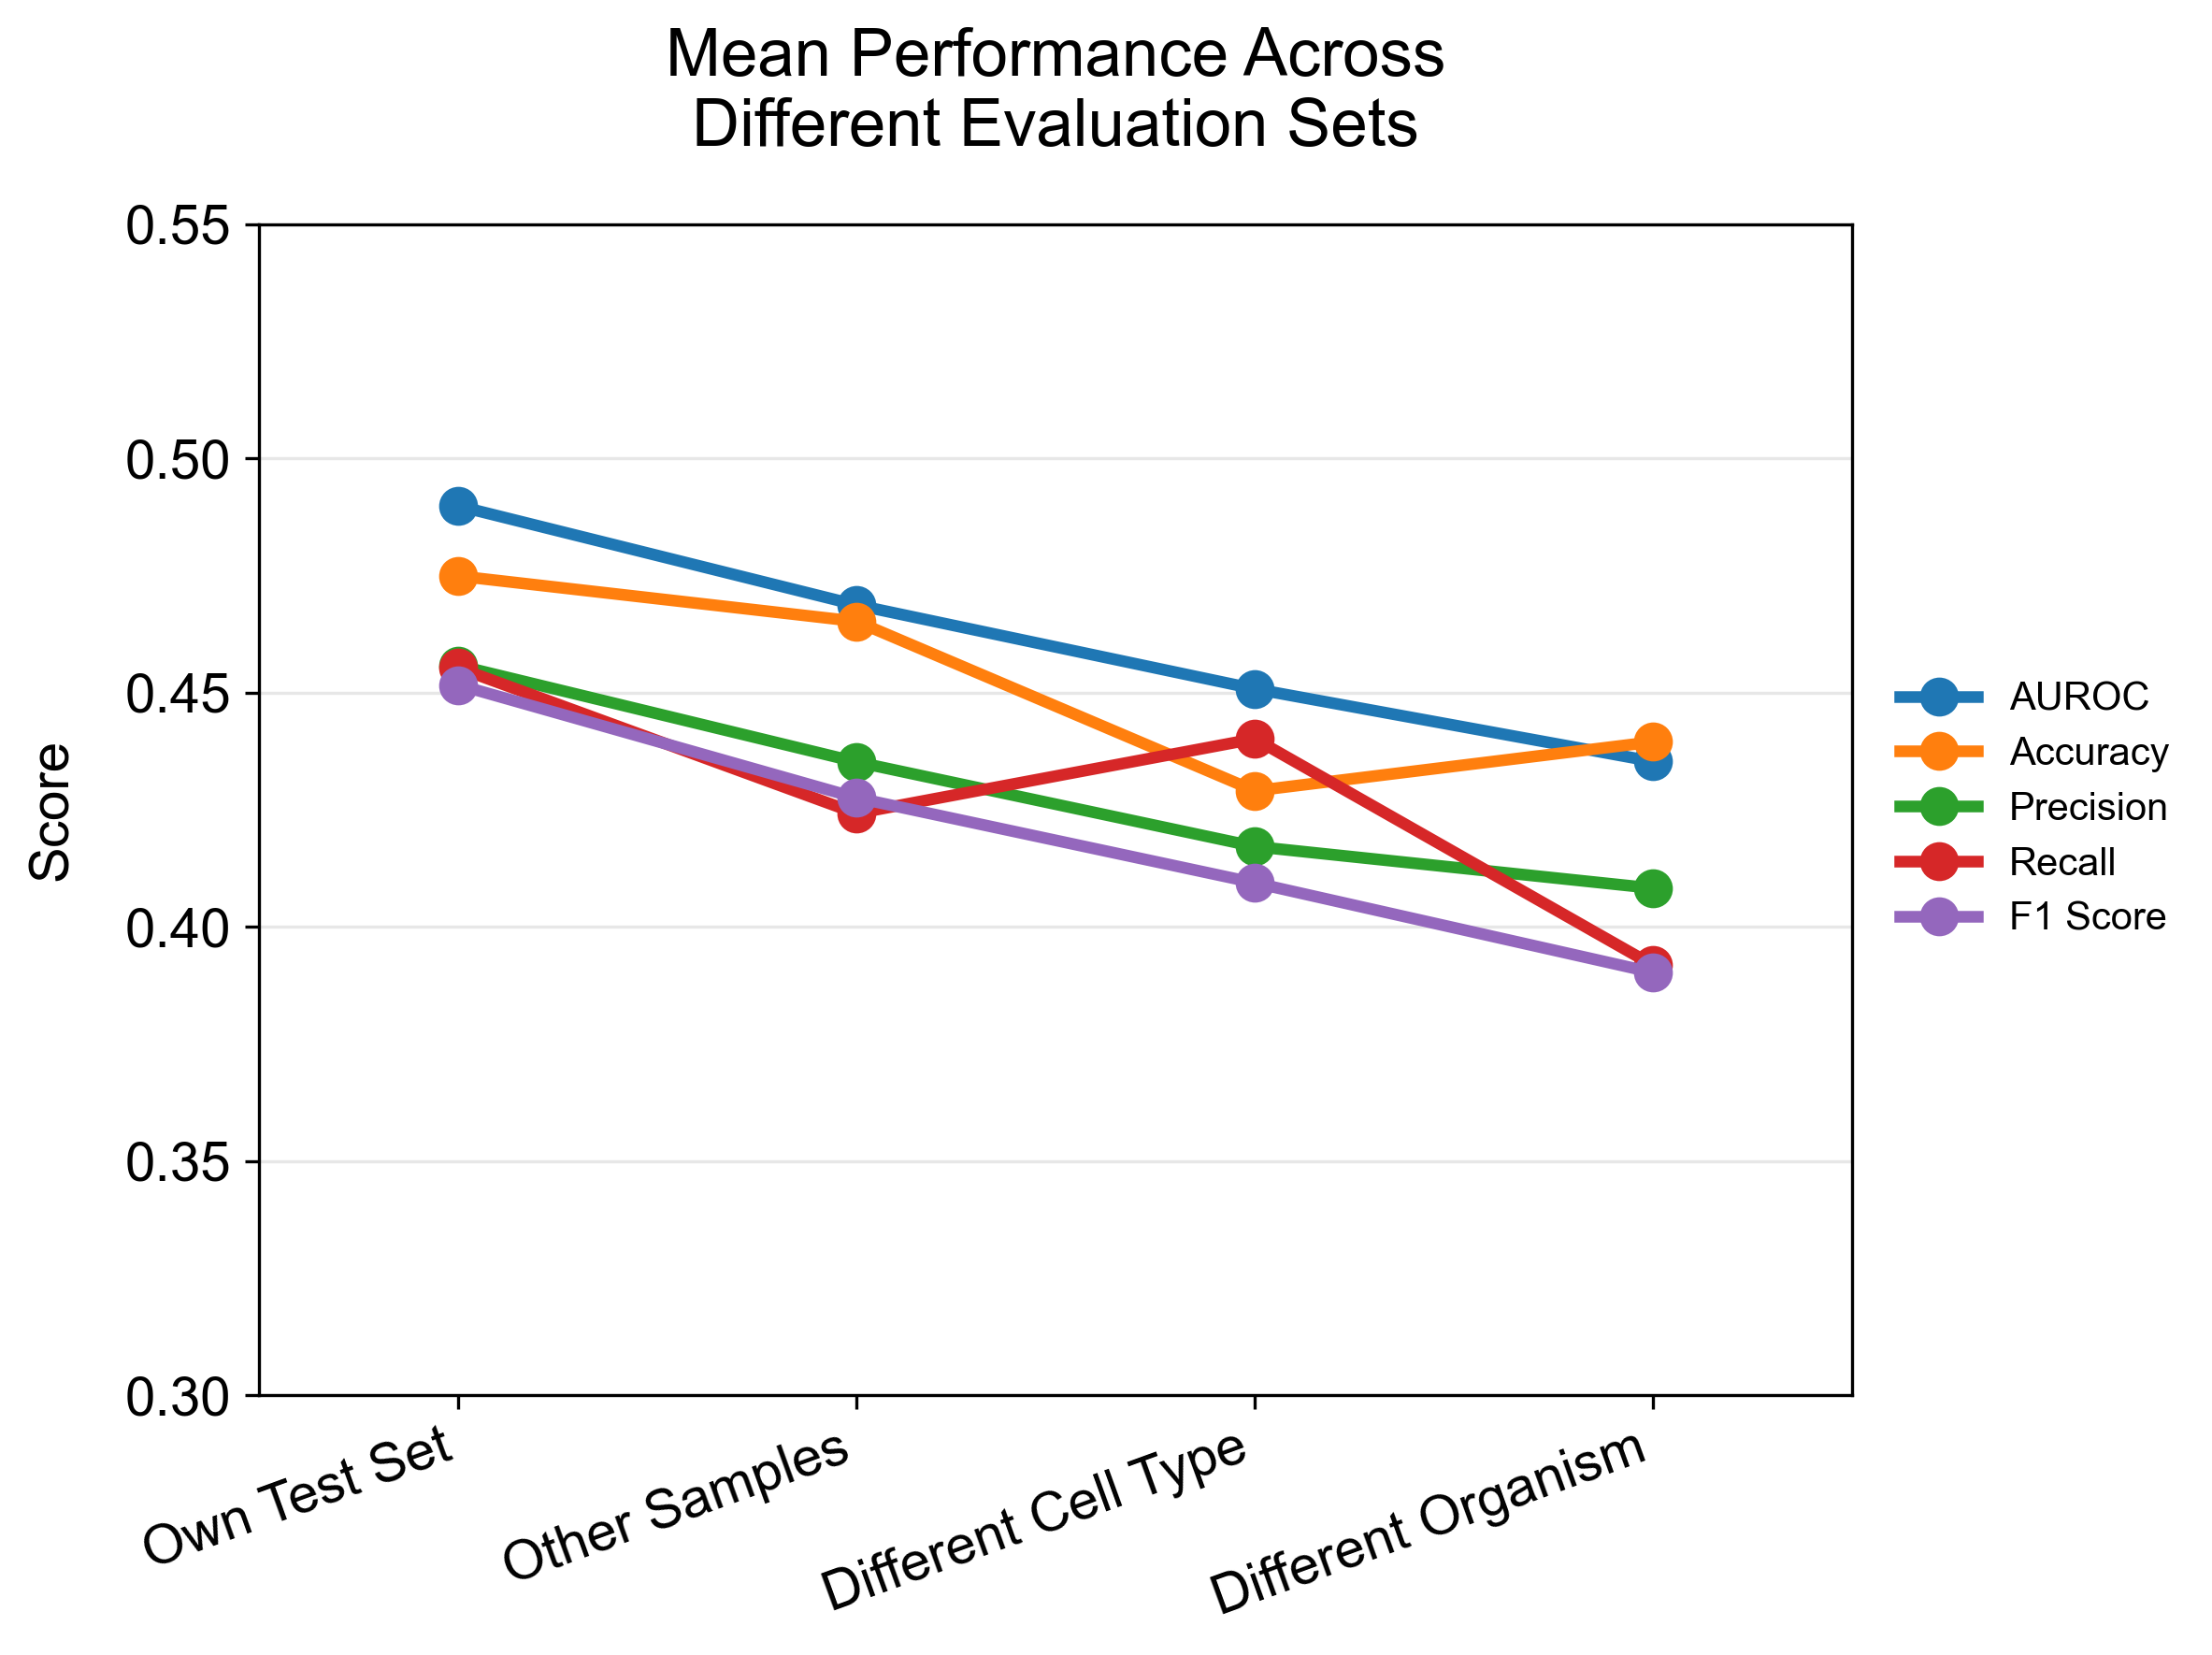

In [9]:
evaluation_order = [
    "Own Test Set",
    "Other Samples",
    "Different Cell Type",
    "Different Organism"
]

evaluation_sets = {
    "Own Test Set": own_test_set_group,
    "Other Samples": same_cell_type_group,
    "Different Cell Type": different_cell_type_group,
    "Different Organism": different_organism_group
}

generalizability_metrics = {
    "auroc_mean": "AUROC",
    # "auprc_mean": "AUPRC",
    "accuracy_mean": "Accuracy",
    "precision_mean": "Precision",
    "recall_mean": "Recall",
    "f1_mean": "F1 Score"
}

summary_rows = []
for eval_name in evaluation_order:
    df = evaluation_sets[eval_name]
    row = {"Evaluation Set": eval_name}

    for metric_col in generalizability_metrics:
        row[metric_col] = df[metric_col].mean()

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

evaluation = np.arange(len(evaluation_order))

generalizability_fig, generalizability_ax = plot_performance_across_evaluation_sets(evaluation, summary_df, generalizability_metrics, evaluation_order)

generalizability_fig.savefig(performance_across_evaluation_sets_plot_path, dpi=300, bbox_inches="tight")

all_figure_axes["generalizability_fig"] = generalizability_fig

plt.show()

### Own test set ROC - one graph per sample

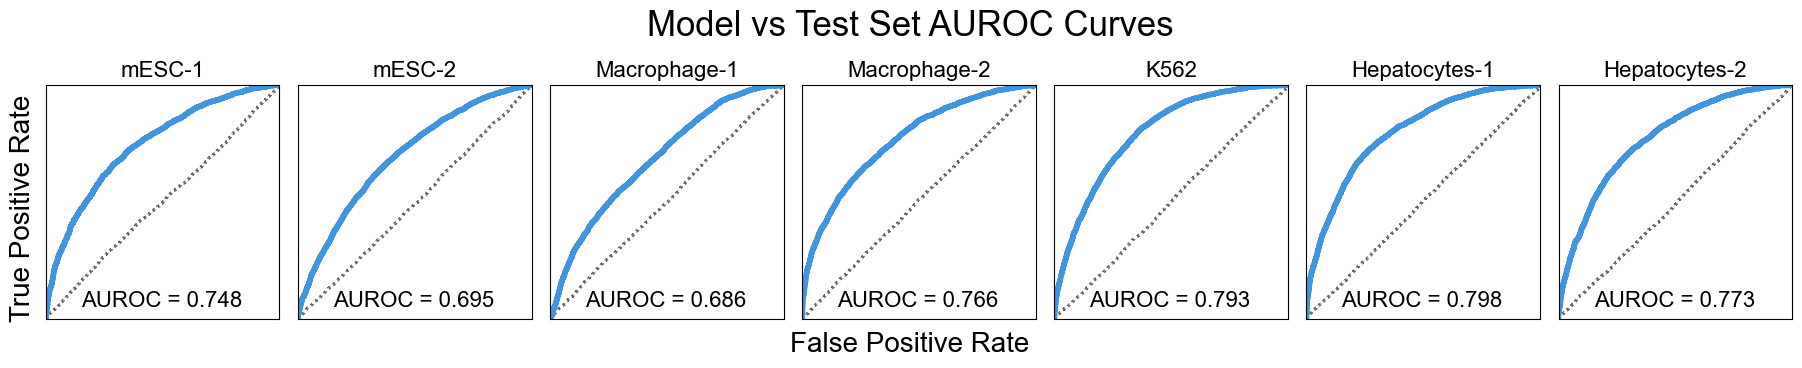

In [10]:
all_auroc_curve_fig, all_auroc_curve_ax = plot_model_vs_test_set_auroc_curves(models_to_plot)

all_auroc_curve_fig.savefig(auroc_models_vs_test_set_individual_plot_path, dpi=300, bbox_inches="tight")

all_figure_axes["all_auroc_curve_fig"] = all_auroc_curve_fig

plt.show()

### Own test set ROC - All samples one fig

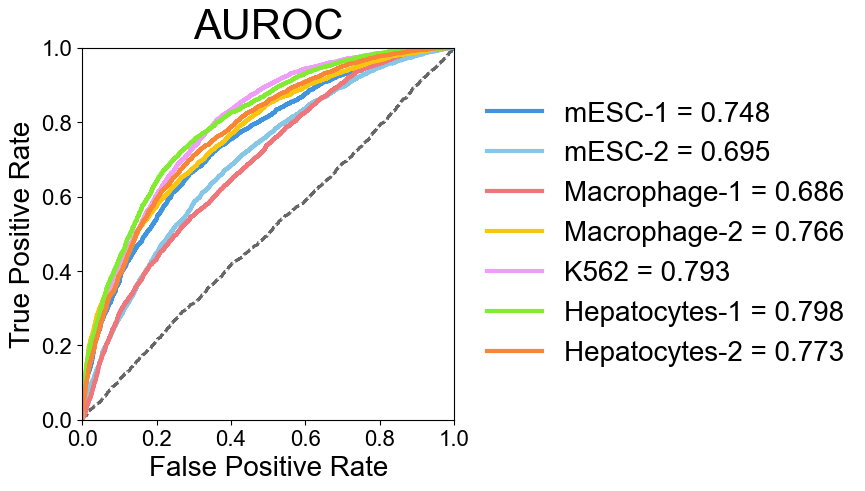

In [11]:
all_auroc_combined_fig, all_auroc_combined_ax = plot_model_vs_test_set_auroc_combined(models_to_plot)

all_auroc_combined_fig.savefig(
    auroc_models_vs_test_set_all_samples_plot_path,
    dpi=300,
    bbox_inches="tight",
)

all_figure_axes["all_auroc_combined_fig"] = all_auroc_combined_fig

plt.show()

### Own test set PRC - All samples one fig

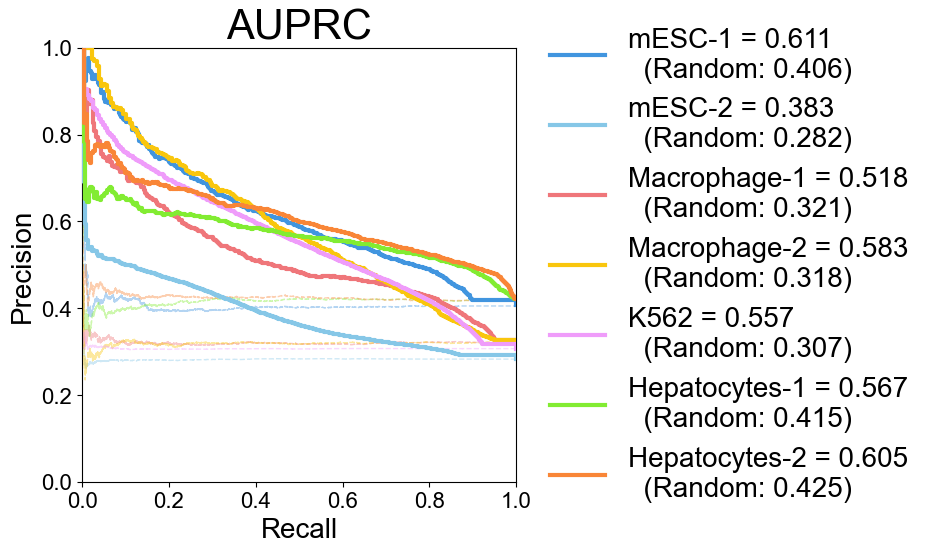

In [12]:
auprc_all_method_dfs = load_auprc_grns_all_methods(sample_list=models_to_plot)

auprc_combined_vs_test_set_fig, auprc_combined_vs_test_set_ax = plot_model_vs_test_set_auprc(
    auprc_all_method_dfs, models_to_plot, OWN_MODEL_METHOD
    )

auprc_combined_vs_test_set_fig.savefig(
    auprc_models_vs_test_set_all_samples_plot_path,
    dpi=300,
    bbox_inches="tight",
)

all_figure_axes["auprc_combined_vs_test_set_fig"] = auprc_combined_vs_test_set_fig

plt.show()

### Own test set AUPRC Lift - All samples in one fig

/tmp/ipykernel_183334/4046482580.py:379: RuntimeWarning: divide by zero encountered in divide
  precision_lift = precision_interp / rand_precision_interp
/tmp/ipykernel_183334/4046482580.py:379: RuntimeWarning: divide by zero encountered in divide
  precision_lift = precision_interp / rand_precision_interp
/tmp/ipykernel_183334/4046482580.py:379: RuntimeWarning: divide by zero encountered in divide
  precision_lift = precision_interp / rand_precision_interp


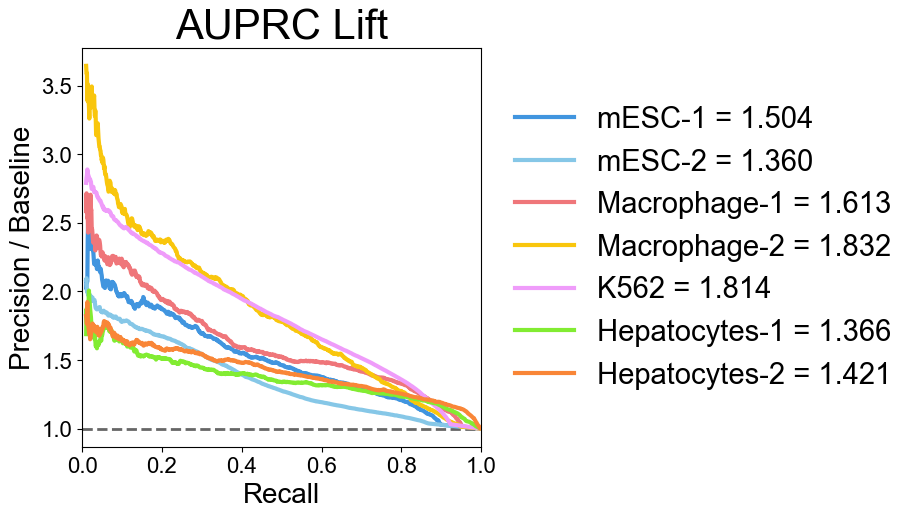

In [13]:
auprc_lift_combined_vs_test_set_fig, auprc_lift_combined_vs_test_set_ax = plot_model_vs_test_set_auprc_lift(
    auprc_all_method_dfs, models_to_plot, OWN_MODEL_METHOD
    )

auprc_lift_combined_vs_test_set_fig.savefig(
    auprc_lift_models_vs_test_set_all_samples_plot_path,
    dpi=300,
    bbox_inches="tight",
)

all_figure_axes["auprc_lift_combined_vs_test_set_fig"] = auprc_lift_combined_vs_test_set_fig

plt.show()

## Cross-trained model vs other inference methods

### Dictionaries and Mappings

In [14]:
samples_to_run = [
    ("mESC", "E7.5_rep1", "mouse_hepatocytes", "hepatocytes_1"),
    ("mESC", "E8.5_rep1", "mouse_hepatocytes", "hepatocytes_1"),
    ("Macrophage", "buffer_1", "K562", "sample_1"),
    ("Macrophage", "buffer_2", "K562", "sample_1"),
    ("K562", "sample_1", "Macrophage", "buffer_1"),
    ("mouse_hepatocytes", "hepatocytes_1", "mESC", "E7.5_rep1"),
    ("mouse_hepatocytes", "hepatocytes_3", "mESC", "E7.5_rep1"),
]

metric_name_map = {
    "auroc": "AUROC",
    "auprc": "AUPRC",
    "accuracy": "Accuracy",
    "early_precision": "Early Precision",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1",
}

boxplot_metric_name_map = {
    "auroc": "ROC",
    "auprc": "PRC",
    "accuracy": "Accuracy",
    "early_precision": "Early Precision",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1",
}

compare_all_method_metrics = [
    "auroc",
    "auprc",
    "accuracy",
    "early_precision",
    "precision",
    "recall",
    "f1",
]

RAND_COL_BY_METRIC = {
    "auroc": "rand_auroc",
    "auprc": "rand_auprc",
}

### Method Comparison Functions

In [15]:
def _is_binary_like(series):
    vals = pd.Series(series).dropna().unique()
    return len(vals) > 0 and set(vals).issubset({0, 1, 0.0, 1.0, True, False})


def standardize_prediction_score_label_df(df):
    """
    Makes cached/generated model prediction files consistent.

    Expected output:
        - Score column
        - _in_gt column when Source/Target are absent
    """
    df = df.copy()

    if "Score" not in df.columns and "score" in df.columns:
        df = df.rename(columns={"score": "Score"})

    if "_in_gt" not in df.columns:
        if "label" in df.columns:
            df["_in_gt"] = df["label"]
        elif "Label" in df.columns:
            df["_in_gt"] = df["Label"]

    # Handle accidentally reversed label/score columns.
    if "Score" in df.columns and "_in_gt" in df.columns:
        score_is_binary = _is_binary_like(df["Score"])
        label_is_binary = _is_binary_like(df["_in_gt"])

        if score_is_binary and not label_is_binary:
            old_score = df["Score"].copy()
            df["Score"] = df["_in_gt"]
            df["_in_gt"] = old_score

    if "_in_gt" in df.columns:
        df["_in_gt"] = df["_in_gt"].astype(int)

    return df


def generate_model_predictions(
    model, 
    data_loader, 
    device, 
    tf_idx_to_name, 
    tg_idx_to_name,
    compile_model=False,
    ):
    pooling_mode = "lse"
    pooling_temperature = 1.0

    model = model.to(device)
    model.eval()
    
    if compile_model and device.type == "cuda":
        model = torch.compile(model, mode="reduce-overhead")

    tf_indices_list = []
    tg_indices_list = []
    all_scores = []

    with torch.inference_mode():
        for batch in tqdm(data_loader, desc="Evaluating", ncols=100):
            tf_indices = batch["tf_idx"].detach().cpu().numpy().ravel()
            tg_indices = batch["tg_idx"].detach().cpu().numpy().ravel()

            batch = tf_to_tg_module.move_batch_to_device(batch, device)

            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(device.type == "cuda")):
                edge_logits, _ = model(
                    tf_embedding=batch["tf_embedding"],
                    tf_mask=batch["tf_mask"],
                    peak_sequences=batch["peak_sequences"],
                    peak_accessibility=batch["peak_accessibility"],
                    peak_distance=batch["peak_distance"],
                    tf_expression=batch["tf_expression"],
                    tg_expression=batch["tg_expression"],
                    peak_mask=batch.get("peak_mask", None),
                    cell_mask=batch["cell_mask"],
                    pooling_mode=pooling_mode,
                    pooling_temperature=pooling_temperature,
                )

            scores = torch.sigmoid(edge_logits.float())

            tf_indices_list.append(tf_indices)
            tg_indices_list.append(tg_indices)
            all_scores.append(scores.detach().cpu().numpy().ravel())

    all_tf_indices_flat = np.concatenate(tf_indices_list)
    all_tg_indices_flat = np.concatenate(tg_indices_list)
    all_scores_flat = np.concatenate(all_scores)

    tf_names = [tf_idx_to_name[int(idx)].upper() for idx in all_tf_indices_flat]
    tg_names = [tg_idx_to_name[int(idx)].upper() for idx in all_tg_indices_flat]

    prediction_df = pd.DataFrame({
        "Source": tf_names,
        "Target": tg_names,
        "Score": all_scores_flat,
    })

    prediction_df = (
        prediction_df.groupby(["Source", "Target"], as_index=False)["Score"]
        .median()
    )

    return prediction_df


def load_or_generate_tftg_predictions(
    label_file,
    tf_dna_model_chkpt,
    tf_tg_model_chkpt,
    tf_embeddings_tensor,
    tf_mask_tensor,
    data_loader,
    device,
    tf_idx_to_name,
    tg_idx_to_name,
    compile_model=True,
):
    if label_file.exists():
        logging.info(f"    - Loading cached predictions from: {label_file.name}")
        prediction_df = pd.read_csv(label_file)
        return standardize_prediction_score_label_df(prediction_df)

    elif torch.cuda.is_available() and device.type == "cuda":
        logging.info(f"    - Generating predictions and saving to: {label_file.name}")

        tf_tg_model = utils.load_tf_tg_regulation_model(
            tf_dna_model_chkpt,
            tf_tg_model_chkpt,
            tf_embeddings_tensor,
            tf_mask_tensor,
            compile_model=compile_model,
        )

        prediction_df = generate_model_predictions(
            tf_tg_model.model,
            data_loader,
            device,
            tf_idx_to_name,
            tg_idx_to_name,
        )

        prediction_df = standardize_prediction_score_label_df(prediction_df)

        label_file.parent.mkdir(parents=True, exist_ok=True)
        prediction_df.to_csv(label_file, index=False)

    else:
        logging.error(
            f"    - No cached predictions found and CUDA is not available. "
            f"Skipping prediction generation for: {label_file.name}"
        )

    return prediction_df


def create_tf_tg_index_to_name_mappings(metadata):
    tf_idx_to_name = {idx: name for name, idx in metadata["tf_name_to_idx"].items()}
    tg_idx_to_name = {idx: name for name, idx in metadata["tg_id_to_idx"].items()}
    return tf_idx_to_name, tg_idx_to_name


def create_tf_tg_label_df(tftg_inputs_test):
    # Create the TF-TG label DataFrame.
    test_tf_input = tftg_inputs_test["tf_name"]
    test_tg_input = tftg_inputs_test["tg_name"]
    test_labels = tftg_inputs_test["label"]

    tf_tg_label_df = pd.DataFrame({
        "Source": test_tf_input,
        "Target": test_tg_input,
        "Label": test_labels,
    })

    tf_tg_label_df["Source"] = tf_tg_label_df["Source"].astype(str).str.upper()
    tf_tg_label_df["Target"] = tf_tg_label_df["Target"].astype(str).str.upper()
    tf_tg_label_df["Label"] = tf_tg_label_df["Label"].astype(int)

    # A TF-target pair should occur only once in the evaluation universe.
    # max() protects against an inconsistent duplicate in which one row is
    # labeled positive and another is labeled negative.
    tf_tg_label_df = (
        tf_tg_label_df
        .groupby(["Source", "Target"], as_index=False)["Label"]
        .max()
    )

    universe_pairs = set(
        tf_tg_label_df["Source"] + "\t" + tf_tg_label_df["Target"]
    )

    gt_df: pd.DataFrame = tf_tg_label_df[tf_tg_label_df["Label"] == 1]
    gt_tfs = set(gt_df["Source"].unique())
    gt_targets = set(gt_df["Target"].unique())
    gt_pairs = set(gt_df["Source"] + "\t" + gt_df["Target"])

    return tf_tg_label_df, gt_pairs, gt_tfs, gt_targets, universe_pairs


def compute_metrics(
    method_name: str,
    sample_name: str,
    df: pd.DataFrame,
    gt_pairs: set,
    gt_tfs: set,
    gt_targets: set,
    universe_pairs: set,
    score_threshold: float = 0.5,
    top_k_edges: int | None = None,
    top_fraction: float = 0.10,
    ptf_alpha: float = 0.05,
):
    """
    Calculate score-based, threshold-based, and top-edge GRN metrics.

    Set definitions
    ---------------
    A : the method's highest-scoring ``top_fraction`` of unique edges
    B : positive ground-truth edges
    U : all labeled TF-target pairs in the held-out test set

    The same A is used for early precision/EPR inputs, Jaccard, PerInt,
    recall, FPR, and predictable-TF calculations. This avoids comparing
    external methods at incompatible raw score thresholds.

    Notes
    -----
    * ``recall`` and ``fpr`` are the requested top-edge versions.
    * The previous score-threshold recall is retained as
      ``threshold_recall``.
    * ``predictable_tfs`` uses a one-sided hypergeometric enrichment test
      for each evaluable TF, followed by Benjamini-Hochberg FDR correction.
    """
    from scipy.stats import hypergeom

    def _safe_divide(numerator, denominator):
        if denominator == 0:
            return np.nan
        return float(numerator / denominator)

    def _benjamini_hochberg(p_values):
        """Return Benjamini-Hochberg adjusted p-values without statsmodels."""
        p_values = np.asarray(p_values, dtype=float)
        if p_values.size == 0:
            return np.array([], dtype=float)

        order = np.argsort(p_values, kind="stable")
        ranked_p = p_values[order]
        ranks = np.arange(1, len(ranked_p) + 1, dtype=float)

        ranked_q = ranked_p * len(ranked_p) / ranks
        ranked_q = np.minimum.accumulate(ranked_q[::-1])[::-1]
        ranked_q = np.clip(ranked_q, 0.0, 1.0)

        q_values = np.empty_like(ranked_q)
        q_values[order] = ranked_q
        return q_values

    if top_k_edges is None:
        if not 0 < top_fraction <= 1:
            raise ValueError(
                f"top_fraction must be in the interval (0, 1]. "
                f"Got {top_fraction}"
            )
    else:
        if top_k_edges <= 0:
            raise ValueError(
                f"top_k_edges must be > 0. Got {top_k_edges}"
            )

    required_columns = {"Source", "Target", "Score"}
    missing_columns = required_columns.difference(df.columns)
    if missing_columns:
        raise ValueError(
            f"{method_name} for {sample_name} is missing required columns: "
            f"{sorted(missing_columns)}"
        )

    gt_tfs = {str(tf).upper() for tf in gt_tfs}
    gt_targets = {str(target).upper() for target in gt_targets}
    gt_pairs = {str(pair).upper() for pair in gt_pairs}
    universe_pairs = {str(pair).upper() for pair in universe_pairs}

    # Restrict both B and U to the common evaluated TF and target sets.
    def _pair_is_in_common_gene_set(pair):
        source, target = pair.split("\t", 1)
        return source in gt_tfs and target in gt_targets

    universe_pairs = {
        pair for pair in universe_pairs
        if _pair_is_in_common_gene_set(pair)
    }
    gt_pairs = {
        pair for pair in gt_pairs
        if pair in universe_pairs
    }

    metric_df = df[["Source", "Target", "Score"]].copy()
    metric_df["Source"] = metric_df["Source"].astype(str).str.upper()
    metric_df["Target"] = metric_df["Target"].astype(str).str.upper()
    metric_df["Score"] = pd.to_numeric(metric_df["Score"], errors="coerce")
    metric_df = metric_df[np.isfinite(metric_df["Score"])].copy()
    metric_df["pair"] = metric_df["Source"] + "\t" + metric_df["Target"]

    # All methods are scored against the same held-out candidate universe.
    metric_df = metric_df[metric_df["pair"].isin(universe_pairs)].copy()

    # Set metrics require unique edges. Retain the strongest score if a method
    # emitted the same TF-target pair more than once.
    metric_df = (
        metric_df
        .sort_values("Score", ascending=False, kind="stable")
        .drop_duplicates("pair", keep="first")
        .reset_index(drop=True)
    )

    labels = metric_df["pair"].isin(gt_pairs).astype(int).to_numpy()
    scores = metric_df["Score"].astype(float).to_numpy()

    n_edges = len(metric_df)
    has_both_classes = n_edges > 0 and len(np.unique(labels)) >= 2

    if n_edges == 0:
        top_k = 0
        top_pairs = set()
        early_precision = np.nan
        accuracy = precision = threshold_recall = f1 = np.nan
        auroc = random_auroc = np.nan
        epr = np.nan
    else:
        # This matches the existing EPR selection rule: top 10% by default.
        if top_k_edges is not None:
            # Exact number of top edges, or all available edges if < top_k_edges
            top_k = min(top_k_edges, n_edges)
        else:
            # Fraction-based behavior
            top_k = min(
                n_edges,
                max(1, int(round(top_fraction * n_edges))),
            )

        top_df = metric_df.nlargest(
            top_k,
            "Score",
            keep="first",
        )

        top_pairs = set(top_df["pair"])
        top_df = metric_df.nlargest(top_k, "Score", keep="first")
        top_pairs = set(top_df["pair"])

        early_precision = float(top_df["pair"].isin(gt_pairs).mean())
        
        n_pos = int(np.sum(labels))
        random_precision = n_pos / n_edges
        epr = _safe_divide(early_precision, random_precision)

        threshold_predictions = (scores >= score_threshold).astype(int)
        accuracy = accuracy_score(labels, threshold_predictions)
        precision = precision_score(
            labels,
            threshold_predictions,
            zero_division=0,
        )
        threshold_recall = recall_score(
            labels,
            threshold_predictions,
            zero_division=0,
        )
        f1 = f1_score(labels, threshold_predictions, zero_division=0)

        if has_both_classes:
            auroc = roc_auc_score(labels, scores)
            random_auroc = roc_auc_score(labels, np.random.rand(n_edges))
        else:
            auroc = np.nan
            random_auroc = np.nan

    # ------------------------------------------------------------------
    # Binary network metrics using the same top-edge set A as EPR.
    # ------------------------------------------------------------------
    true_positive_pairs = top_pairs.intersection(gt_pairs)
    false_positive_pairs = top_pairs.difference(gt_pairs)
    false_negative_pairs = gt_pairs.difference(top_pairs)

    tp = len(true_positive_pairs)
    fp = len(false_positive_pairs)
    fn = len(false_negative_pairs)

    n_universe = len(universe_pairs)
    n_ground_truth_edges = len(gt_pairs)
    n_negative_universe = n_universe - n_ground_truth_edges
    tn = n_negative_universe - fp

    if tn < 0:
        raise ValueError(
            f"Computed a negative TN count for {method_name}/{sample_name}. "
            "Check that predicted and ground-truth pairs are restricted to "
            "the same universe."
        )

    jaccard_index = _safe_divide(tp, tp + fp + fn)
    perint = 100.0 * _safe_divide(
        tp,
        min(len(top_pairs), n_ground_truth_edges),
    )
    top_edge_recall = _safe_divide(tp, tp + fn)
    top_edge_fpr = _safe_divide(fp, fp + tn)

    # ------------------------------------------------------------------
    # Predictable TFs (PTF): target-set enrichment for each gold-standard TF.
    # The hypergeometric universe is TF-specific because the held-out test set
    # may not contain every target candidate for every TF.
    # ------------------------------------------------------------------
    universe_targets_by_tf = {tf: set() for tf in gt_tfs}
    gt_targets_by_tf = {tf: set() for tf in gt_tfs}
    predicted_targets_by_tf = {tf: set() for tf in gt_tfs}

    for pair in universe_pairs:
        source, target = pair.split("\t", 1)
        if source in universe_targets_by_tf:
            universe_targets_by_tf[source].add(target)

    for pair in gt_pairs:
        source, target = pair.split("\t", 1)
        if source in gt_targets_by_tf:
            gt_targets_by_tf[source].add(target)

    for pair in top_pairs:
        source, target = pair.split("\t", 1)
        if source in predicted_targets_by_tf:
            predicted_targets_by_tf[source].add(target)

    evaluable_tfs = []
    ptf_p_values = []

    # The source study tests TFs represented in the inferred network. Because
    # A is the pruned/top-edge network here, only TFs occurring in A and in the
    # gold standard are included in the multiple-testing family.
    predicted_tfs = {
        pair.split("\t", 1)[0]
        for pair in top_pairs
    }

    for tf in sorted(gt_tfs.intersection(predicted_tfs)):
        tf_universe_targets = universe_targets_by_tf[tf]
        tf_gt_targets = gt_targets_by_tf[tf]
        tf_predicted_targets = predicted_targets_by_tf[tf]

        population_size = len(tf_universe_targets)
        n_true_targets = len(tf_gt_targets)
        n_predicted_targets = len(tf_predicted_targets)
        n_overlap = len(tf_gt_targets.intersection(tf_predicted_targets))

        # A TF needs at least one candidate target and one positive target to
        # support a meaningful enrichment test.
        if population_size == 0 or n_true_targets == 0:
            continue

        if n_predicted_targets == 0:
            p_value = 1.0
        else:
            # P[X >= observed overlap] under random target selection.
            p_value = float(
                hypergeom.sf(
                    n_overlap - 1,
                    population_size,
                    n_true_targets,
                    n_predicted_targets,
                )
            )

        evaluable_tfs.append(tf)
        ptf_p_values.append(p_value)

    ptf_p_values = np.asarray(ptf_p_values, dtype=float)
    ptf_q_values = _benjamini_hochberg(ptf_p_values)

    predictable_tfs_raw_p = int(np.sum(ptf_p_values < ptf_alpha))
    predictable_tfs = int(np.sum(ptf_q_values < ptf_alpha))
    n_evaluable_tfs = len(evaluable_tfs)
    predictable_tf_fraction = _safe_divide(
        predictable_tfs,
        n_evaluable_tfs,
    )

    return pd.DataFrame([{
        "method_name": method_name,
        "sample_name": sample_name,
        "auroc": auroc,
        "rand_auroc": random_auroc,
        "early_precision": early_precision,
        "early_precision_rate": epr,
        "accuracy": accuracy,
        "precision": precision,
        # Requested top-edge recall/FPR; threshold recall is retained below.
        "recall": top_edge_recall,
        "fpr": top_edge_fpr,
        "f1": f1,
        "threshold_recall": threshold_recall,
        "jaccard_index": jaccard_index,
        "perint": perint,
        "predictable_tfs": predictable_tfs,
        "predictable_tfs_raw_p": predictable_tfs_raw_p,
        "predictable_tf_fraction": predictable_tf_fraction,
        "n_evaluable_tfs": n_evaluable_tfs,
        "top_fraction": top_fraction,
        "top_k_edges": top_k,
        "top_tp": tp,
        "top_fp": fp,
        "top_fn": fn,
        "top_tn": tn,
        "n_edges": n_edges,
        "n_universe_pairs": n_universe,
        "n_pos": int(labels.sum()),
        "n_neg": int((labels == 0).sum()),
        "n_ground_truth_edges": n_ground_truth_edges,
        "score_threshold": score_threshold,
        "ptf_alpha": ptf_alpha,
        "ptf_multiple_testing": "Benjamini-Hochberg FDR",
    }])


def load_and_standardize_method(name: str, info: dict) -> pd.DataFrame:
    """
    Load a GRN CSV and rename tf_col/target_col/score_col -> Source/Target/Score.
    Extra columns are preserved.
    """
    if info["path"].suffix == ".tsv":
        sep = "\t"
    elif info["path"].suffix == ".csv":
        sep = ","
    
    df = pd.read_csv(info["path"], sep=sep, header=0, index_col=None)

    tf_col     = info["tf_col"]
    target_col = info["target_col"]
    score_col  = info["score_col"]

    sample_rename_map = {
        tf_col: "Source",
        target_col: "Target",
        score_col: "Score",
    }

    missing = [c for c in sample_rename_map if c not in df.columns]
    if missing:
        raise ValueError(f"[{name}] Missing expected columns: {missing}. Got: {list(df.columns)}")

    df = df.rename(columns=sample_rename_map)

    df = df[["Source", "Target", "Score"]]
    df["Source"] = df["Source"].astype(str).str.upper()
    df["Target"] = df["Target"].astype(str).str.upper()
    
    df["Score"] = np.abs(df["Score"])

    return df


def create_full_method_comparion_df(samples_to_run, subset_size=None, top_k_edges=10_000, top_fraction=0.10):
    standardized_method_dfs = {}
    label_by_method_dict = {}
    score_by_method_dict = {}
    metric_by_method_list = []
    gt_by_sample_dict = {}

    sample_list = [sample_name for _, sample_name, _, _ in samples_to_run]
    auprc_all_method_dfs = load_auprc_grns_all_methods(sample_list=sample_list)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    for model_cell_type, sample_name, cross_model_cell_type, cross_model_sample_name in samples_to_run:

        logging.info(
            f"Processing test sample: {sample_name} | "
            f"Test cell type: {model_cell_type} | "
            f"Cross-trained model: {cross_model_cell_type}/{cross_model_sample_name}"
        )

        cell_type_cache_dir = DATA_DIR / f"{model_cell_type}_cache"

        model_label_file = (
            score_label_save_dir
            / f"{sample_name}_model_vs_{sample_name}_grn_{subset_size}.csv"
        )

        cross_model_label_file = (
            score_label_save_dir
            / f"{cross_model_sample_name}_model_vs_{sample_name}_grn_{subset_size}.csv"
        )

        # Load cached test dataset for the evaluation/test sample.
        data_loader, metadata, manifest, tf_embeddings_tensor, tf_mask_tensor = utils.load_training_cache_dataset(
            sample_name=sample_name,
            cell_type_cache_dir=cell_type_cache_dir,
            split_type="test",
            subset_size=subset_size,
        )

        # Load full test labels / edge metadata.
        tftg_inputs_test = torch.load(
            cell_type_cache_dir / "tf_tg_training_cache" / sample_name / "tftg_inputs_test.pt",
            weights_only=False,
        )

        tf_idx_to_name, tg_idx_to_name = create_tf_tg_index_to_name_mappings(metadata)

        test_set_tf_indices = list(tftg_inputs_test["tf_idx"].numpy())
        test_set_tg_indices = list(tftg_inputs_test["tg_idx"].numpy())

        tf_names = [tf_idx_to_name[int(idx)].upper() for idx in test_set_tf_indices]
        tg_names = [tg_idx_to_name[int(idx)].upper() for idx in test_set_tg_indices]

        # -----------------------------
        # Own-model predictions
        # -----------------------------
        own_tf_tg_model_chkpt = tf_tg_model_checkpoints[model_cell_type][sample_name]
        own_tf_dna_model_chkpt = config.tf_dna_model_checkpoints[model_cell_type]
        
        prediction_df = load_or_generate_tftg_predictions(
            label_file=model_label_file,
            tf_dna_model_chkpt=own_tf_dna_model_chkpt,
            tf_tg_model_chkpt=own_tf_tg_model_chkpt,
            tf_embeddings_tensor=tf_embeddings_tensor,
            tf_mask_tensor=tf_mask_tensor,
            data_loader=data_loader,
            device=device,
            tf_idx_to_name=tf_idx_to_name,
            tg_idx_to_name=tg_idx_to_name,
            compile_model=False,
        )

        # -----------------------------
        # Cross-trained model predictions
        # -----------------------------
        cross_tf_tg_model_chkpt = tf_tg_model_checkpoints[cross_model_cell_type][cross_model_sample_name]
        cross_tf_dna_model_chkpt = config.tf_dna_model_checkpoints[cross_model_cell_type]

        cross_model_prediction_df = load_or_generate_tftg_predictions(
            label_file=cross_model_label_file,
            tf_dna_model_chkpt=cross_tf_dna_model_chkpt,
            tf_tg_model_chkpt=cross_tf_tg_model_chkpt,
            tf_embeddings_tensor=tf_embeddings_tensor,
            tf_mask_tensor=tf_mask_tensor,
            data_loader=data_loader,
            device=device,
            tf_idx_to_name=tf_idx_to_name,
            tg_idx_to_name=tg_idx_to_name,
            compile_model=False,
        )

        # -----------------------------
        # Ground truth
        # -----------------------------
        tf_tg_label_df, gt_pairs, gt_tfs, gt_targets, universe_pairs = create_tf_tg_label_df(tftg_inputs_test)

        gt_tfs = gt_tfs.intersection(set(tf_names))
        gt_targets = gt_targets.intersection(set(tg_names))

        gt_pairs = {
            pair
            for pair in gt_pairs
            if pair.split("\t", 1)[0] in gt_tfs
            and pair.split("\t", 1)[1] in gt_targets
        }

        universe_pairs = {
            pair
            for pair in universe_pairs
            if pair.split("\t", 1)[0] in gt_tfs
            and pair.split("\t", 1)[1] in gt_targets
        }

        gt_by_sample_dict[sample_name] = {
            "gt_pairs": gt_pairs,
            "gt_tfs": gt_tfs,
            "gt_targets": gt_targets,
            "universe_pairs": universe_pairs,
            "test_cell_type": model_cell_type,
            "test_sample": sample_name,
        }

        # -----------------------------
        # Other method GRNs
        # -----------------------------
        OTHER_METHOD_MUON_DIR = Path(
            "/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/other_method_grns"
        )

        linger_path = (
            OTHER_METHOD_MUON_DIR
            / "LINGER_muon"
            / f"linger_{model_cell_type}_{sample_name}.tsv"
        )

        scenic_plus_path = (
            OTHER_METHOD_MUON_DIR
            / "SCENIC_muon"
            / f"scenicplus_{model_cell_type}_{sample_name}.tsv"
        )

        cell_oracle_path = (
            OTHER_METHOD_MUON_DIR
            / "CellOracle_muon"
            / f"celloracle_{model_cell_type}_{sample_name}.tsv"
        )

        pando_path = (
            OTHER_METHOD_MUON_DIR
            / "Pando_muon"
            / f"pando_{model_cell_type}_{sample_name}.tsv"
        )

        figr_path = (
            OTHER_METHOD_MUON_DIR
            / "FigR_muon"
            / f"figr_{model_cell_type}_{sample_name}.tsv"
        )

        method_info = {
            "SCENIC+": {
                "path": scenic_plus_path,
                "tf_col": "Source",
                "target_col": "Target",
                "score_col": "Score",
            },
            "LINGER": {
                "path": linger_path,
                "tf_col": "Source",
                "target_col": "Target",
                "score_col": "Score",
            },
            "CellOracle": {
                "path": cell_oracle_path,
                "tf_col": "Source",
                "target_col": "Target",
                "score_col": "Score",
            },
            "Pando": {
                "path": pando_path,
                "tf_col": "Source",
                "target_col": "Target",
                "score_col": "Score",
            },
            "FigR": {
                "path": figr_path,
                "tf_col": "Source",
                "target_col": "Target",
                "score_col": "Score",
            },
        }

        standardized_method_dfs[sample_name] = {}

        for method_name, info in method_info.items():
            df_std = load_and_standardize_method(method_name, info)

            n_raw = len(df_std)

            source_mask = df_std["Source"].isin(gt_tfs)
            target_mask = df_std["Target"].isin(gt_targets)
            mask = source_mask & target_mask

            df_filtered = df_std.loc[mask].copy()

            logging.info(
                f"  - {method_name}: "
                f"raw_edges={n_raw:,}, "
                f"source_overlap={source_mask.sum():,}, "
                f"target_overlap={target_mask.sum():,}, "
                f"both_overlap={mask.sum():,}"
            )

            if df_filtered.empty:
                logging.error(
                    f"EMPTY AFTER FILTERING: "
                    f"sample={sample_name}, "
                    f"method={method_name}, "
                    f"raw_edges={n_raw:,}, "
                    f"unique_method_TFs={df_std['Source'].nunique():,}, "
                    f"unique_method_TGs={df_std['Target'].nunique():,}, "
                    f"gt_TFs={len(gt_tfs):,}, "
                    f"gt_TGs={len(gt_targets):,}"
                )

            standardized_method_dfs[sample_name][method_name] = df_filtered

        # Important:
        # Use stable method labels, not sample names.
        standardized_method_dfs[sample_name][OWN_MODEL_METHOD] = prediction_df
        standardized_method_dfs[sample_name][CROSS_MODEL_METHOD] = cross_model_prediction_df

        label_by_method_dict[sample_name] = {}
        score_by_method_dict[sample_name] = {}

        # -----------------------------
        # Metric computation
        # -----------------------------
        for method_name, df in standardized_method_dfs[sample_name].items():
            df = standardize_prediction_score_label_df(df)

            if "Source" in df.columns and "Target" in df.columns:
                labels = [
                    1 if pair in gt_pairs else 0
                    for pair in df["Source"] + "\t" + df["Target"]
                ]
            elif "_in_gt" in df.columns:
                labels = df["_in_gt"].astype(int).tolist()
            else:
                raise ValueError(
                    f"{method_name} for {sample_name} has neither "
                    "Source/Target columns nor an _in_gt label column."
                )

            scores = df["Score"].tolist()

            label_by_method_dict[sample_name][method_name] = labels
            score_by_method_dict[sample_name][method_name] = scores
            
            if use_top_10k_edges:
                top_k_edges = 10_000
                top_fraction = 0.10  # only used if top_k_edges is None
            else:
                top_k_edges = None
                top_fraction = 0.10


            metrics_df = compute_metrics(
                method_name=method_name,
                sample_name=sample_name,
                df=df,
                gt_pairs=gt_pairs,
                gt_tfs=gt_tfs,
                gt_targets=gt_targets,
                universe_pairs=universe_pairs,
                score_threshold=0.5,
                top_fraction=top_fraction,
                top_k_edges=top_k_edges,
                ptf_alpha=0.05,
            )

            metrics_df["test_cell_type"] = model_cell_type
            metrics_df["test_sample"] = sample_name
            
            labeled_auprc_df = auprc_all_method_dfs[sample_name][method_name]
            metrics_df["auprc"] = average_precision_score(labeled_auprc_df["_in_gt"], labeled_auprc_df["Score"])
            metrics_df["rand_auprc"] = average_precision_score(labeled_auprc_df["_in_gt"], np.random.rand(len(labeled_auprc_df["_in_gt"])))
            
            if sample_name == "hepatocytes_1" and method_name == "Pando":
                metrics_df["auroc"] = roc_auc_score(labeled_auprc_df["_in_gt"], labeled_auprc_df["Score"])
                metrics_df["rand_auroc"] = roc_auc_score(labeled_auprc_df["_in_gt"], np.random.rand(len(labeled_auprc_df["_in_gt"])))

            if method_name == OWN_MODEL_METHOD:
                metrics_df["model_eval_type"] = "own_test_set"
                metrics_df["train_cell_type"] = model_cell_type
                metrics_df["train_sample"] = sample_name

            elif method_name == CROSS_MODEL_METHOD:
                metrics_df["model_eval_type"] = "cross_trained"
                metrics_df["train_cell_type"] = cross_model_cell_type
                metrics_df["train_sample"] = cross_model_sample_name

            else:
                metrics_df["model_eval_type"] = "external_method"
                metrics_df["train_cell_type"] = np.nan
                metrics_df["train_sample"] = np.nan

            metric_by_method_list.append(metrics_df)

            safe_method_name = (
                method_name
                .replace(" ", "_")
                .replace("/", "_")
                .replace("(", "")
                .replace(")", "")
            )

    full_metric_df = pd.concat(metric_by_method_list, ignore_index=True)
    
    return full_metric_df, standardized_method_dfs, gt_by_sample_dict


def get_labels_and_scores_for_roc(df, gt_pairs):
    """
    Returns labels and scores for either:
      1. TF-TG model prediction dfs with _in_gt and Score columns
      2. External method GRN dfs with Source, Target, and Score columns
    """
    df = df.copy()

    if "Score" not in df.columns and "score" in df.columns:
        df = df.rename(columns={"score": "Score"})

    if "Score" not in df.columns:
        raise ValueError("DataFrame is missing a Score column.")

    if "_in_gt" in df.columns:
        labels = df["_in_gt"].astype(int).to_numpy()

    elif "Source" in df.columns and "Target" in df.columns:
        pairs = df["Source"].astype(str) + "\t" + df["Target"].astype(str)
        labels = pairs.isin(gt_pairs).astype(int).to_numpy()

    else:
        raise ValueError(
            "DataFrame must have either _in_gt or Source/Target columns."
        )

    scores = df["Score"].astype(float).to_numpy()

    valid_mask = np.isfinite(labels) & np.isfinite(scores)
    labels = labels[valid_mask]
    scores = scores[valid_mask]

    return labels, scores


def metric_df_to_rank_df(
    full_metric_df,
    metric_col,
    experiment_col="sample_name",
    method_col="method_name",
    higher_is_better=True,
):
    metric_df = (
        full_metric_df
        [[experiment_col, method_col, metric_col]]
        .dropna()
        .copy()
    )

    metric_df = (
        metric_df
        .groupby([experiment_col, method_col], as_index=False)
        .agg(metric_value=(metric_col, "median"))
    )

    metric_df = metric_df.rename(
        columns={
            experiment_col: "experiment",
            method_col: "method",
        }
    )

    metric_df["rank"] = (
        metric_df
        .groupby("experiment")["metric_value"]
        .rank(
            method="min",
            ascending=not higher_is_better,
        )
        .astype(int)
    )

    all_ranks_df = metric_df.sort_values(["experiment", "rank"]).copy()

    rank_df = (
        all_ranks_df
        .groupby("method", as_index=False)
        .agg(
            avg_rank=("rank", "mean"),
            median_rank=("rank", "median"),
            mean_metric=("metric_value", "mean"),
        )
        .sort_values(["avg_rank", "median_rank"], ascending=True)
        .reset_index(drop=True)
    )

    return all_ranks_df, rank_df


### Method Comparison Plotting Functions

In [16]:
def _style_xticklabels(ax, originals, method_color_dict,
                       sample_rename_map=None, color_xticks=True,
                       rotation=45, fontsize=15):
    sample_rename_map = sample_rename_map or {}
    labels = [sample_rename_map.get(o, o) for o in originals]

    ax.set_xticks(range(len(originals)))
    ax.set_xticklabels(labels, rotation=rotation, ha="right",
                       fontsize=fontsize, rotation_mode="anchor")

    for tick, original in zip(ax.get_xticklabels(), originals):
        if original in TFTG_MODEL_METHODS:
            
            tick.set_fontsize(fontsize)
            if color_xticks:
                tick.set_color(method_color_dict.get(original, "black"))
            tick.set_path_effects([pe.withStroke(linewidth=0.6, foreground=tick.get_color())])
        else:
            tick.set_color("black")
            tick.set_fontweight("normal")
           
            
def plot_method_box_and_whisker(
    full_metric_df, 
    selected_column, 
    method_color_dict, 
    sample_rename_map, 
    show_values_above_boxes=True
    ):
    
    metric_ordered_by_auroc = (
        full_metric_df
        .groupby("method_name")[selected_column]
        .median()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    sanitized_name = selected_column.replace("_", " ").lower()
    if sanitized_name in ["auroc", "auprc"]:
        sanitized_name = sanitized_name.upper()
        sanitized_name = sanitized_name.replace("AU", "")
    else:
        sanitized_name = sanitized_name.capitalize()

    loosely_dashed = (5, (10, 3))
    
    fig = plt.figure(figsize=(7, 6))

    ax = sns.boxplot(
        data=full_metric_df, 
        x="method_name", 
        y=selected_column, 
        hue="method_name", 
        width=0.6,
        order=metric_ordered_by_auroc, 
        palette=method_color_dict,
        whiskerprops={"linestyle": loosely_dashed, "linewidth": 1},
        boxprops={"linewidth": 0},
        capprops={"linewidth": 1},
        medianprops={"linewidth": 1},
        showfliers=False
    )
    
    medians = (
        full_metric_df
        .groupby("method_name")[selected_column]
        .median()
        .reindex(metric_ordered_by_auroc)
    )

    for i, method in enumerate(metric_ordered_by_auroc):
        vals = full_metric_df.loc[full_metric_df["method_name"] == method, selected_column].dropna()
        q1, q3 = vals.quantile([0.25, 0.75])
        top = vals[vals <= q3 + 1.5 * (q3 - q1)].max()

        if show_values_above_boxes:
            annotation = f"{vals.median():.3f}"
        else:
            ranks = medians.rank(method="min", ascending=False).astype(int)
            annotation = str(ranks[method])

        ax.text(i, top + 0.02, annotation, ha="center", va="bottom", fontsize=12)

    _style_xticklabels(
        ax,
        metric_ordered_by_auroc,
        method_color_dict=method_color_dict,
        sample_rename_map=sample_rename_map,
        color_xticks=True,
        rotation=45,
        fontsize=12
    )

    plt.title(f"{sanitized_name} by Method", fontsize=17)
    plt.xlabel("")
    plt.ylabel(sanitized_name, fontsize=14)
    plt.yticks(fontsize=14)
    
    if full_metric_df[selected_column].max() > 1:
        plt.ylim((0, full_metric_df[selected_column].max() * 1.05))
    else:
        plt.ylim((0, 1.10))
    
    plt.tight_layout()
    
    return fig, ax


def plot_sample_roc_curves(
    sample_name,
    standardized_method_dfs,
    gt_by_sample_dict,
    method_color_dict,
    sample_rename_map,
    roc_plot_dir,
    method_display_name_map=None,
    figsize=(6, 6),
):
    if method_display_name_map is None:
        method_display_name_map = {}

    if sample_name not in standardized_method_dfs:
        raise KeyError(f"Sample {sample_name} not found in standardized_method_dfs")

    if sample_name not in gt_by_sample_dict:
        raise KeyError(f"Sample {sample_name} not found in gt_by_sample_dict")

    sample_title = sample_rename_map.get(sample_name, sample_name)
    gt_pairs = gt_by_sample_dict[sample_name]["gt_pairs"]

    fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=figsize,
        sharex=True,
        sharey=True,
    )

    ax.set_box_aspect(1)

    cell_type_method_auroc = {
        "sample_name": [],
        "method": [],
        "auroc": [],
    }

    auroc_text_lines = []

    for method, df in standardized_method_dfs[sample_name].items():
        if method not in method_color_dict:
            continue

        y_roc, s_roc = get_labels_and_scores_for_roc(df, gt_pairs)

        if len(np.unique(y_roc)) < 2:
            logging.warning(
                f"Skipping ROC for {sample_name} / {method}: only one class present."
            )
            continue

        fpr, tpr, _ = roc_curve(y_roc, s_roc)
        auroc = roc_auc_score(y_roc, s_roc)

        cell_type_method_auroc["sample_name"].append(sample_name)
        cell_type_method_auroc["method"].append(method)
        cell_type_method_auroc["auroc"].append(auroc)

        method_color = method_color_dict.get(method, "#747474")
        auroc_text_lines.append((method, auroc, method_color))

        line_weight = 3.5 if method in TFTG_MODEL_METHODS else 2

        ax.plot(
            fpr,
            tpr,
            lw=line_weight,
            color=method_color,
            label="",
            zorder=3 if method in TFTG_MODEL_METHODS else 2,
        )

    # ROC random baseline
    ax.plot(
        [0, 1],
        [0, 1],
        lw=2,
        linestyle="--",
        color="black",
        alpha=0.6,
        zorder=1,
    )

    auroc_text_lines_sorted = sorted(
        auroc_text_lines,
        key=lambda x: x[1],
        reverse=True,
    )

    ax.set_title(sample_title, fontsize=26)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.tick_params(labelsize=18)

    legend_rows = []

    for method, auroc, method_color in auroc_text_lines_sorted:
        display_method = method_display_name_map.get(method, method)

        color_box = DrawingArea(16, 16, 0, 0)
        color_box.add_artist(
            Rectangle(
                (0, 1),
                18,
                18,
                facecolor=method_color,
                edgecolor="black",
                linewidth=0.75,
            )
        )

        label_text = TextArea(
            f"{display_method} = {auroc:.3f}",
            textprops=dict(
                color="black",
                fontsize=18,
                fontweight="bold" if method in TFTG_MODEL_METHODS else "normal",
            ),
        )

        row = HPacker(
            children=[color_box, label_text],
            align="center",
            pad=0.1,
            sep=6,
        )

        legend_rows.append(row)

    packed_legend = VPacker(
        children=legend_rows,
        align="left",
        pad=0,
        sep=8,
    )

    anchored_text = AnchoredOffsetbox(
        loc="upper center",
        child=packed_legend,
        pad=0.5,
        frameon=False,
        bbox_to_anchor=(0.5, -0.22),
        bbox_transform=ax.transAxes,
        borderpad=0.4,
    )

    ax.add_artist(anchored_text)

    fig.text(
        0.5,
        -0.05,
        "False Positive Rate",
        ha="center",
        fontsize=24,
    )

    fig.text(
        -0.05,
        0.45,
        "True Positive Rate",
        va="center",
        rotation="vertical",
        fontsize=24,
    )

    fig.subplots_adjust(
        left=0.04,
        right=0.98,
        bottom=0.10,
        top=0.88,
        wspace=0.08,
    )

    roc_plot_dir = Path(roc_plot_dir)
    
    fig.savefig(
        roc_plot_dir / f"{sample_name}_auroc.png",
        dpi=300,
        bbox_inches="tight",
    )

    return fig, ax


def interpolate_precision_at_recall(source_rec, source_prec, target_rec):
    source_rec = np.asarray(source_rec, dtype=float)
    source_prec = np.asarray(source_prec, dtype=float)
    target_rec = np.asarray(target_rec, dtype=float)

    valid = np.isfinite(source_rec) & np.isfinite(source_prec)
    source_rec = source_rec[valid]
    source_prec = source_prec[valid]

    # np.interp expects ascending x values
    order = np.argsort(source_rec)
    source_rec = source_rec[order]
    source_prec = source_prec[order]

    # Collapse duplicate recall values
    interp_df = (
        pd.DataFrame({
            "recall": source_rec,
            "precision": source_prec,
        })
        .groupby("recall", as_index=False)["precision"]
        .mean()
    )

    return np.interp(
        target_rec,
        interp_df["recall"].to_numpy(),
        interp_df["precision"].to_numpy(),
    )


def plot_sample_prc_curves(
    sample_name,
    auprc_all_method_dfs,
    method_color_dict,
    sample_rename_map,
    plot_lift=False,
):
    sample_title = sample_rename_map.get(sample_name, sample_name)

    fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=(6, 6),
        sharex=True,
        sharey=True,
    )

    ax.set_box_aspect(1)

    if sample_name not in auprc_all_method_dfs:
        raise KeyError(f"Sample {sample_name} not found in auprc_all_method_dfs")

    auprc_text_lines = []
    auprc_metric_rows = []

    for method in auprc_all_method_dfs[sample_name].keys():
        if method not in method_color_dict:
            continue
        
        auprc_df = auprc_all_method_dfs[sample_name][method]

        y_auprc = auprc_df["_in_gt"].astype(int).to_numpy()
        s_auprc = auprc_df["Score"].astype(float).to_numpy()

        if len(np.unique(y_auprc)) < 2:
            auprc = np.nan
            rand_auprc = np.nan
            continue

        auprc = average_precision_score(y_auprc, s_auprc)
        prec, rec, _ = precision_recall_curve(y_auprc, s_auprc)

        rand_scores = plotting_utils._create_random_distribution(s_auprc)
        rand_prec, rand_rec, _ = precision_recall_curve(y_auprc, rand_scores)
        rand_auprc = average_precision_score(y_auprc, rand_scores)

        auprc_metric_rows.append({
            "sample_name": sample_name,
            "method": method,
            "auprc": auprc,
            "rand_auprc": rand_auprc,
        })
        
        method_color = method_color_dict.get(method, "#747474")
        
        if plot_lift:
            auprc_lift = auprc / rand_auprc if rand_auprc > 0 else np.nan
            auprc_text_lines.append((method, auprc_lift, method_color))
        else:
            auprc_text_lines.append((method, auprc, method_color))

        line_weight = 3 if method in [OWN_MODEL_METHOD, CROSS_MODEL_METHOD] else 2
        
        if plot_lift:
            rand_prec_on_real_rec = interpolate_precision_at_recall(
                source_rec=rand_rec,
                source_prec=rand_prec,
                target_rec=rec,
            )

            precision_lift = prec / np.clip(rand_prec_on_real_rec, 1e-12, None)

            y_vals = rec
            x_vals = precision_lift

            rand_y_vals = rec
            rand_x_vals = np.ones_like(rec)

        else:
            y_vals = rec
            x_vals = prec

            rand_y_vals = rand_rec
            rand_x_vals = rand_prec
        

        ax.step(
            y_vals,
            x_vals,
            where="post",
            lw=line_weight,
            color=method_color,
            label="",
            zorder=3,
        )

        ax.step(
            rand_y_vals,
            rand_x_vals,
            where="post",
            lw=1,
            linestyle="--",
            color=method_color,
            label="",
            zorder=3,
            alpha=0.75,
        )

    auprc_text_lines_sorted = sorted(
        auprc_text_lines,
        key=lambda x: x[1],
        reverse=True,
    )

    ax.tick_params(labelsize=18)

    legend_rows = []

    for method, auprc, method_color in auprc_text_lines_sorted:
        color_box = DrawingArea(16, 16, 0, 0)
        color_box.add_artist(
            Rectangle(
                (0, 1),
                18,
                18,
                facecolor=method_color,
                edgecolor="black",
                linewidth=0.75,
            )
        )

        label_text = TextArea(
            f"{method} = {auprc:.3f}",
            textprops=dict(
                color="black",
                fontsize=18,
                fontweight="bold" if method in TFTG_MODEL_METHODS else "normal",
            ),
        )

        row = HPacker(
            children=[color_box, label_text],
            align="center",
            pad=0.1,
            sep=6,
        )

        legend_rows.append(row)

    packed_legend = VPacker(
        children=legend_rows,
        align="left",
        pad=0,
        sep=8,
    )

    anchored_text = AnchoredOffsetbox(
        loc="upper center",
        child=packed_legend,
        pad=0.5,
        frameon=False,
        bbox_to_anchor=(0.5, -0.22),
        bbox_transform=ax.transAxes,
        borderpad=0.4,
    )

    ax.add_artist(anchored_text)

    fig.text(
        0.5,
        -0.05,
        "Recall",
        ha="center",
        fontsize=24,
    )

    if plot_lift:
        ylabel = "Precision / Random Baseline"
    else:
        ylabel = "Precision"
        
    fig.text(
        -0.05,
        0.45,
        ylabel,
        va="center",
        rotation="vertical",
        fontsize=24,
    )
    
    ax.set_title(sample_title, fontsize=26)
    ax.set_xlim(0, 1)
    if not plot_lift:
        ax.set_ylim(0, 1)

    fig.subplots_adjust(
        left=0.04,
        right=0.98,
        bottom=0.10,
        top=0.88,
        wspace=0.08,
    )

    return fig, ax


def lift_by_method_boxplot(
    full_metric_df,
    metric_col,
    rand_col,
    method_color_dict,
    title=None,
    method_order=None,
    sample_rename_map=None,
    figsize=(7, 5),
    color_xticks=True,
    show_values_above_boxes=True,
    showfliers=False,
):
    if sample_rename_map is None:
        sample_rename_map = {}

    plot_df = full_metric_df[["method_name", metric_col, rand_col]].dropna().copy()
    plot_df = plot_df[plot_df[rand_col] > 0]
    plot_df["lift"] = plot_df[metric_col] / plot_df[rand_col]

    if method_order is None:
        method_order = (
            plot_df.groupby("method_name")["lift"]
            .median()
            .sort_values(ascending=False)
            .index
            .tolist()
        )

    loosely_dashed = (5, (10, 3))

    fig, ax = plt.subplots(figsize=figsize)

    sns.boxplot(
        data=plot_df,
        x="method_name",
        y="lift",
        hue="method_name",
        order=method_order,
        width=0.6,
        palette=method_color_dict,
        whiskerprops={"linestyle": loosely_dashed, "linewidth": 1},
        boxprops={"linewidth": 0},
        capprops={"linewidth": 1},
        medianprops={"linewidth": 1},
        showfliers=showfliers,
        legend=False,
        ax=ax,
    )

    ax.axhline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.6, zorder=0)

    y_span = plot_df["lift"].max() - plot_df["lift"].min()
    offset = max(y_span * 0.02, 0.02)

    for i, method in enumerate(method_order):
        vals = plot_df.loc[plot_df["method_name"] == method, "lift"]
        if vals.empty:
            continue

        q1, q3 = vals.quantile([0.25, 0.75])
        top = vals[vals <= q3 + 1.5 * (q3 - q1)].max()

        annotation = f"{vals.median():.2f}" if show_values_above_boxes else str(i + 1)
        ax.text(i, top + offset, annotation, ha="center", va="bottom", fontsize=14)

    _style_xticklabels(
        ax, method_order, method_color_dict, sample_rename_map,
        color_xticks, rotation=45, fontsize=14,
    )

    ax.tick_params(axis="y", labelsize=14)
    ax.set_ylabel("Lift", fontsize=15)
    ax.set_xlabel("")
    ax.set_title(title or "Lift by Method", fontsize=17)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)

    plt.tight_layout()
    
    return fig, ax


def avg_rank_by_method_plot(
    avg_rank_df,
    method_color_dict,
    title,
    sample_rename_map=None,
    figsize=(7, 4),
    color_xticks=True,
):
    if sample_rename_map is None:
        sample_rename_map = {}

    plot_df = avg_rank_df.copy()
    order = plot_df["method"].tolist()

    fig, ax = plt.subplots(figsize=figsize)

    sns.barplot(
        data=plot_df,
        x="method",
        y="avg_rank",
        order=order,
        hue="method",
        palette=method_color_dict,
        dodge=False,
        legend=False,
        ax=ax,
    )

    _style_xticklabels(ax, order, method_color_dict, sample_rename_map, color_xticks)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)
    ax.set_ylabel("Average Rank", fontsize=15)
    ax.set_xlabel("")
    ax.set_title(title, fontsize=17)

    ax.set_ylim(0, max(plot_df["avg_rank"].max() + 0.5, 1.5))

    plt.tight_layout()
    return fig, ax


def avg_rank_by_method_lollipop_plot(
    avg_rank_df,
    method_color_dict,
    title,
    sample_rename_map=None,
    color_xticks=True,
    figsize=(7, 4),
):
    if sample_rename_map is None:
        sample_rename_map = {}

    plot_df = avg_rank_df.copy()
    order = plot_df["method"].tolist()

    y_positions = np.arange(len(plot_df))
    avg_ranks = plot_df["avg_rank"].to_numpy()
    colors = [method_color_dict.get(m, "gray") for m in plot_df["method"]]

    fig, ax = plt.subplots(figsize=figsize)
    
    max_rank = int(np.ceil(plot_df["avg_rank"].max()))
    left_edge = max(max_rank, 1.5)

    ax.hlines(
        y=y_positions,
        xmin=left_edge,
        xmax=avg_ranks,
        color=colors,
        linewidth=2,
        alpha=0.8,
        zorder=1,
    )

    ax.scatter(avg_ranks, y_positions, color=colors, s=200, zorder=2)

    ax.set_xlim(left_edge, 0.5)
    ax.set_xticks(np.arange(1, max_rank + 1))
    ax.set_yticks(y_positions)
    labels = [sample_rename_map.get(m, m) for m in order]
    ax.set_yticklabels(labels, fontsize=15)

    for tick, original in zip(ax.get_yticklabels(), order):
        if original in TFTG_MODEL_METHODS:
            tick.set_fontweight("bold")
            if color_xticks:
                tick.set_color(method_color_dict.get(original, "black"))
        else:
            tick.set_color("black")
            tick.set_fontweight("normal")

    ax.invert_yaxis()

    ax.tick_params(axis="x", labelsize=15)
    ax.set_xlabel("Average Rank", fontsize=15)
    ax.set_ylabel("")
    ax.set_title(title, fontsize=17)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.3)

    plt.tight_layout()
    return fig, ax


def experiment_by_method_rank_heatmap(
    all_ranks_df,
    rank_df,
    method_color_dict,
    title=None,
    sample_order=None,
    sample_rename_map=None,
    figsize=(10, 4),
    square_cells=True,
    color_xticks=True,
    show_values_in_boxes=True,
    random_baseline_series=None,
    random_baseline_label="Random",
):
    if sample_rename_map is None:
        sample_rename_map = {}

    if show_values_in_boxes:
        plot_value = "metric_value"
        cbar_label = "Metric Value"
        rounding_format = ".2f"
        cmap = "viridis"
    else:
        plot_value = "rank"
        cbar_label = "Rank"
        rounding_format = ".0f"
        cmap = "viridis_r"
    
    rank_heatmap_df = all_ranks_df.pivot(
        index="experiment",
        columns="method",
        values=plot_value,
    )

    method_order = rank_df["method"].tolist()

    if sample_order is None:
        sample_order = rank_heatmap_df.index.tolist()

    sample_order = [
        exp for exp in sample_order
        if exp in rank_heatmap_df.index
    ]

    rank_heatmap_df = rank_heatmap_df.reindex(
        index=sample_order,
        columns=method_order,
    )
    
    if random_baseline_series is not None:
        rank_heatmap_df[random_baseline_label] = (
            random_baseline_series.reindex(rank_heatmap_df.index)
        )
        method_order = method_order + [random_baseline_label]

    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        rank_heatmap_df,
        annot=True,
        fmt=rounding_format,
        cmap=cmap,
        linewidths=0.5,
        linecolor="white",
        annot_kws={"size": 14, "fontweight": "bold"},
        ax=ax,
    )

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=14)
    cbar.set_label("", fontsize=15)

    if square_cells:
        ax.set_aspect("equal")

    _style_xticklabels(ax, method_order, method_color_dict, sample_rename_map,
                   color_xticks, rotation=55)

    new_y_labels = []
    for tick in ax.get_yticklabels():
        original = tick.get_text()
        new = sample_rename_map.get(original, original)
        new_y_labels.append(new)

    ax.set_yticklabels(new_y_labels, rotation=0, fontsize=15)

    ax.set_title(title or "Method Rank by Test Set", fontsize=17)
    ax.set_xlabel("")
    ax.set_ylabel("")

    plt.tight_layout()
    return fig, ax


def rank_by_method_boxplot(
    all_ranks_df,
    rank_df,
    method_color_dict,
    title=None,
    sample_rename_map=None,
    figsize=(7, 6),
    color_xticks=True,
    show_values_above_boxes=True,
    showfliers=False,
):
    if sample_rename_map is None:
        sample_rename_map = {}

    plot_df = all_ranks_df.copy()
    order = rank_df["method"].tolist()

    loosely_dashed = (5, (10, 3))

    fig, ax = plt.subplots(figsize=figsize)

    sns.boxplot(
        data=plot_df,
        x="method",
        y="rank",
        hue="method",
        order=order,
        width=0.6,
        palette=method_color_dict,
        whiskerprops={"linestyle": loosely_dashed, "linewidth": 1},
        boxprops={"linewidth": 0},
        capprops={"linewidth": 1},
        medianprops={"linewidth": 1},
        showfliers=showfliers,
        legend=False,
        ax=ax,
    )

    for i, method in enumerate(order):
        vals = plot_df.loc[plot_df["method"] == method, "rank"].dropna()
        if vals.empty:
            continue

        q1, q3 = vals.quantile([0.25, 0.75])
        top = vals[vals <= q3 + 1.5 * (q3 - q1)].max()

        if show_values_above_boxes:
            annotation = f"{vals.median():.1f}"
        else:
            annotation = str(i + 1)

        ax.text(i, top + 0.15, annotation, ha="center", va="bottom", fontsize=12)

    _style_xticklabels(
        ax, order, method_color_dict, sample_rename_map,
        color_xticks, rotation=45, fontsize=12,
    )

    ax.tick_params(axis="y", labelsize=14)
    ax.set_ylabel("Rank", fontsize=15)
    ax.set_xlabel("")
    ax.set_title(title or "Method Ranks by Test Set", fontsize=17)

    ax.set_ylim(0.5, plot_df["rank"].max() + 0.8)
    # ax.invert_yaxis()

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    plt.tight_layout()
    return fig, ax



### Data - Load or Calculate All GRN Inference Method GRNs

In [17]:
force_reload = False

subset_size = None
top_k_edges = 10_000

# File path for the cached full metrics DataFrame CSV and standardized method DataFrames pickle
full_metric_df_path = RESULT_DIR / f"full_method_comparison_metrics.csv"
standardized_method_dfs_path = RESULT_DIR / "model_generalizability" / f"standardized_method_dfs_{subset_size}.pkl"
gt_by_sample_dict_path = RESULT_DIR / "model_generalizability" / f"gt_by_sample_dict_{subset_size}.pkl"

required_paths = [
    full_metric_df_path,
    standardized_method_dfs_path,
    gt_by_sample_dict_path,
]

if not all(path.exists() for path in required_paths) or force_reload:

    full_metric_df, standardized_method_dfs, gt_by_sample_dict = create_full_method_comparion_df(
        samples_to_run, subset_size=subset_size, top_k_edges=top_k_edges
        )
    
    full_metric_df.to_csv(
        full_metric_df_path,
        index=False,
    )

    with open(gt_by_sample_dict_path, "wb") as f:
        pickle.dump(gt_by_sample_dict, f)

    with open(standardized_method_dfs_path, "wb") as f:
        pickle.dump(standardized_method_dfs, f)

else:
    logging.info(f"Loading cached full_metric_df from: {full_metric_df_path}")
    full_metric_df = pd.read_csv(full_metric_df_path)

    logging.info(f"Loading cached standardized_method_dfs from: {standardized_method_dfs_path}")
    with open(standardized_method_dfs_path, "rb") as f:
        standardized_method_dfs = pickle.load(f)
        
    logging.info(f"Loading cached gt_by_sample_dict from: {gt_by_sample_dict_path}")
    with open(gt_by_sample_dict_path, "rb") as f:
        gt_by_sample_dict = pickle.load(f)

INFO:root:Loading cached full_metric_df from: /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER/testing_results/full_method_comparison_metrics.csv
INFO:root:Loading cached standardized_method_dfs from: /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER/testing_results/model_generalizability/standardized_method_dfs_None.pkl
INFO:root:Loading cached gt_by_sample_dict from: /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER/testing_results/model_generalizability/gt_by_sample_dict_None.pkl


### Metric performance by method boxplots

In [18]:
full_metric_df.groupby("method_name").mean("early_precision").sort_values("early_precision", ascending=False)

,auroc,rand_auroc,early_precision,early_precision_rate,accuracy,precision,recall,fpr,f1,threshold_recall,...,top_tn,n_edges,n_universe_pairs,n_pos,n_neg,n_ground_truth_edges,score_threshold,ptf_alpha,auprc,rand_auprc
method_name,,,,,,,,,,,,,,,,,,,,,
SCENIC+,0.501552,0.488636,0.729374,1.000000,0.270626,0.000000,0.025252,0.004211,0.000000,0.000000,...,50356.571429,275.714286,73844.571429,162.285714,113.428571,23374.571429,0.5,0.05,0.404137,0.367081
TF-TG Model (own test set),0.750891,0.499488,0.495719,1.426258,0.696287,0.599018,0.738426,0.645101,0.561553,0.564341,...,45685.714286,73844.571429,73844.571429,23374.571429,50470.000000,23374.571429,0.5,0.05,0.546131,0.351688
Pando,0.518254,0.500823,0.467380,1.000000,0.509116,0.362631,0.014269,0.009708,0.163574,0.129577,...,50207.571429,482.571429,73844.571429,220.142857,262.428571,23374.571429,0.5,0.05,0.355910,0.353178
LINGER,0.595076,0.509359,0.442277,1.115991,0.600563,0.499704,0.440645,0.424492,0.370011,0.320926,...,46608.571429,39955.142857,73844.571429,14971.714286,24983.428571,23374.571429,0.5,0.05,0.397403,0.353606
TF-TG Model (cross-trained),0.636243,0.500953,0.427262,1.202218,0.538902,0.437463,0.722486,0.652783,0.493872,0.662891,...,45001.142857,73844.571429,73844.571429,23374.571429,50470.000000,23374.571429,0.5,0.05,0.447371,0.353487
CellOracle,0.557340,0.508140,0.411887,1.023993,0.598778,0.000000,0.166869,0.167906,0.000000,0.000000,...,48057.571429,8376.000000,73844.571429,4002.000000,4374.000000,23374.571429,0.5,0.05,0.370596,0.354425
FigR,0.509555,0.503687,0.391167,1.011939,0.595438,0.395863,0.210341,0.189968,0.148771,0.098262,...,47573.142857,14622.142857,73844.571429,5221.857143,9400.285714,23374.571429,0.5,0.05,0.358468,0.352804


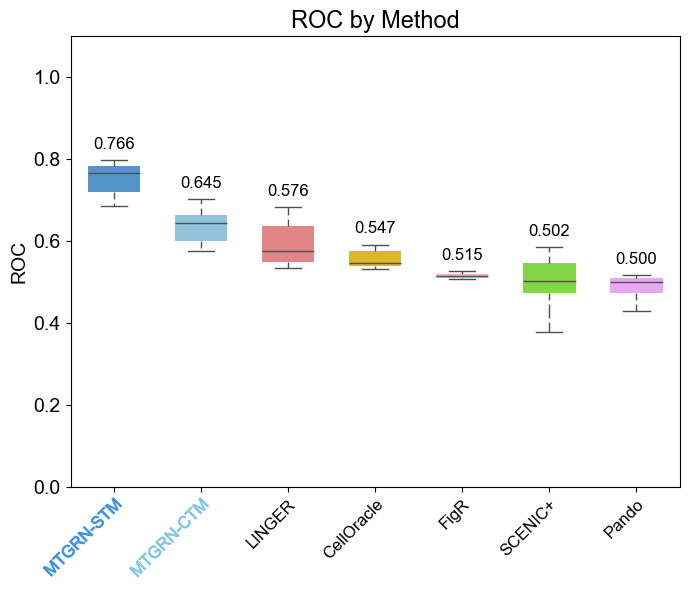

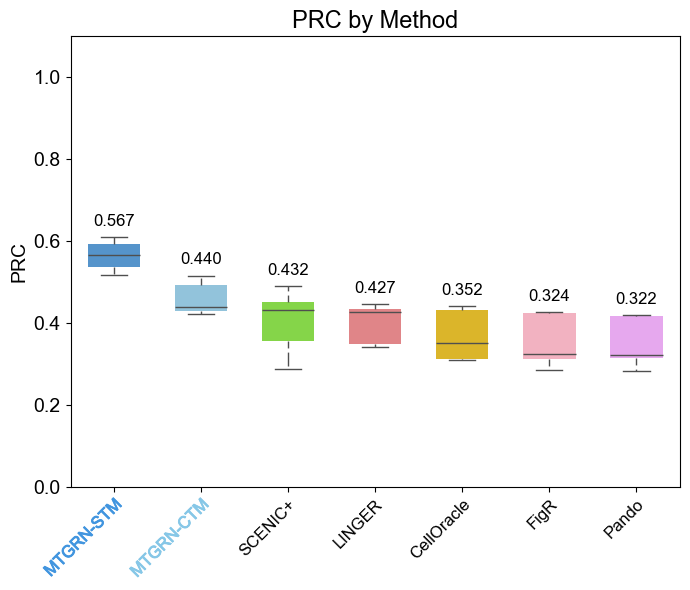

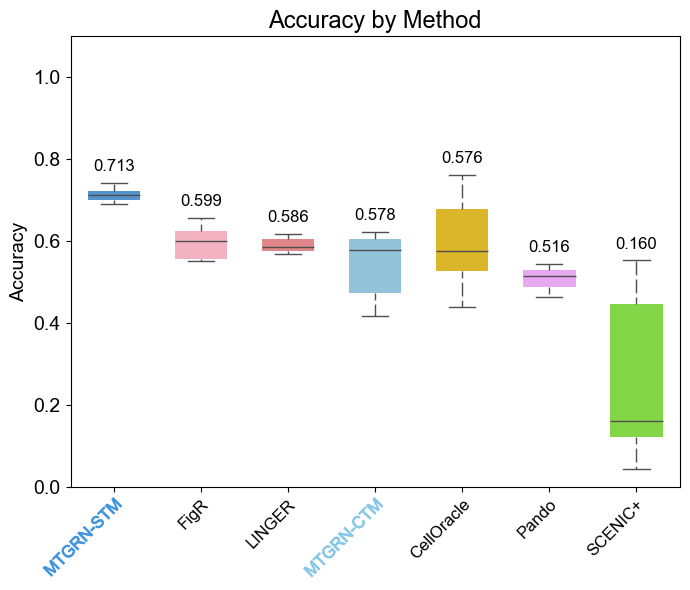

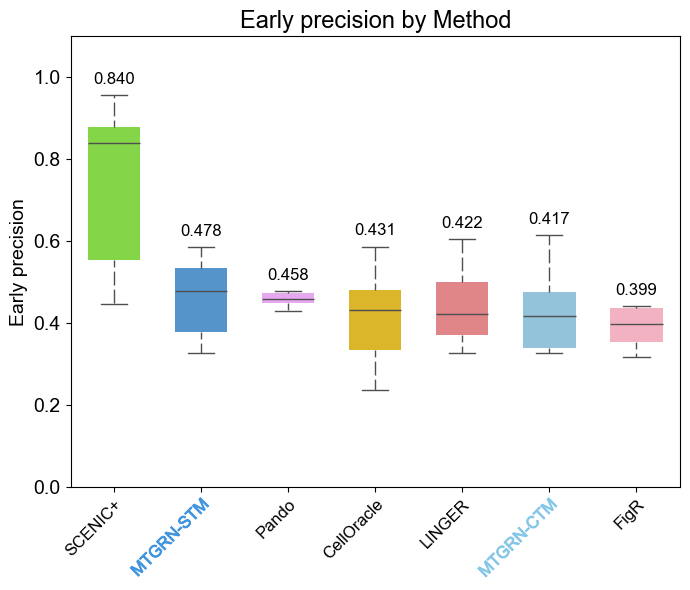

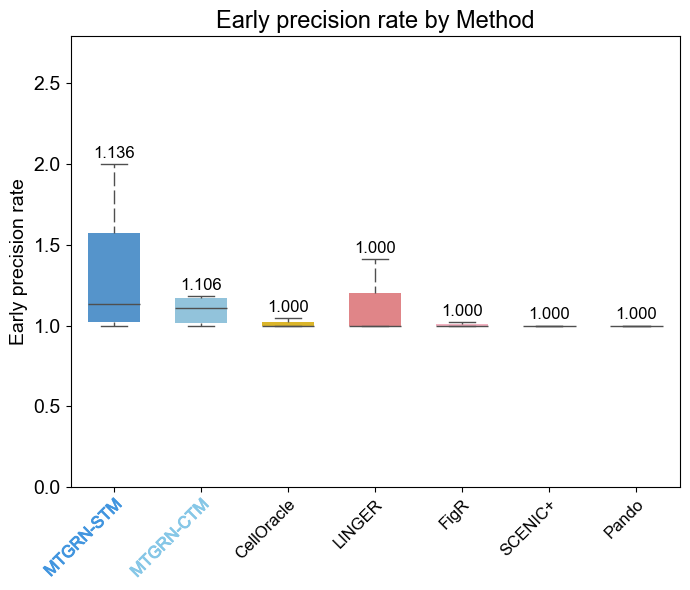

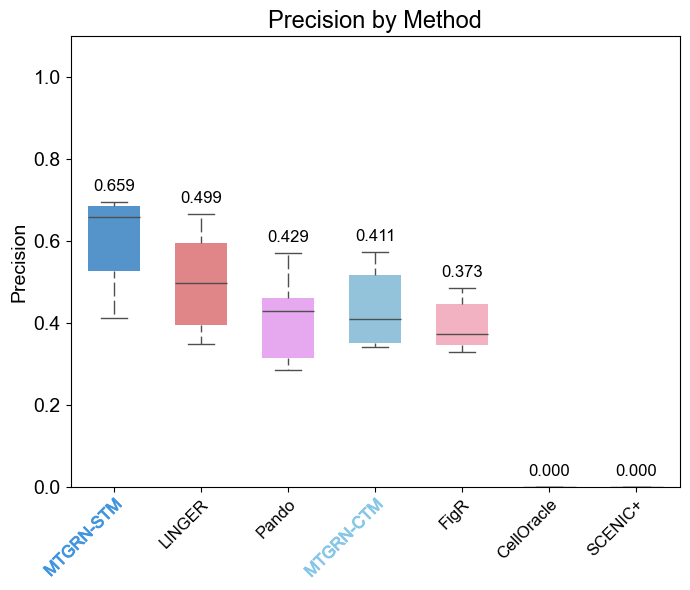

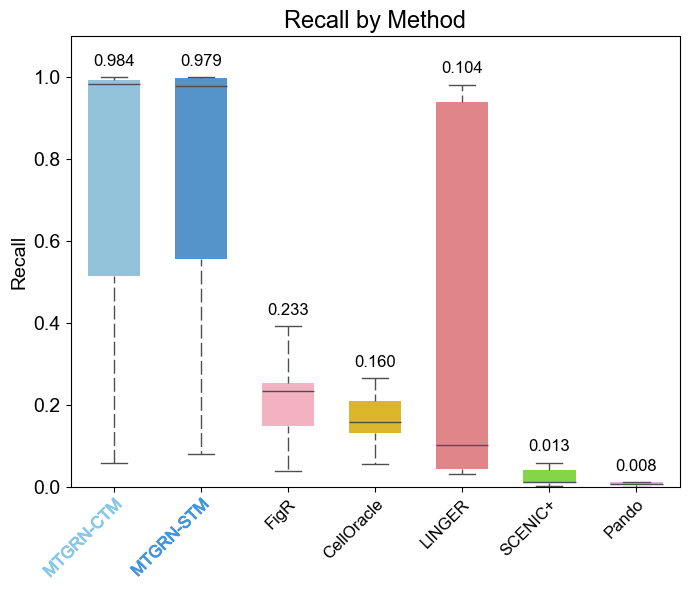

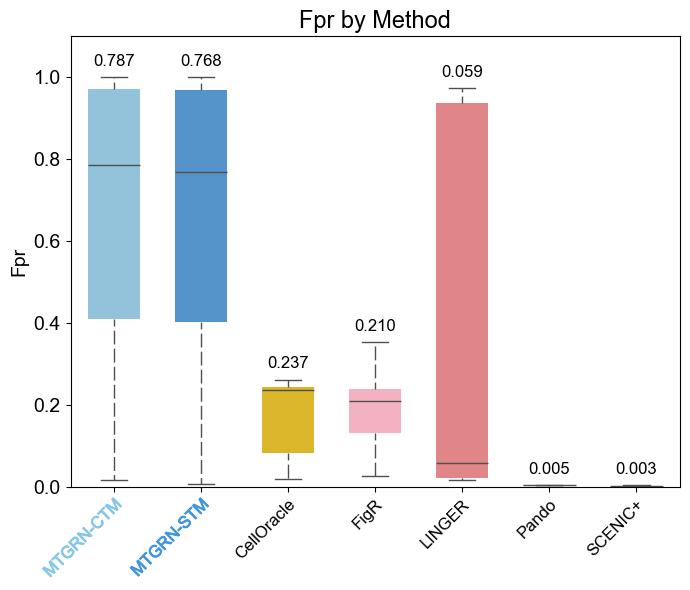

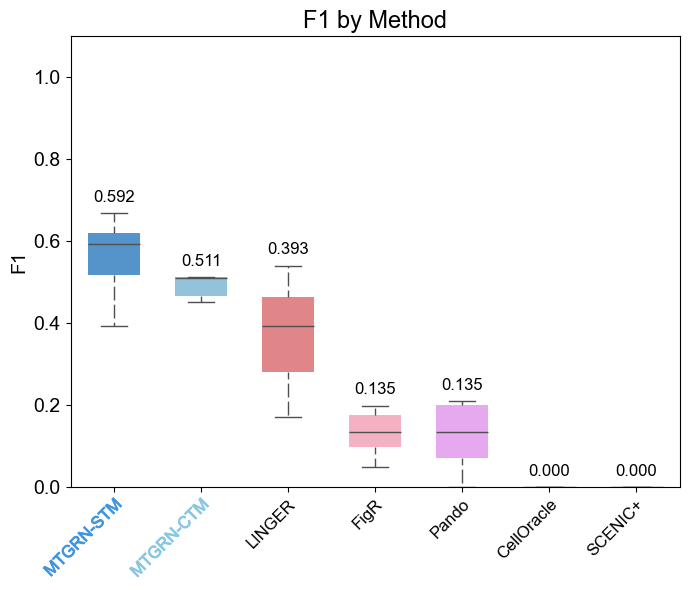

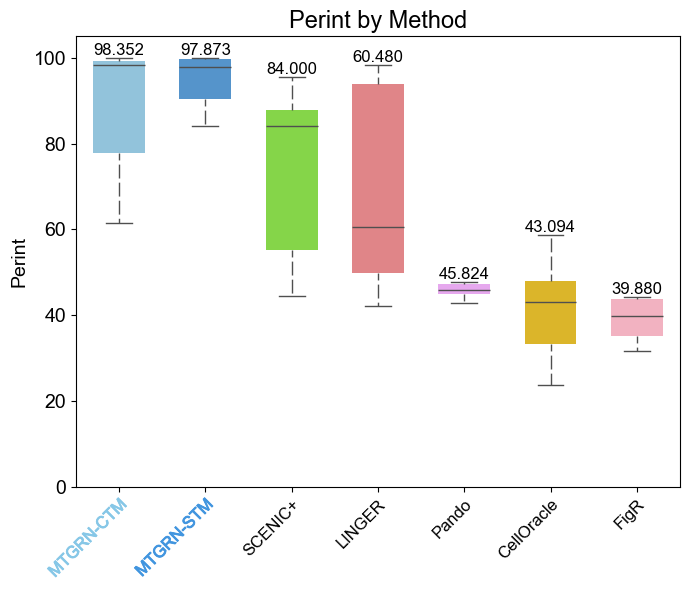

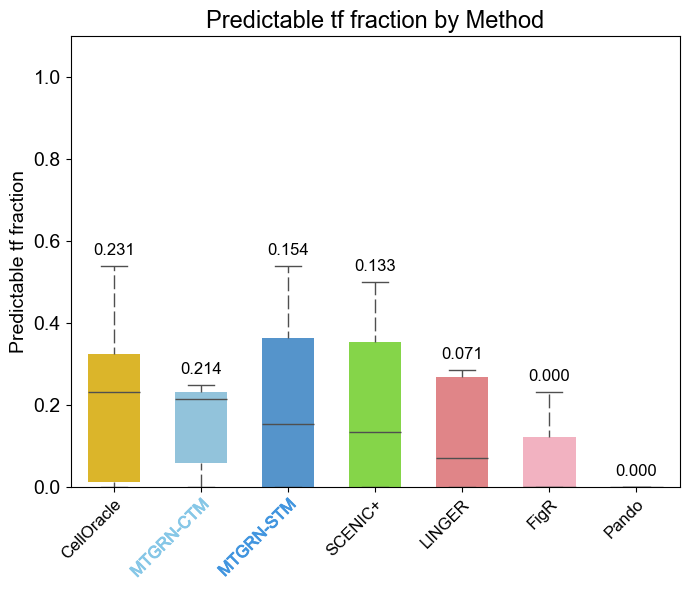

In [19]:
font_path = fm.findfont("Arial", fallback_to_default=False)

# Selected columns by method box and whisker plot
methods = [
    "auroc", 
    "auprc", 
    "accuracy", 
    "early_precision", 
    "early_precision_rate",
    "precision", 
    "recall", 
    "fpr",
    "f1", 
    "perint", 
    "predictable_tf_fraction"
    ]

method_box_and_whisker_plots = {}
for selected_column in methods:
    
    sanitized_name = selected_column.replace("_", " ").lower()
    if sanitized_name in ["auroc", "auprc"]:
        sanitized_name = sanitized_name.upper()
        sanitized_name = sanitized_name.replace("AU", "")
    else:
        sanitized_name = sanitized_name.capitalize()

    method_comparison_boxplot_fig, method_comparison_boxplot_ax = plot_method_box_and_whisker(
        full_metric_df, 
        selected_column, 
        method_color_dict, 
        sample_rename_map, 
        show_values_above_boxes=True
    )
    
    method_box_and_whisker_plots[selected_column] = (method_comparison_boxplot_fig, method_comparison_boxplot_ax)

    plt.savefig(
        method_comparison_boxplot_dir / f"{sanitized_name.lower()}_by_method_boxplot.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    
all_figure_axes["method_box_and_whisker_plots"] = method_box_and_whisker_plots

### ROC curves

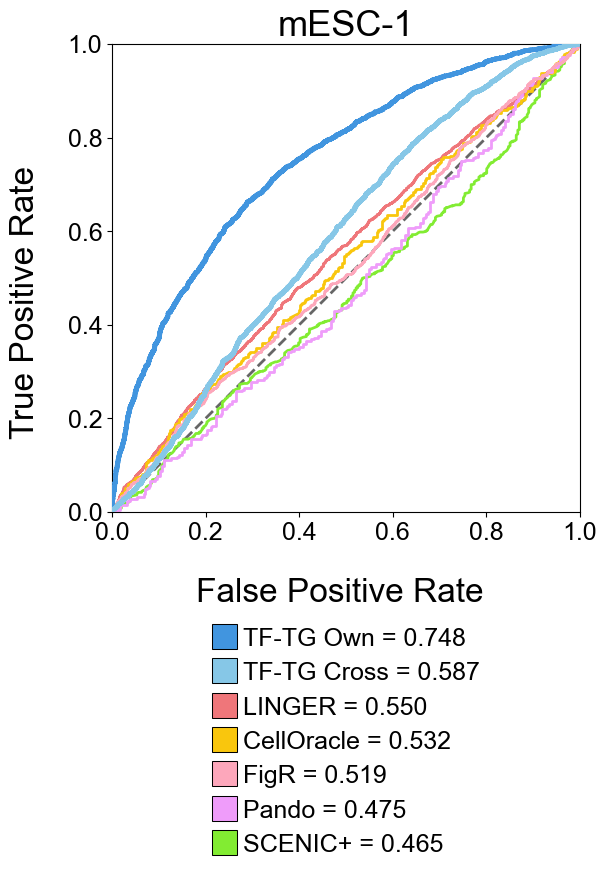

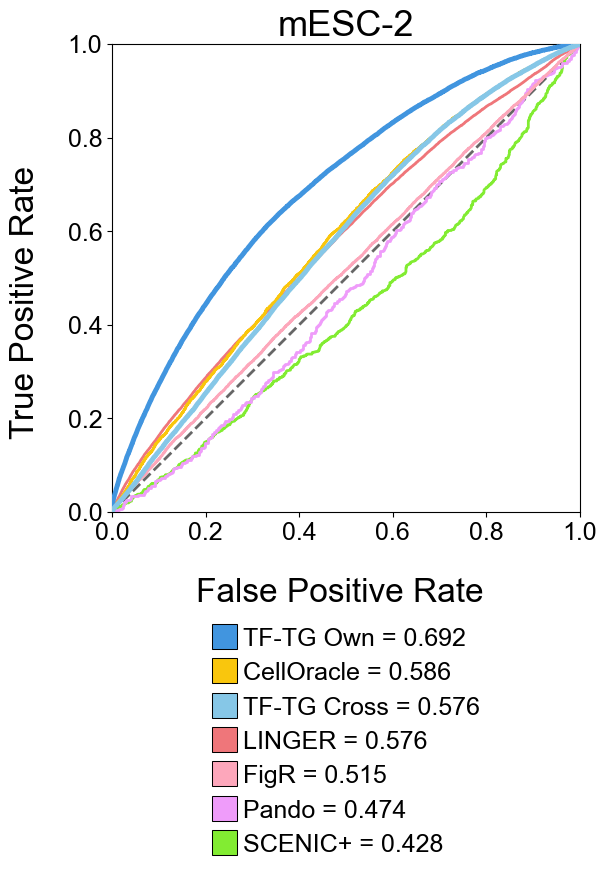

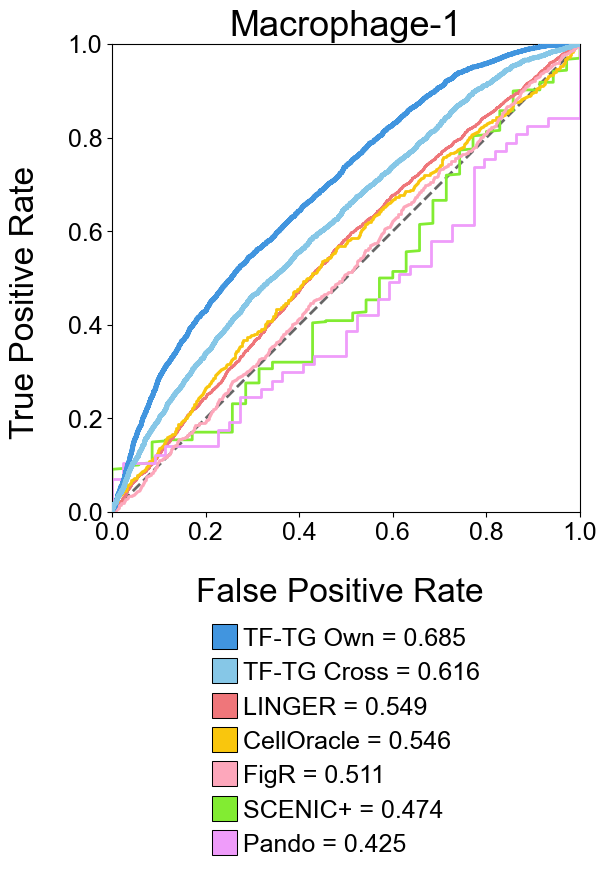

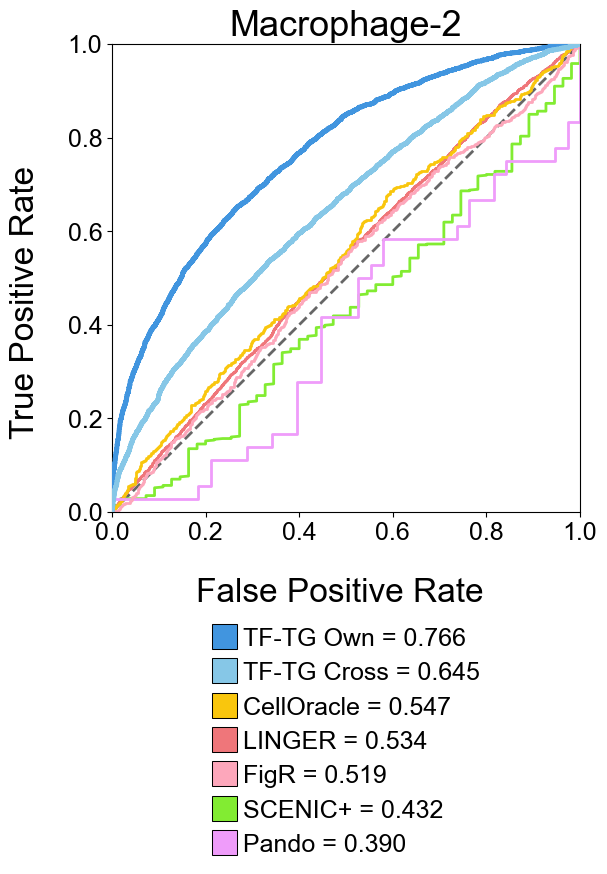

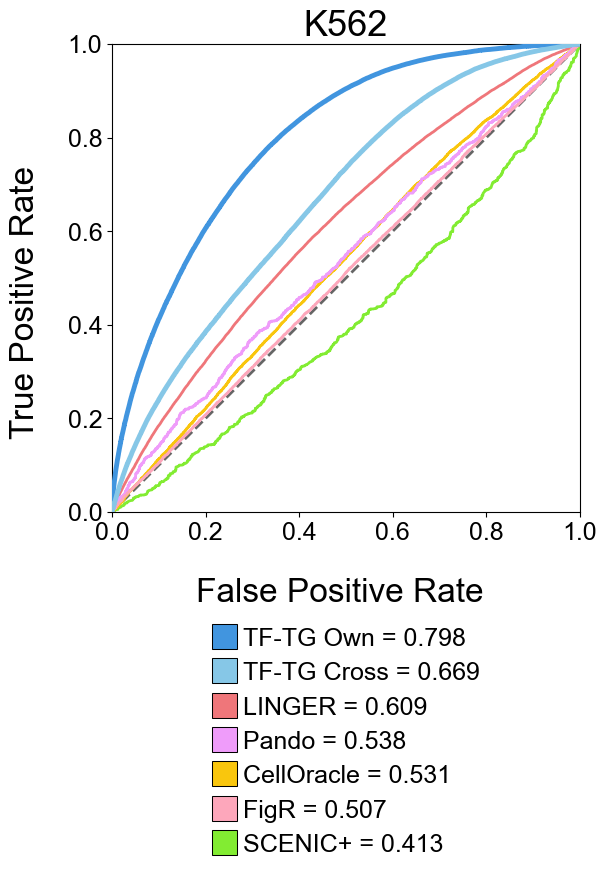

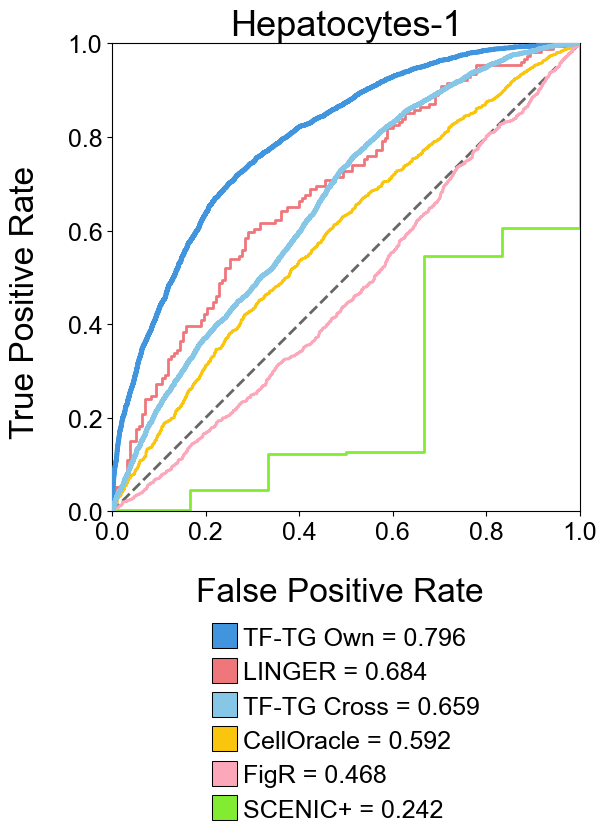

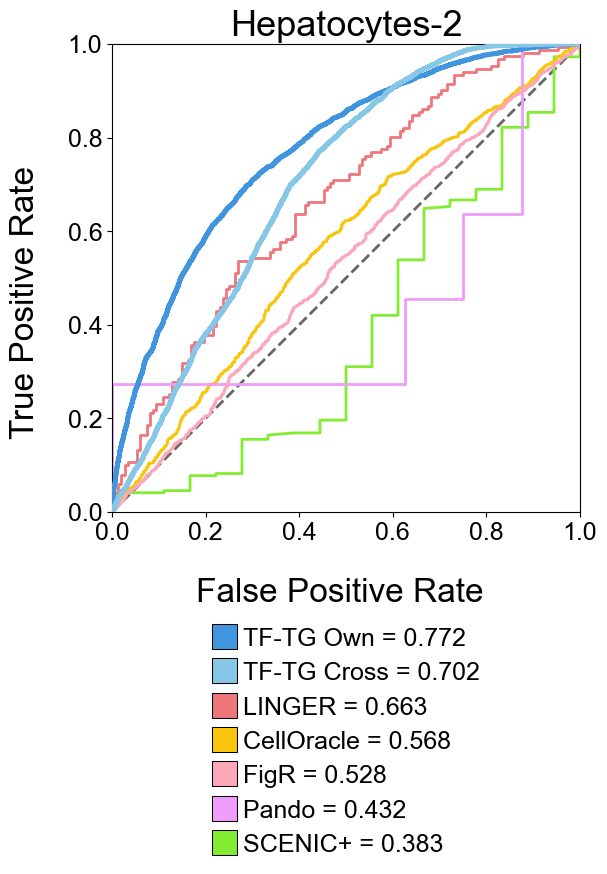

In [20]:
sample_roc_curves = {}
for sample_name in sample_order:
    if sample_name not in standardized_method_dfs:
        continue

    sample_roc_fig, sample_roc_ax = plot_sample_roc_curves(
        sample_name=sample_name,
        standardized_method_dfs=standardized_method_dfs,
        gt_by_sample_dict=gt_by_sample_dict,
        method_color_dict=method_color_dict,
        sample_rename_map=sample_rename_map,
        roc_plot_dir=roc_plot_dir,
        method_display_name_map=method_display_name_map,
        figsize=(6, 6),
    )
    
    sample_roc_curves[sample_name] = (sample_roc_fig, sample_roc_ax)

    plt.show()
    
    sample_roc_fig.savefig(model_vs_other_method_roc_curve_fig_dir / f"{sample_name}_auroc.png", dpi=300, bbox_inches="tight")
    
all_figure_axes["sample_roc_curves"] = sample_roc_curves

### PRC Curves

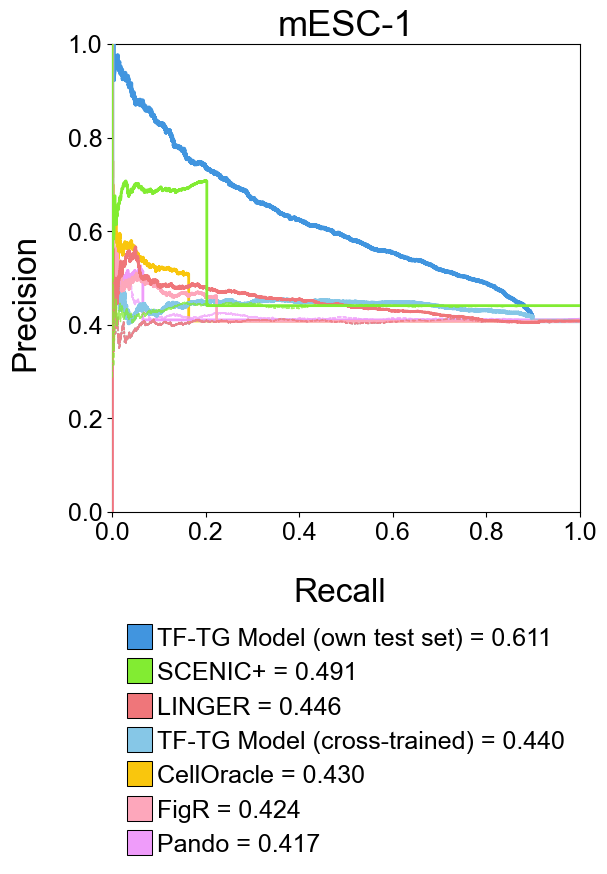

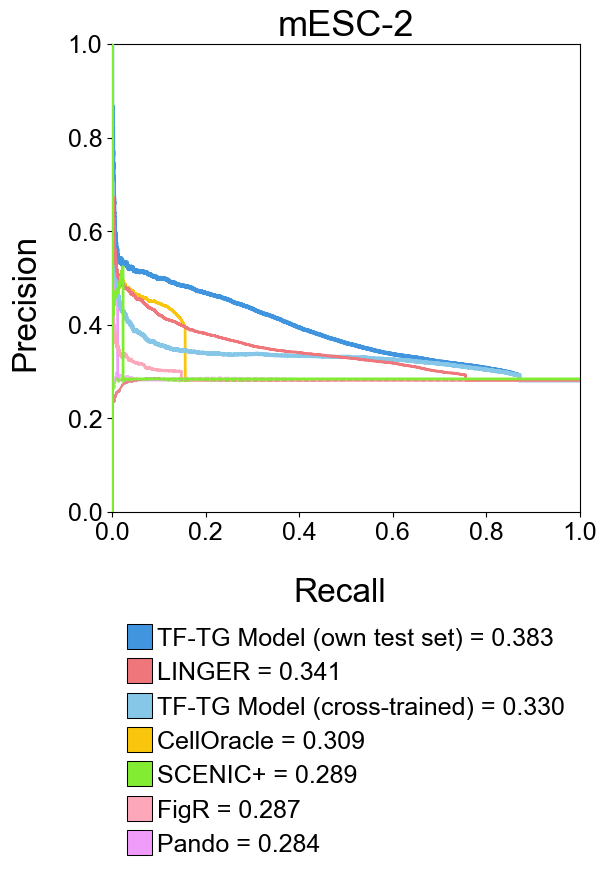

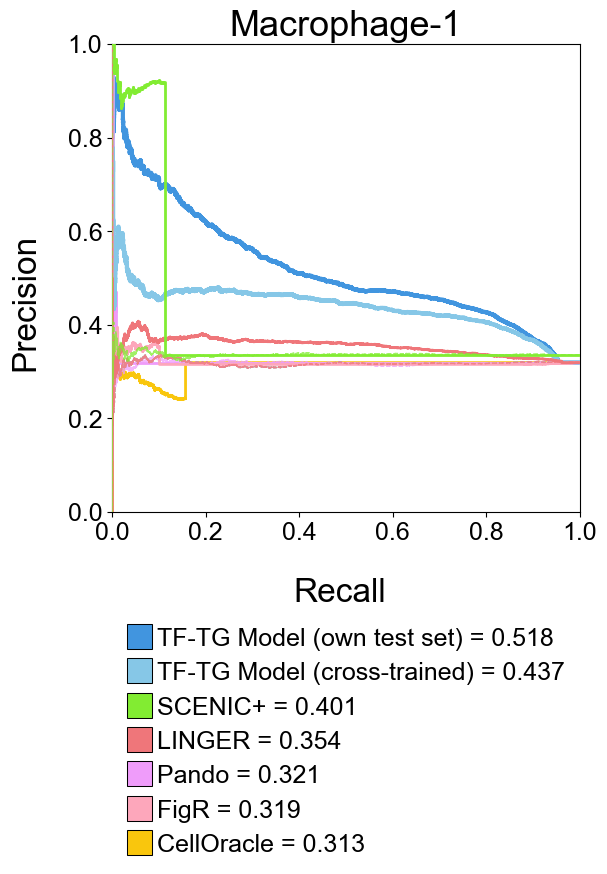

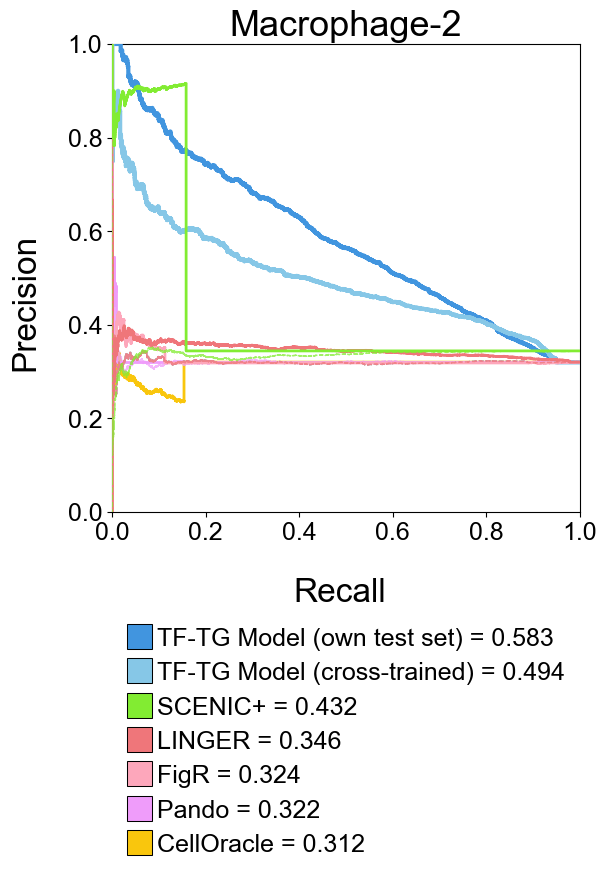

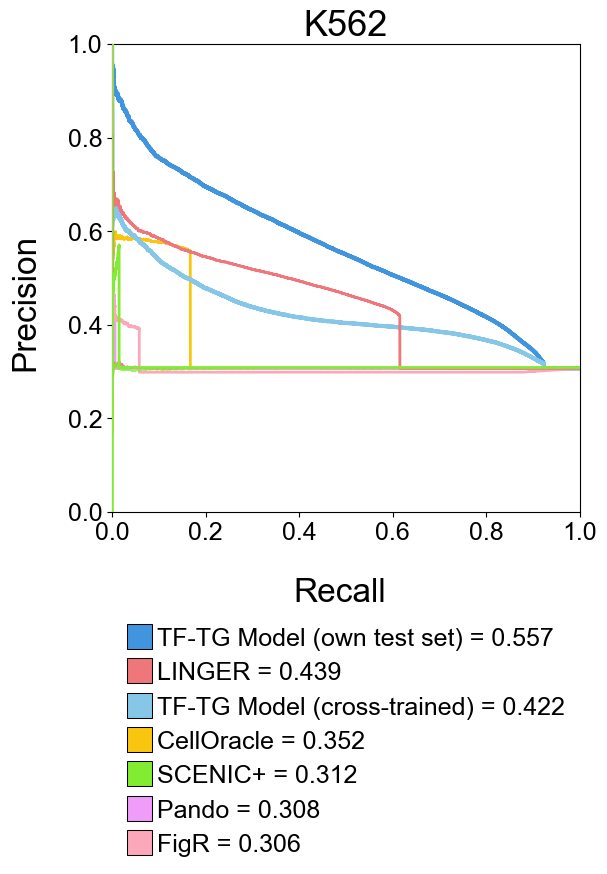

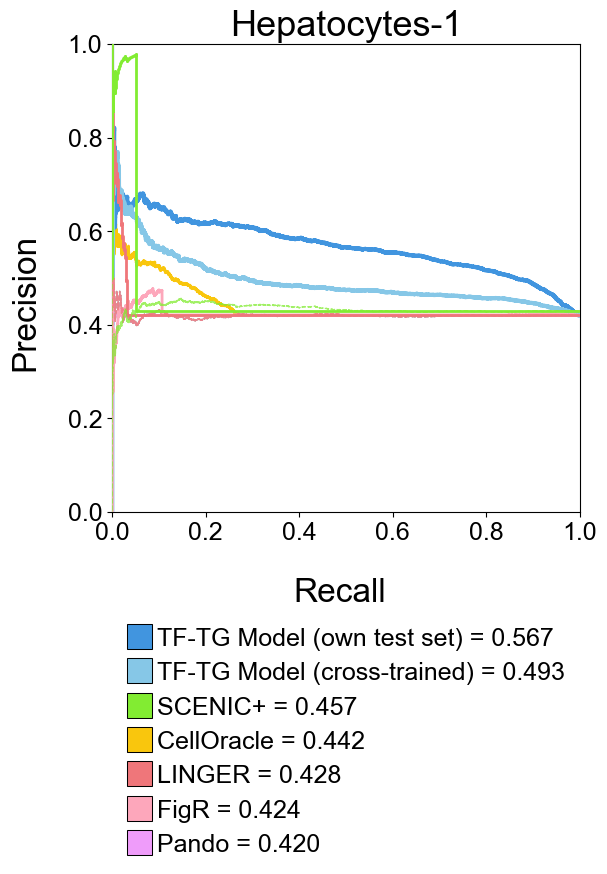

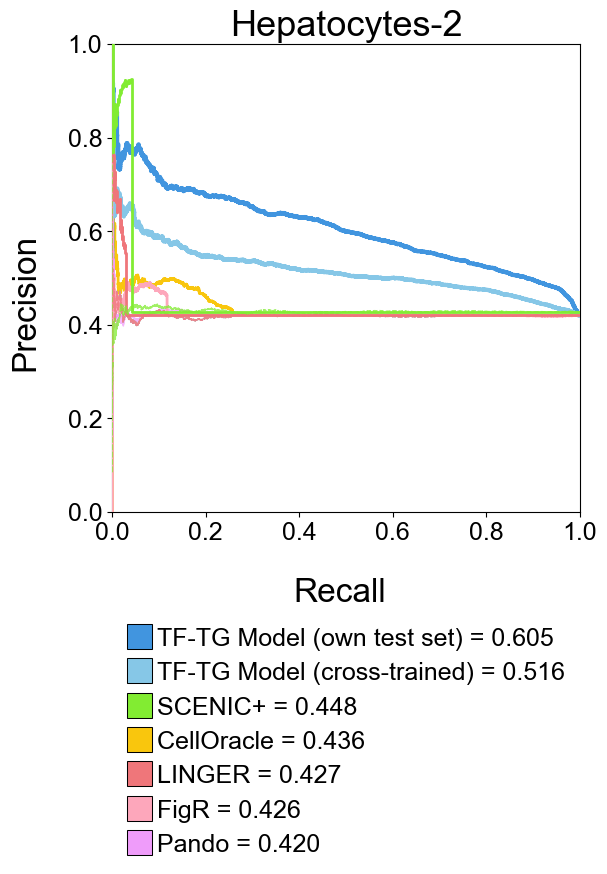

In [21]:
sample_prc_curves = {}
for sample_name in sample_order:
    if sample_name not in auprc_all_method_dfs:
        continue
    
    sample_auprc_fig, sample_auprc_ax = plot_sample_prc_curves(
        sample_name=sample_name,
        auprc_all_method_dfs=auprc_all_method_dfs,
        method_color_dict=method_color_dict,
        sample_rename_map=sample_rename_map,
    )
    
    sample_prc_curves[sample_name] = (sample_auprc_fig, sample_auprc_ax)
    
    plt.show()
    
    sample_auprc_fig.savefig(model_vs_other_method_prc_curve_fig_dir / f"{sample_name}_auprc.png", dpi=300, bbox_inches="tight")
    
all_figure_axes["sample_prc_curves"] = sample_prc_curves

### PRC lift curves

In [22]:
early_auprc_all_method_dfs = {}
for sample_name in sample_order:
    if sample_name not in auprc_all_method_dfs:
        continue
    
    early_auprc_all_method_dfs[sample_name] = {}
    
    for method in auprc_all_method_dfs[sample_name].keys():
        if method not in method_color_dict:
            continue
        
        early_auprc_all_method_dfs[sample_name][method] = {}
        
        auprc_df = auprc_all_method_dfs[sample_name][method]

        auprc_df_sorted = auprc_df.sort_values(by="Score", ascending=False)
        top_ten_percent_count = int(0.1 * len(auprc_df_sorted))
        auprc_df_top_10_pct = auprc_df_sorted.head(top_ten_percent_count).copy()  # Top 10% of edges
        
        early_auprc_all_method_dfs[sample_name][method] = auprc_df_top_10_pct

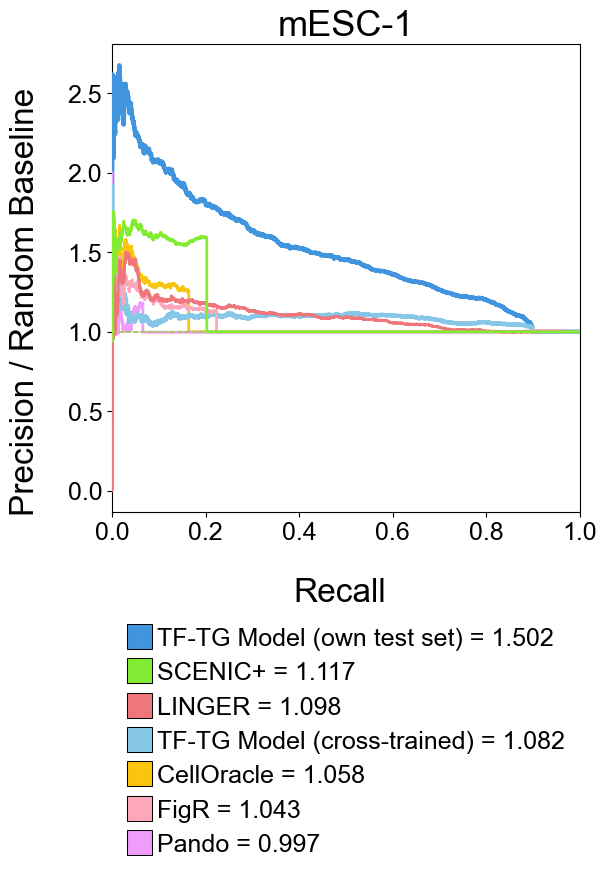

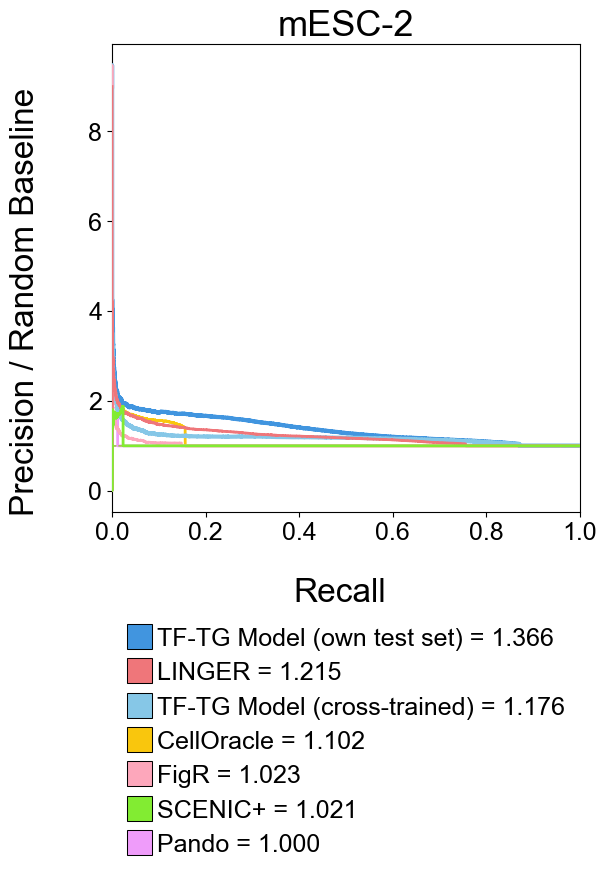

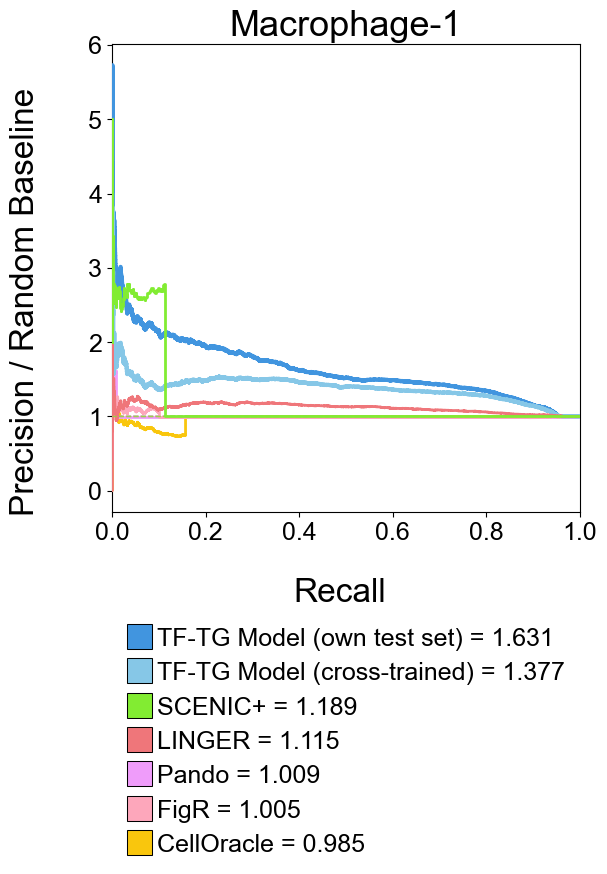

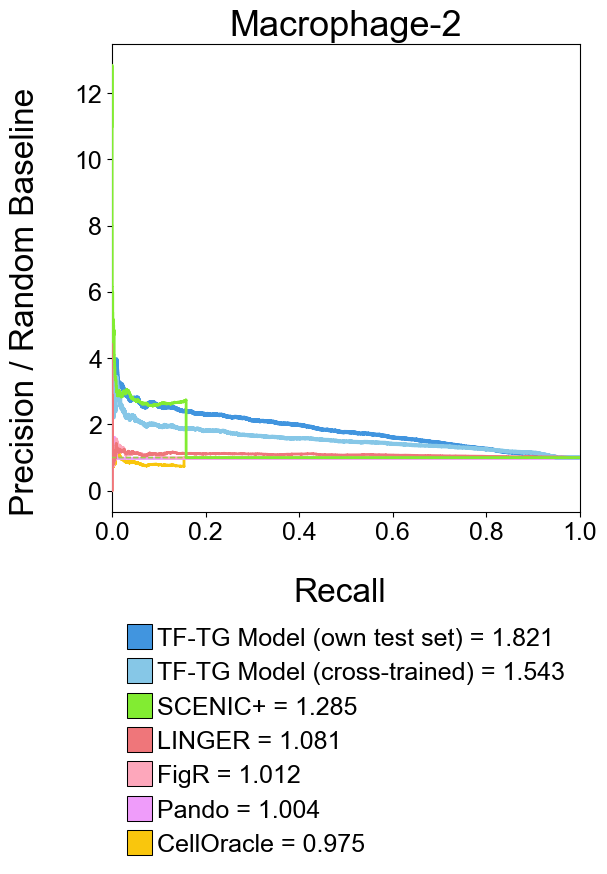

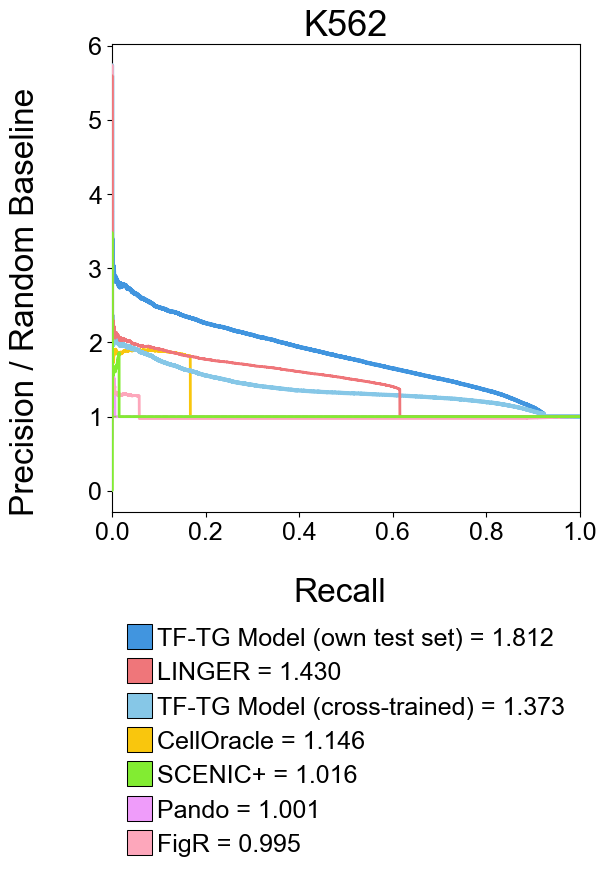

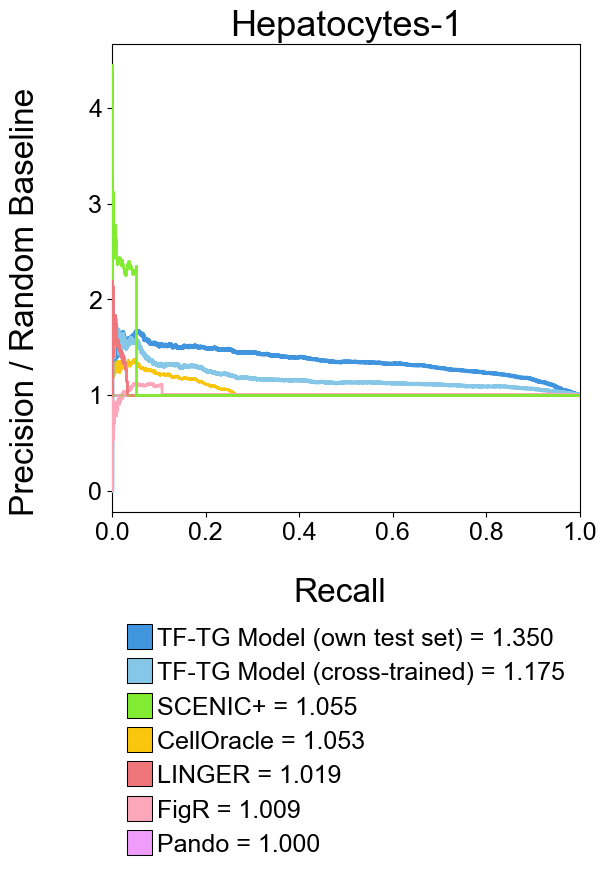

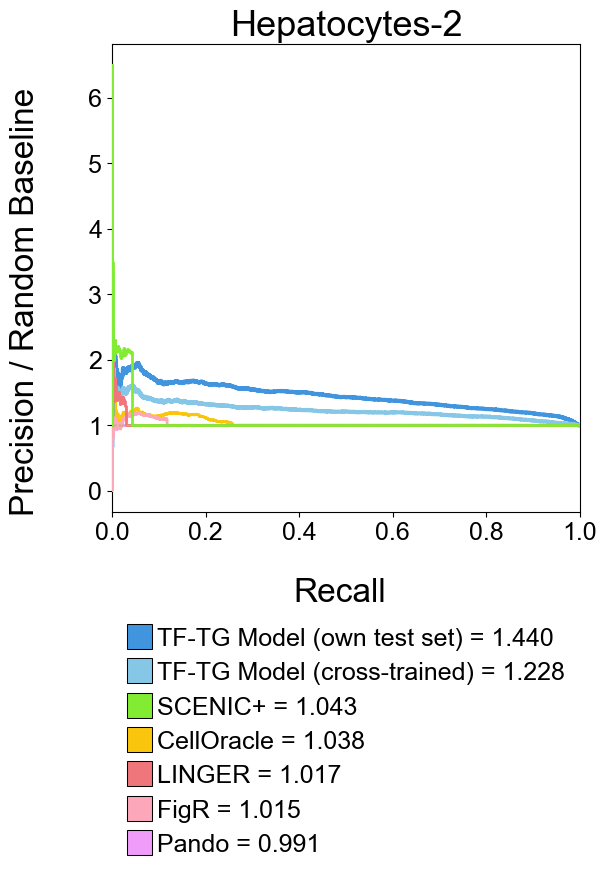

In [23]:
sample_auprc_lift_curves = {}
for sample_name in sample_order:
    if sample_name not in auprc_all_method_dfs:
        continue
    sample_auprc_lift_fig, sample_auprc_lift_ax = plot_sample_prc_curves(
        sample_name=sample_name,
        auprc_all_method_dfs=auprc_all_method_dfs,
        method_color_dict=method_color_dict,
        sample_rename_map=sample_rename_map,
        plot_lift=True
    )
    
    sample_auprc_lift_curves[sample_name] = (sample_auprc_lift_fig, sample_auprc_lift_ax)
    
    plt.show()

    sample_auprc_lift_fig.savefig(model_vs_other_method_prc_curve_fig_dir / f"{sample_name}_auprc_lift.png", dpi=300, bbox_inches="tight")
    
all_figure_axes["sample_auprc_lift_curves"] = sample_auprc_lift_curves

### AUC and PRC Lift

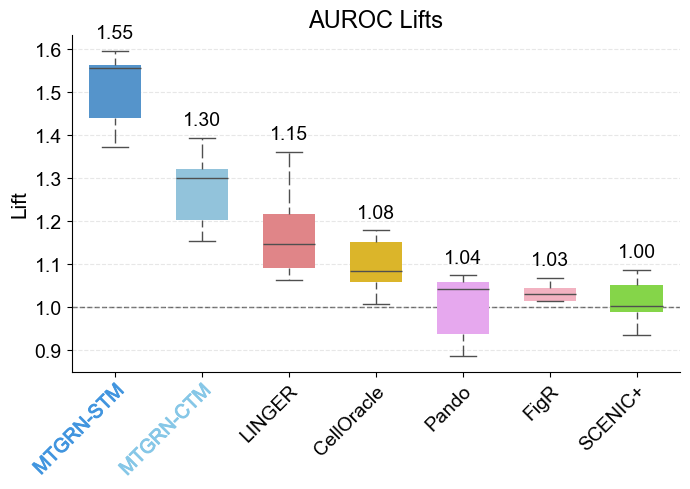

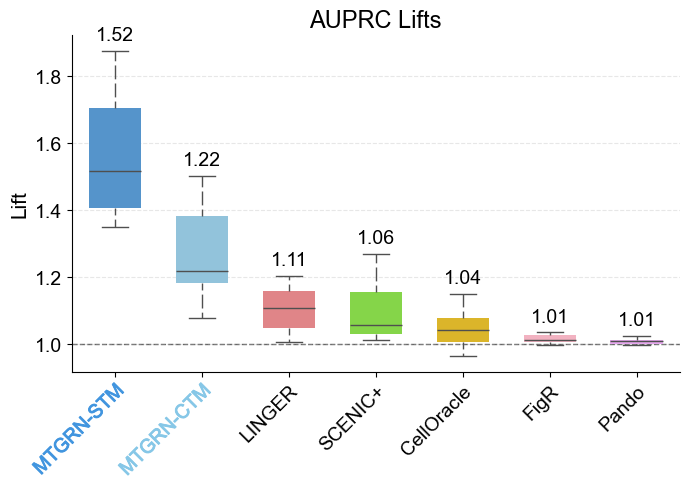

In [24]:
lift_by_metric_boxplots = {}

for metric_col, rand_col, plot_title in [
    ("auroc", "rand_auroc", "AUROC Lifts"),
    ("auprc", "rand_auprc", "AUPRC Lifts"),
]:
    lift_by_method_fig, lift_by_method_ax = lift_by_method_boxplot(
        full_metric_df,
        metric_col=metric_col,
        rand_col=rand_col,
        method_color_dict=method_color_dict,
        title=plot_title,
        sample_rename_map=sample_rename_map,
    )
    
    lift_by_metric_boxplots[metric_col] = (lift_by_method_fig, lift_by_method_ax)
    
    lift_by_method_fig.savefig(
        lift_boxplot_dir / f"{metric_col}_lift_by_method_boxplot.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    
all_figure_axes["lift_by_metric_boxplots"] = lift_by_metric_boxplots

### Rank Plots

/tmp/ipykernel_183334/504978931.py:648: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)


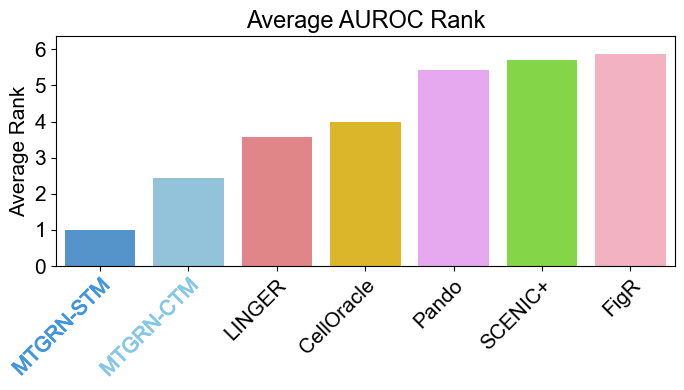

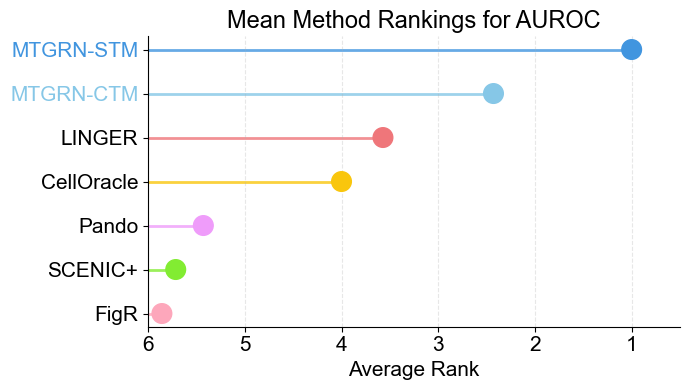

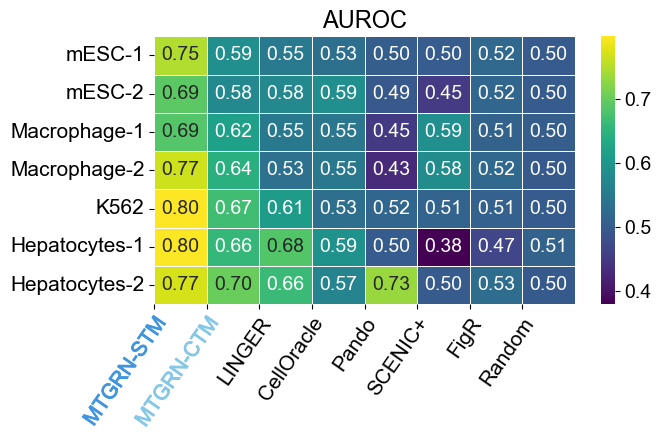

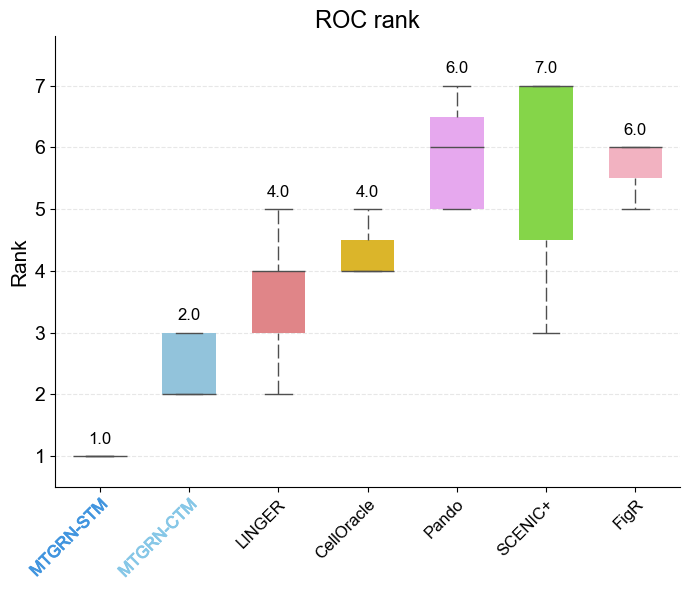

/tmp/ipykernel_183334/504978931.py:648: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)


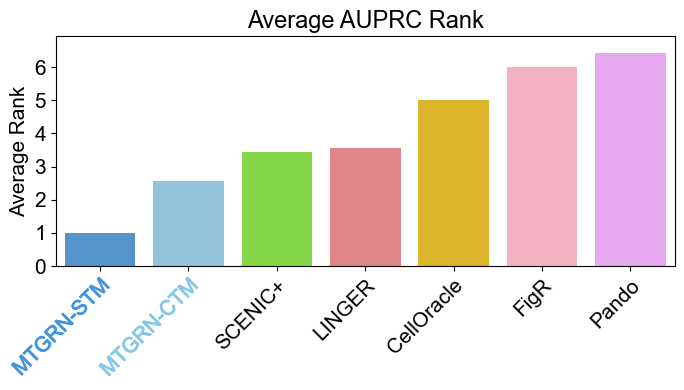

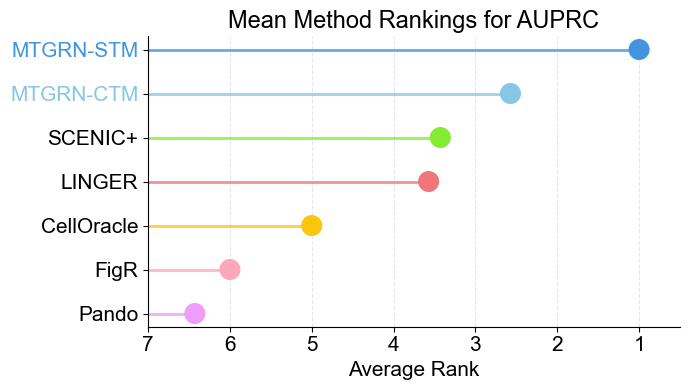

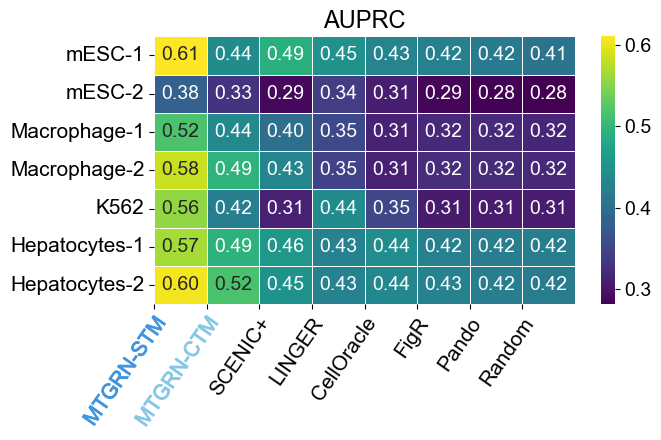

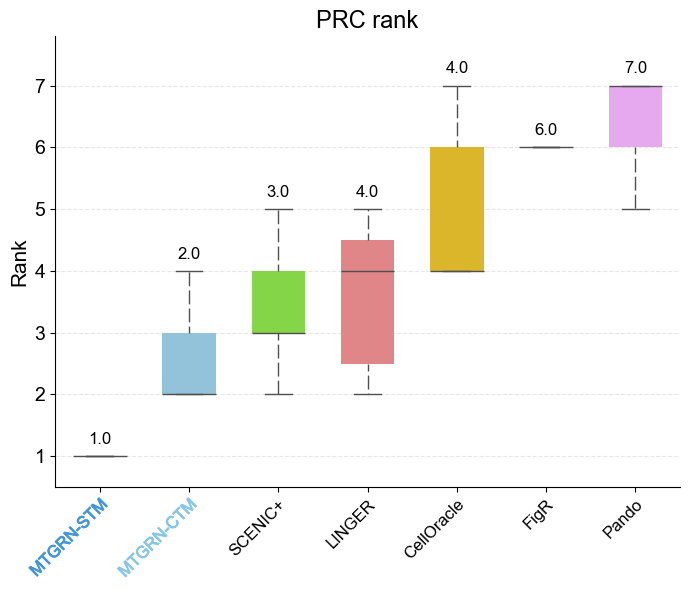

/tmp/ipykernel_183334/504978931.py:648: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)


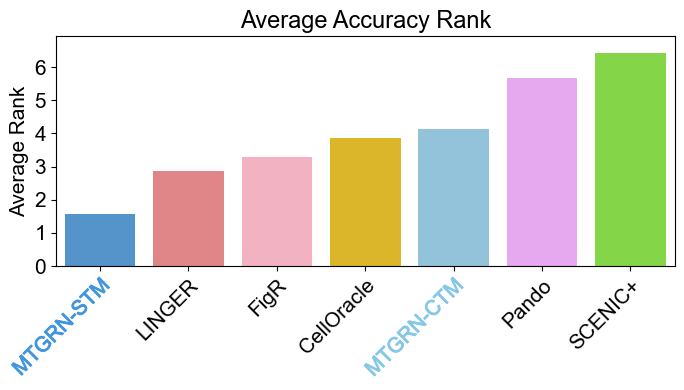

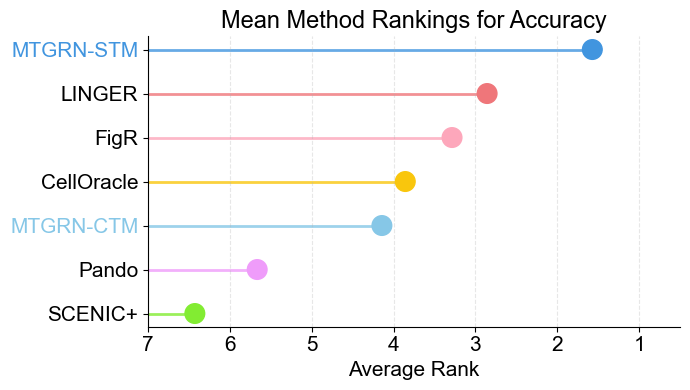

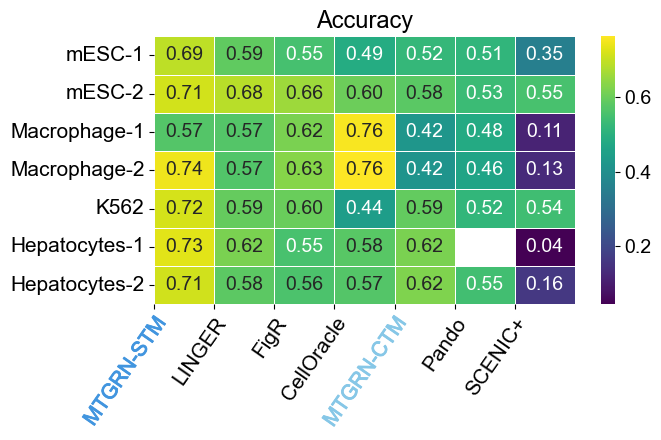

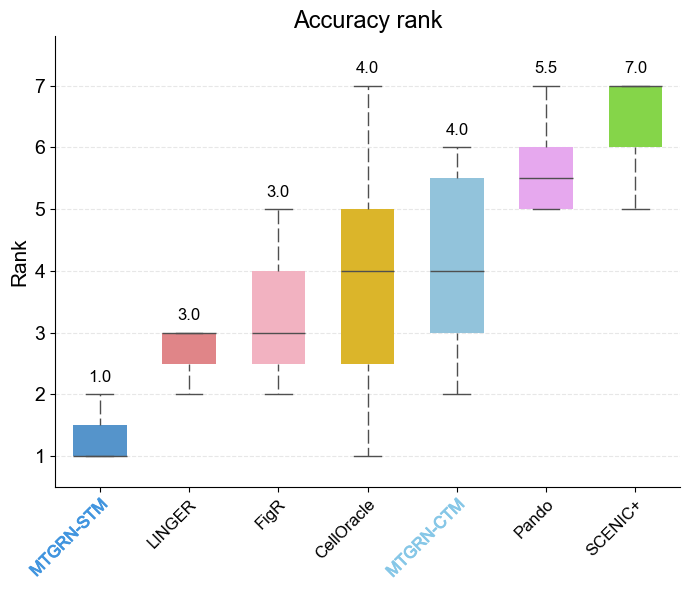

/tmp/ipykernel_183334/504978931.py:648: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)


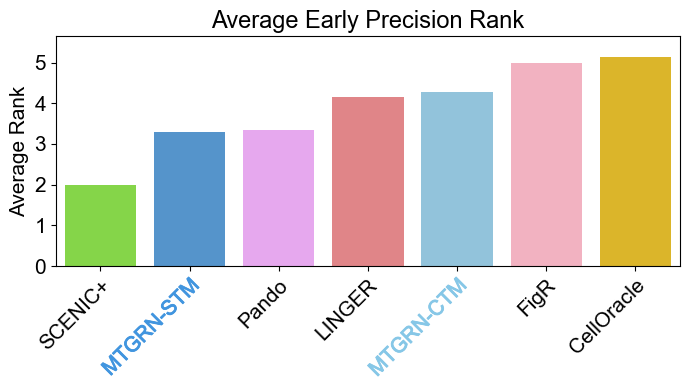

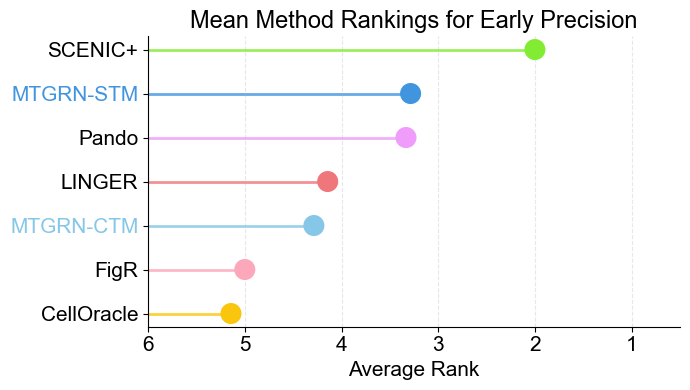

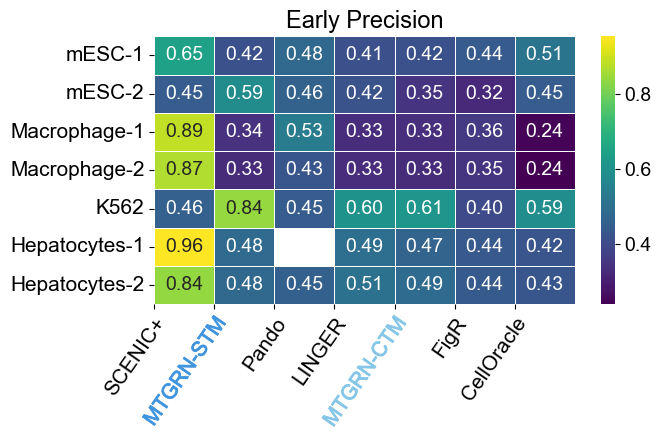

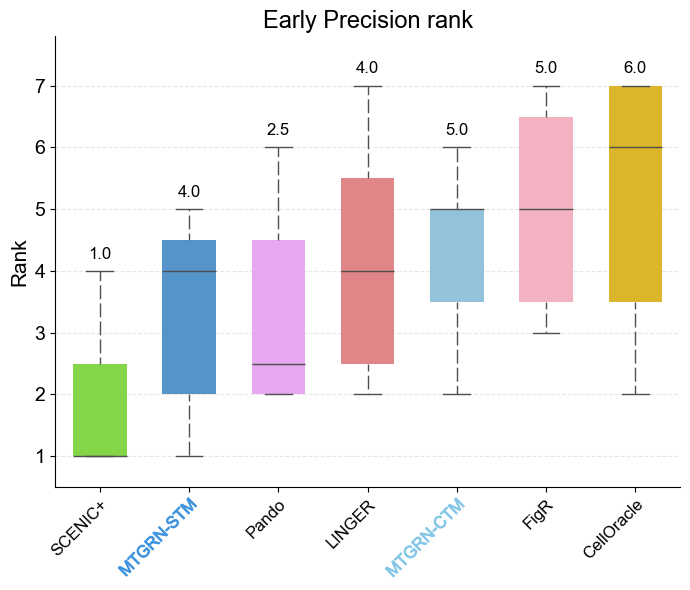

/tmp/ipykernel_183334/504978931.py:648: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)


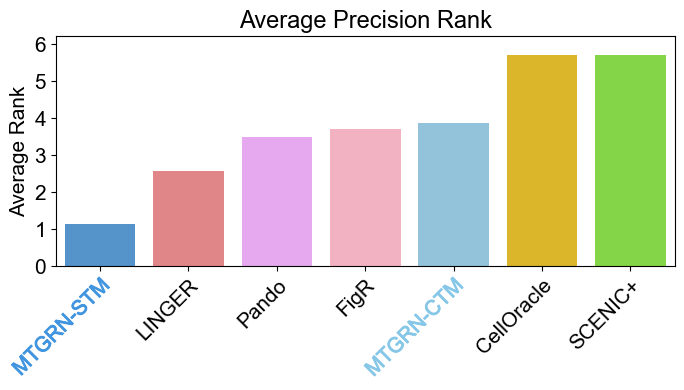

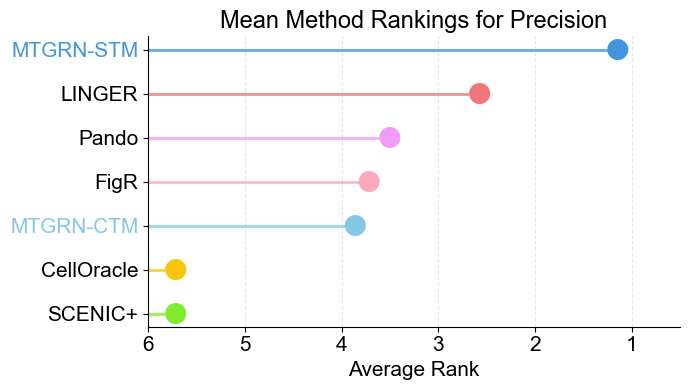

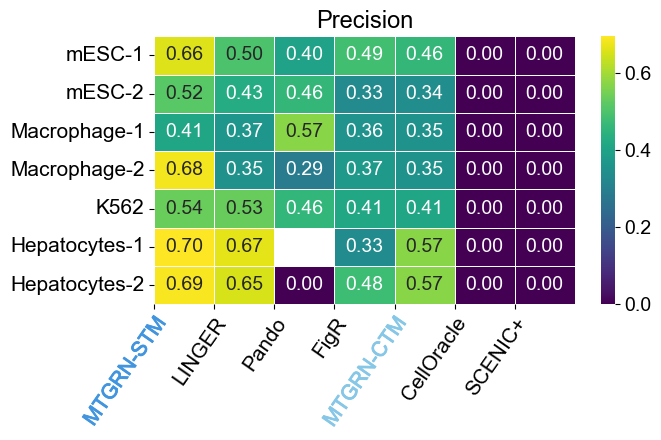

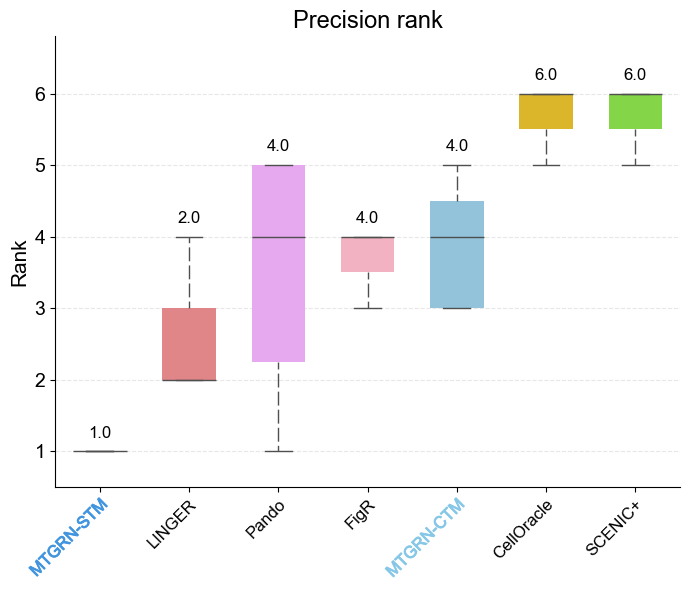

/tmp/ipykernel_183334/504978931.py:648: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)


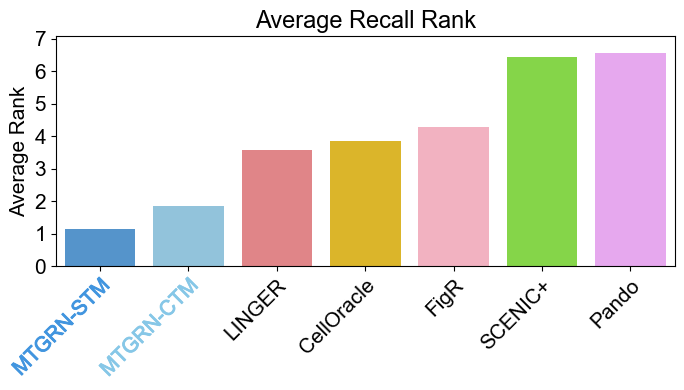

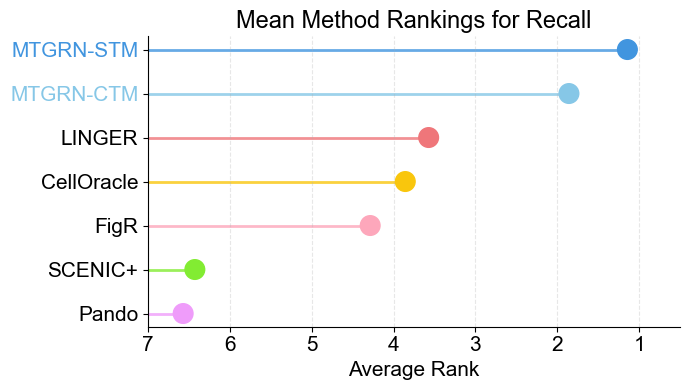

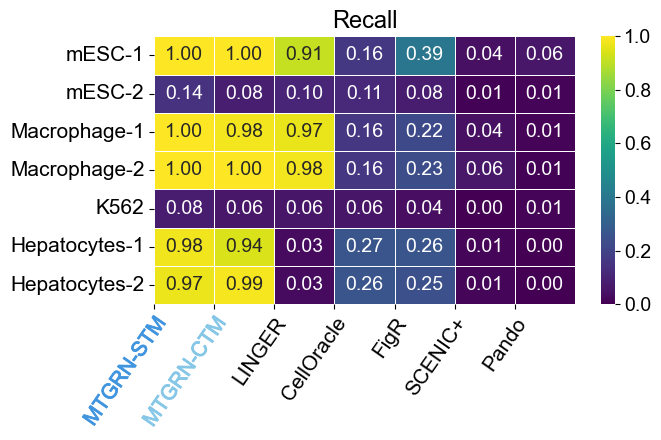

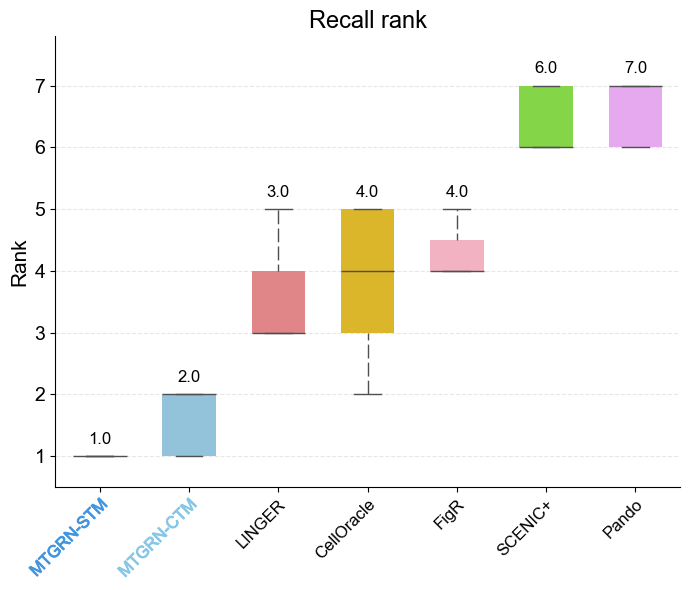

/tmp/ipykernel_183334/504978931.py:648: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)


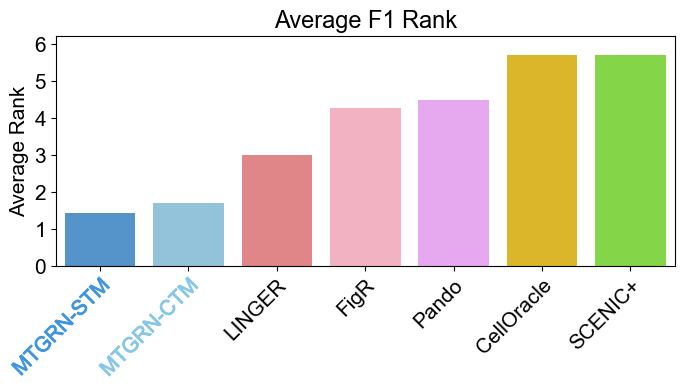

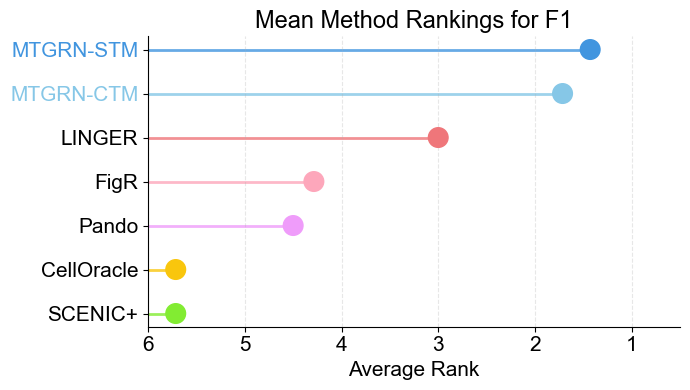

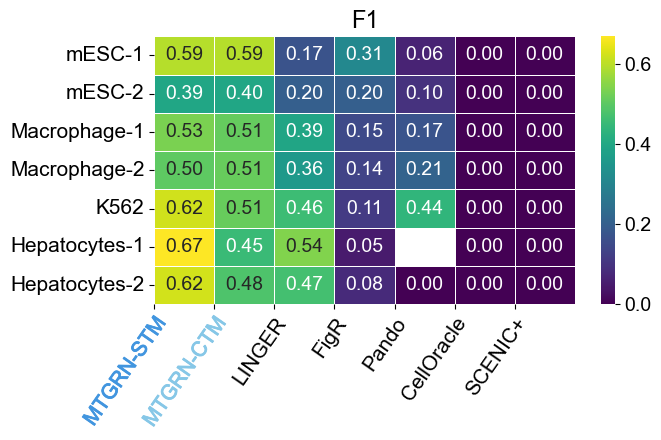

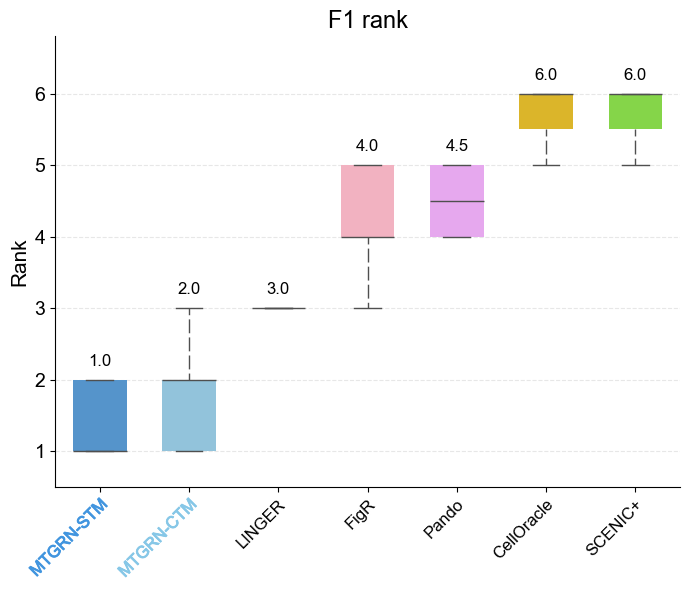

In [25]:
rank_plots = {}
for metric_col in compare_all_method_metrics:
    rank_plots[metric_col] = {}
    metric_label = metric_name_map.get(
        metric_col,
        metric_col.replace("_", " ").title(),
    )
    
    boxplot_metric_label = boxplot_metric_name_map.get(
        metric_col,
        metric_col.replace("_", " ").title(),
    )

    all_ranks_df, rank_df = metric_df_to_rank_df(
        full_metric_df=full_metric_df,
        metric_col=metric_col,
        experiment_col="sample_name",
        method_col="method_name",
        higher_is_better=True,
    )

    safe_metric_name = metric_col.lower().replace(" ", "_")
    
    # Full method average-rank barplot
    full_avg_rank_fig, full_avg_rank_ax = avg_rank_by_method_plot(
        rank_df,
        method_color_dict=method_color_dict,
        title=f"Average {metric_label} Rank",
        sample_rename_map=sample_rename_map,
        figsize=(7, 4),
    )
    
    rank_plots[metric_col]["barplot"] = (full_avg_rank_fig, full_avg_rank_ax)

    full_avg_rank_fig.savefig(
        rank_bar_plot_dir / f"average_{safe_metric_name}_rank_all_methods.png",
        dpi=300,
        bbox_inches="tight",
    )
    
    # Full method average-rank lollipop plot
    full_avg_rank_fig, full_avg_rank_ax = avg_rank_by_method_lollipop_plot(
        rank_df,
        method_color_dict=method_color_dict,
        title=f"Mean Method Rankings for {metric_label}",
        sample_rename_map=sample_rename_map,
        figsize=(7, 4),
    )
    
    rank_plots[metric_col]["lollipop"] = (full_avg_rank_fig, full_avg_rank_ax)

    full_avg_rank_fig.savefig(
        rank_lollipop_plot_dir / f"average_{safe_metric_name}_rank_all_methods_lollipop.png",
        dpi=300,
        bbox_inches="tight",
    )
    
    rand_col = RAND_COL_BY_METRIC.get(metric_col)

    if rand_col is not None and rand_col in full_metric_df.columns:
        random_baseline = (
            full_metric_df
            .groupby("sample_name")[rand_col]
            .median()
        )
    else:
        random_baseline = None

    # Full method rank heatmap
    full_rank_heatmap_fig, full_rank_heatmap_ax = experiment_by_method_rank_heatmap(
        all_ranks_df,
        rank_df,
        method_color_dict=method_color_dict,
        sample_order=sample_order,
        sample_rename_map=sample_rename_map,
        title=f"{metric_label}",
        figsize=(7, 4.5),
        square_cells=False,
        color_xticks=True,
        show_values_in_boxes=True,
        random_baseline_series=random_baseline,
    )
    
    rank_plots[metric_col]["heatmap"] = (full_rank_heatmap_fig, full_rank_heatmap_ax)

    full_rank_heatmap_fig.savefig(
        rank_heatmap_plot_dir / f"{safe_metric_name}_rank_heatmap_all_methods.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
        
    full_rank_boxplot_fig, full_rank_boxplot_ax = rank_by_method_boxplot(
        all_ranks_df,
        rank_df,
        method_color_dict=method_color_dict,
        title=f"{boxplot_metric_label} rank",
        sample_rename_map=sample_rename_map,
        figsize=(7, 6),
        color_xticks=True,
        show_values_above_boxes=True,
        showfliers=False,
    )
    
    rank_plots[metric_col]["boxplot"] = (full_rank_boxplot_fig, full_rank_boxplot_ax)

    full_rank_boxplot_path = rank_boxplot_plot_dir / f"{safe_metric_name}_rank_boxplot_all_methods.png"
    full_rank_boxplot_fig.savefig(
        full_rank_boxplot_path,
        dpi=300,
        bbox_inches="tight",
    )
    
    plt.show()
    
all_figure_axes["rank_plots"] = rank_plots

---

## Evaluate TF-DNA Model Performance

### TF-DNA Performance Functions

In [26]:
def create_tf_peak_index_to_name_mappings(training_data):
    #series to dict
    tf_name_to_idx_dict = training_data["tf_name_to_idx_df"].set_index("tf_name")["tf_idx"].to_dict()
    peak_name_to_idx_dict = training_data["peak_name_to_idx_df"].set_index("peak_id")["peak_idx"].to_dict()

    tf_idx_to_name = {idx: name for name, idx in tf_name_to_idx_dict.items()}
    peak_idx_to_name = {idx: name for name, idx in peak_name_to_idx_dict.items()}
    return tf_idx_to_name, peak_idx_to_name


def load_tf_dna_training_data(
    cell_type: str,
    batch_size: int = 64,
):
    training_cache_dir = DATA_DIR / f"{cell_type}_cache"
    tf_dna_input_cache_dir = training_cache_dir / "tf_dna_training_cache"
    
    # Shared cache files for both TF-to-TG and TF-to-DNA training
    tf_embedding_cache_path = training_cache_dir / "tf_embeddings.pt"
    tf_mask_cache_path = training_cache_dir / "tf_masks.pt"
    
    # TF-DNA training specific cache files
    tf_dna_edge_tf_idx_cache_path = tf_dna_input_cache_dir / "edge_tf_idx.pt"
    tf_dna_edge_peak_idx_cache_path = tf_dna_input_cache_dir / "edge_peak_idx.pt"
    tf_dna_edge_labels_cache_path = tf_dna_input_cache_dir / "edge_labels.pt"
    tf_dna_tf_lengths_cache_path = tf_dna_input_cache_dir / "tf_lengths.pt"
    tf_dna_peak_onehot_cache_path = tf_dna_input_cache_dir / "peak_onehot_array.pt"
    
    tf_dna_train_idx_cache_path = tf_dna_input_cache_dir / "train_idx.pt"
    tf_dna_val_idx_cache_path = tf_dna_input_cache_dir / "val_idx.pt"
    tf_dna_test_idx_cache_path = tf_dna_input_cache_dir / "test_idx.pt"
    
    # Name to ID dictionaries
    tf_name_to_idx_cache_path = training_cache_dir / "tf_name_to_idx.csv"
    tf_dna_peak_id_to_idx_cache_path = tf_dna_input_cache_dir / "peak_id_to_idx.csv"

    # Load cached data
    edge_tf_idx_tensor: torch.Tensor = torch.load(tf_dna_edge_tf_idx_cache_path, weights_only=True)
    edge_peak_idx_tensor: torch.Tensor = torch.load(tf_dna_edge_peak_idx_cache_path, weights_only=True)
    edge_labels_tensor: torch.Tensor = torch.load(tf_dna_edge_labels_cache_path, weights_only=True)
    tf_embeddings_tensor: torch.Tensor = torch.load(tf_embedding_cache_path, weights_only=True)
    tf_mask_tensor: torch.Tensor = torch.load(tf_mask_cache_path, weights_only=True)
    peak_tensor: torch.Tensor = torch.load(tf_dna_peak_onehot_cache_path, weights_only=True)
    
    tf_name_to_idx_df = pd.read_csv(tf_name_to_idx_cache_path)
    peak_id_to_idx_df = pd.read_csv(tf_dna_peak_id_to_idx_cache_path)
    
    # Load train/val/test splits
    train_idx: torch.Tensor = torch.load(tf_dna_train_idx_cache_path, weights_only=True)
    val_idx: torch.Tensor = torch.load(tf_dna_val_idx_cache_path, weights_only=True)
    test_idx: torch.Tensor = torch.load(tf_dna_test_idx_cache_path, weights_only=True)

    if peak_tensor.dtype == torch.uint8:
        peak_tensor = peak_tensor.float()

    edge_dataset = tf_dna_train.TFPeakEdgeDataset(
        edge_tf_idx=edge_tf_idx_tensor,
        edge_peak_idx=edge_peak_idx_tensor,
        edge_labels=edge_labels_tensor,
        peak_tensor=peak_tensor,
    )
    
    train_dataset = Subset(edge_dataset, train_idx.tolist())
    val_dataset = Subset(edge_dataset, val_idx.tolist())
    test_dataset = Subset(edge_dataset, test_idx.tolist())

    # Create dataloaders for each split
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=8,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=4,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=4,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=4,
    )
    
    return {
        "train_loader": train_loader,
        "val_loader": val_loader,
        "test_loader": test_loader,
        "tf_embeddings_tensor": tf_embeddings_tensor,
        "tf_mask_tensor": tf_mask_tensor,
        "peak_tensor": peak_tensor,
        "edge_dataset": edge_dataset,
        "tf_name_to_idx_df": tf_name_to_idx_df,
        "peak_name_to_idx_df": peak_id_to_idx_df,
    }


def generate_tf_dna_binding_predictions(cell_type):
    training_data = load_tf_dna_training_data(
        cell_type=cell_type,
        batch_size=512,
    )

    tf_embeddings_tensor = training_data["tf_embeddings_tensor"]
    tf_mask_tensor = training_data["tf_mask_tensor"]

    tf_dna_model = utils.load_tf_dna_model(
        tf_dna_model_path=config.tf_dna_model_checkpoints[cell_type],
        tf_embeddings_tensor=tf_embeddings_tensor,
        tf_mask_tensor=tf_mask_tensor,
        compile_model=False
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = tf_dna_model.model
    model = model.to(device)

    model.eval()

    tf_indices_list = []
    peak_indices_list = []
    all_scores = []
    all_labels = []

    tf_idx_to_name, peak_idx_to_name = create_tf_peak_index_to_name_mappings(training_data)

    test_loader = training_data["test_loader"]

    # print(f"Evaluating on {dataset_split_type} set")
    with torch.inference_mode():
        for batch in tqdm(test_loader, desc="Evaluating", ncols=100):
            
            tf_idx = batch["tf_idx"].long()
            peak_idx = batch["peak_idx"].long()
            labels = batch["label"]

            tf_embedding = tf_embeddings_tensor[tf_idx].to(device, non_blocking=True)
            tf_mask = tf_mask_tensor[tf_idx].to(device, non_blocking=True)

            peak_embedding = batch["peak_embedding"].float().to(device, non_blocking=True)

            binding_logits = model.forward(
                tf_embedding=tf_embedding,
                tf_mask=tf_mask,
                peak_embedding=peak_embedding,
            )

            scores = torch.sigmoid(binding_logits)

            all_scores.append(scores.detach().cpu().numpy().ravel())
            all_labels.append(labels.numpy().ravel())
            
            tf_indices_list.append(tf_idx.numpy().ravel())
            peak_indices_list.append(peak_idx.numpy().ravel())

    all_tf_indices = np.concatenate(tf_indices_list)
    all_peak_indices = np.concatenate(peak_indices_list)
    all_scores_flat = np.concatenate(all_scores)
    all_labels_flat = np.concatenate(all_labels)

    tf_names = [tf_idx_to_name[idx] for idx in all_tf_indices]
    peak_names = [peak_idx_to_name[idx] for idx in all_peak_indices]

    prediction_df = pd.DataFrame({
        "TF": tf_names,
        "DNA": peak_names,
        "Score": all_scores_flat,
        "Label": all_labels_flat
    })
    
    return prediction_df, all_scores_flat, all_labels_flat


### TF-DNA Performance Plotting Functions

In [27]:
def tf_dna_binding_roc_plot(all_scores_flat, all_labels_flat, method_color_dict):
    tf_dna_roc_prc_fig, ax = plt.subplots(figsize=(6, 5))
    ax.set_aspect("equal")

    rng = np.random.default_rng(42)
    random_curve_plotted = False

    fpr, tpr, _ = roc_curve(all_labels_flat, all_scores_flat)
    auroc = roc_auc_score(all_labels_flat, all_scores_flat)

    ax.plot(
        fpr,
        tpr,
        lw=3,
        color=method_color_dict[OWN_MODEL_METHOD],
        label=f"AUROC = {auroc:.3f}",
    )

    # Plot one shuffled/random baseline only
    if not random_curve_plotted:
        rand_scores = rng.permutation(all_scores_flat)
        rand_fpr, rand_tpr, _ = roc_curve(all_labels_flat, rand_scores)
        rand_auroc = roc_auc_score(all_labels_flat, rand_scores)

        ax.plot(
            rand_fpr,
            rand_tpr,
            color="black",
            linestyle="--",
            lw=2,
            alpha=0.6,
            zorder=1,
            label=f"Random = {rand_auroc:.3f}",
        )

        random_curve_plotted = True


    ax.set_title("AUROC", fontsize=30)
    ax.set_xlabel("False Positive Rate", fontsize=20)
    ax.set_ylabel("True Positive Rate", fontsize=20)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.tick_params(axis="both", labelsize=16)

    ax.legend(
        loc="center",
        bbox_to_anchor=(0.5, -0.30),
        frameon=False,
        fontsize=20,
    )

    tf_dna_roc_prc_fig.subplots_adjust(
        left=0.10,
        right=0.72,
        bottom=0.10,
        top=0.90,
    )
    
    return tf_dna_roc_prc_fig, ax


def tf_dna_binding_prc_plot(all_scores_flat, all_labels_flat, method_color_dict):
    tf_dna_prc_fig, ax = plt.subplots(figsize=(6, 5))
    ax.set_aspect("equal")

    rng = np.random.default_rng(42)

    precision, recall, _ = precision_recall_curve(all_labels_flat, all_scores_flat)
    auprc = average_precision_score(all_labels_flat, all_scores_flat)

    ax.plot(
        recall,
        precision,
        lw=3,
        color=method_color_dict[OWN_MODEL_METHOD],
        label=f"AUPRC = {auprc:.3f}",
    )

    # Plot one shuffled/random baseline
    rand_scores = rng.permutation(all_scores_flat)
    rand_precision, rand_recall, _ = precision_recall_curve(all_labels_flat, rand_scores)
    rand_auprc = average_precision_score(all_labels_flat, rand_scores)

    ax.plot(
        rand_recall,
        rand_precision,
        color="black",
        linestyle="--",
        lw=2,
        alpha=0.6,
        zorder=1,
        label=f"Random = {rand_auprc:.3f}",
    )

    ax.set_title("AUPRC", fontsize=30)
    ax.set_xlabel("Recall", fontsize=20)
    ax.set_ylabel("Precision", fontsize=20)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.tick_params(axis="both", labelsize=16)

    ax.legend(
        loc="center",
        bbox_to_anchor=(0.5, -0.35),
        frameon=False,
        fontsize=20,
    )

    tf_dna_prc_fig.subplots_adjust(
        left=0.10,
        right=0.72,
        bottom=0.25,
        top=0.90,
    )

    return tf_dna_prc_fig, ax


### Data - Run TF-DNA Training Model for an Organism

> Note: Requires the sample cache containing TF-DNA training data for the organism

In [28]:
organism_code = "mm10"
cell_type = "mESC"
sample_name = "E7.5_rep1"
cell_type_cache_dir = DATA_DIR / f"{cell_type}_cache"

tf_dna_eval_prediction_df_path = tf_dna_prediction_eval_dir / f"{cell_type}_tf_dna_predictions.csv"
tf_dna_eval_score_path = tf_dna_prediction_eval_dir / f"{cell_type}_tf_dna_scores.npy"
tf_dna_eval_label_path = tf_dna_prediction_eval_dir / f"{cell_type}_tf_dna_labels.npy"

if not all([
        tf_dna_eval_prediction_df_path.exists(),
        tf_dna_eval_score_path.exists(),
        tf_dna_eval_label_path.exists(),
    ]):
    
    if torch.cuda.is_available():
        logging.info("CUDA is available. Using GPU for TF-DNA predictions.")
    
        prediction_df, all_scores_flat, all_labels_flat = generate_tf_dna_binding_predictions(
            cell_type=cell_type
        )

        np.save(tf_dna_eval_score_path, all_scores_flat)
        np.save(tf_dna_eval_label_path, all_labels_flat)

        prediction_df.to_csv(
            tf_dna_eval_prediction_df_path,
            index=False,
        )
    
    else:
        logging.error("CUDA is not available. TF-DNA predictions require a GPU. Please run this on a machine with CUDA support.")
    
else:
    logging.info(f"Loading cached TF-DNA predictions from: {tf_dna_eval_prediction_df_path}")
    prediction_df = pd.read_csv(tf_dna_eval_prediction_df_path)

    logging.info(f"Loading cached TF-DNA scores from: {tf_dna_eval_score_path}")
    all_scores_flat = np.load(tf_dna_eval_score_path)

    logging.info(f"Loading cached TF-DNA labels from: {tf_dna_eval_label_path}")
    all_labels_flat = np.load(tf_dna_eval_label_path)

INFO:root:Loading cached TF-DNA predictions from: /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER/testing_results/tf_dna_prediction_eval_data/mESC_tf_dna_predictions.csv


INFO:root:Loading cached TF-DNA scores from: /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER/testing_results/tf_dna_prediction_eval_data/mESC_tf_dna_scores.npy
INFO:root:Loading cached TF-DNA labels from: /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER/testing_results/tf_dna_prediction_eval_data/mESC_tf_dna_labels.npy


### Generate and Plot TF-DNA Binding Metrics

Accuracy: 0.9181
Precision: 0.9406
Recall: 0.9580
F1-Score: 0.9492
Average Precision: 0.9903
ROC AUC: 0.9633


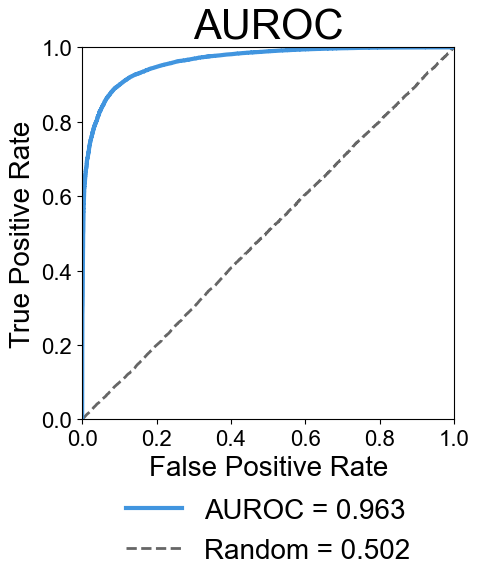

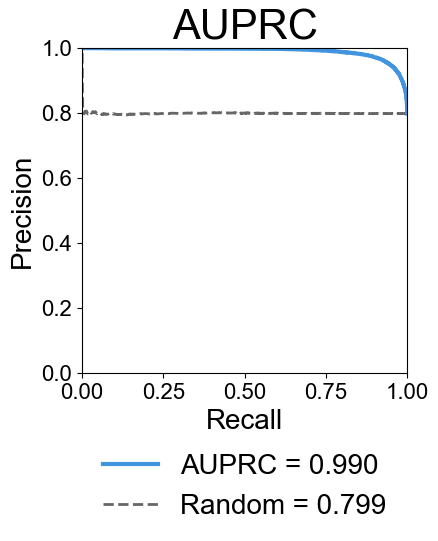

In [29]:
score_threshold = 0.5

# Plot roc curve with scores and labels
accuracy = accuracy_score(all_labels_flat, all_scores_flat > score_threshold)
precision = precision_score(all_labels_flat, all_scores_flat > score_threshold)
recall = recall_score(all_labels_flat, all_scores_flat > score_threshold)
f1 = f1_score(all_labels_flat, all_scores_flat > score_threshold)
auprc = average_precision_score(all_labels_flat, all_scores_flat)
auroc = roc_auc_score(all_labels_flat, all_scores_flat)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Average Precision: {auprc:.4f}")
print(f"ROC AUC: {auroc:.4f}")

tf_dna_roc_fig, tf_dna_roc_ax = tf_dna_binding_roc_plot(
    all_scores_flat=all_scores_flat,
    all_labels_flat=all_labels_flat,
    method_color_dict=method_color_dict,
)

tf_dna_prc_fig, tf_dna_prc_ax = tf_dna_binding_prc_plot(
    all_scores_flat=all_scores_flat,
    all_labels_flat=all_labels_flat,
    method_color_dict=method_color_dict,
)

tf_dna_roc_fig_path = tf_dna_plots / f"roc_{organism_code}_tf_dna_vs_test_set.png"
tf_dna_prc_fig_path = tf_dna_plots / f"prc_{organism_code}_tf_dna_vs_test_set.png"

tf_dna_roc_fig.savefig(
    tf_dna_roc_fig_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.15,
)

tf_dna_prc_fig.savefig(
    tf_dna_prc_fig_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.15,
)

all_figure_axes["tf_dna_roc_fig"] = (tf_dna_roc_fig, tf_dna_roc_ax)
all_figure_axes["tf_dna_prc_fig"] = (tf_dna_prc_fig, tf_dna_prc_ax)

---

## Comparing GRN sizes 

### GRN Size Functions

In [30]:
def create_grn_size_summary_df(
    auprc_grns: dict
    ) -> pd.DataFrame:
    summary_dict = {
        "sample_name": [],
        "method_name": [],
        "num_unique_tfs": [],
        "num_unique_tgs": [],
        "num_edges": [],
    }

    for sample_name, method_dict in auprc_grns.items():
        for method_name in method_dict.keys():
            full_test_set_grn_df = auprc_grns[sample_name][method_name]
                        
            if "Score" not in full_test_set_grn_df.columns:
                logging.warning(f"Missing 'Score' column in GRN DataFrame for sample '{sample_name}', method '{method_name}'. Skipping this entry. Columns: {full_test_set_grn_df.columns.tolist()}")
                continue
            
            full_test_set_grn_df = full_test_set_grn_df[full_test_set_grn_df["Score"] != 0]
            
            num_unique_tfs = full_test_set_grn_df["Source"].nunique()
            num_unique_tgs = full_test_set_grn_df["Target"].nunique()
            num_edges = full_test_set_grn_df.shape[0]
            
            summary_dict["sample_name"].append(sample_name)
            summary_dict["method_name"].append(method_name)
            summary_dict["num_unique_tfs"].append(num_unique_tfs)
            summary_dict["num_unique_tgs"].append(num_unique_tgs)
            summary_dict["num_edges"].append(num_edges)
        
    summary_df = pd.DataFrame(summary_dict)
    return summary_df


def add_percent_edges_vs_own(
    summary_df,
    tf_col="num_unique_tfs",
    tg_col="num_unique_tgs",
    edge_col="num_edges",
    percent_col="percent_of_total_edge_combinations",
):
    plot_df = summary_df.copy()
    
    full_universe_edge_count = plot_df[tf_col] * plot_df[tg_col]

    plot_df[percent_col] = (
        100 * (plot_df[edge_col] / full_universe_edge_count)
    )
    
    return plot_df


def load_and_standardize_method(name: str, info: dict) -> pd.DataFrame:
    """
    Load a GRN CSV and rename tf_col/target_col/score_col -> Source/Target/Score.
    Extra columns are preserved.
    """
    if info["path"].suffix == ".tsv":
        sep = "\t"
    elif info["path"].suffix == ".csv":
        sep = ","
    
    df = pd.read_csv(info["path"], sep=sep, header=0, index_col=None)

    tf_col     = info["tf_col"]
    target_col = info["target_col"]
    score_col  = info["score_col"]

    rename_map = {
        tf_col: "Source",
        target_col: "Target",
        score_col: "Score",
    }

    missing = [c for c in rename_map if c not in df.columns]
    if missing:
        raise ValueError(f"[{name}] Missing expected columns: {missing}. Got: {list(df.columns)}")

    df = df.rename(columns=rename_map)

    df = df[["Source", "Target", "Score"]]
    df["Source"] = df["Source"].astype(str).str.upper()
    df["Target"] = df["Target"].astype(str).str.upper()

    return df


def split_genes_by_chromosome(
    gene_reference_file: Path, 
    train_chroms: list[str] = None, 
    val_chroms: list[str] = None, 
    test_chroms: list[str] = None
    ):
    logging.info(f"Splitting genes into train/val/test based on chromosome:")
    gene_ref_df = gtfparse.read_gtf(gene_reference_file, result_type="pandas")

    gene_chrom: pd.DataFrame = gene_ref_df[["seqname", "gene_name"]].rename(
        columns={"seqname": "chrom", "gene_name": "TG"}
    )
    
    gene_chrom["chrom"] = gene_chrom["chrom"].astype(str).str.replace("^chr", "", regex=True)
    gene_chrom["TG"] = gene_chrom["TG"].str.upper()
    
    train_genes = gene_chrom[gene_chrom["chrom"].isin(train_chroms)][
        "TG"
    ].unique()

    val_genes = gene_chrom[gene_chrom["chrom"].isin(val_chroms)][
        "TG"
    ].unique()

    test_genes = gene_chrom[gene_chrom["chrom"].isin(test_chroms)]["TG"].unique()

    return train_genes, val_genes, test_genes


def load_other_method_grns(other_method_muon_dir: Path, cell_type: str, sample_name: str) -> dict:
    """
    Load GRNs from other methods for a given cell type and sample name.
    Returns a dictionary of DataFrames keyed by method name.`
    """

    linger_path       = other_method_muon_dir / "LINGER_muon" / f"linger_{cell_type}_{sample_name}.tsv"
    scenic_plus_path  = other_method_muon_dir / "SCENIC_muon" / f"scenicplus_{cell_type}_{sample_name}.tsv"
    cell_oracle_path  = other_method_muon_dir / "CellOracle_muon" / f"celloracle_{cell_type}_{sample_name}.tsv"
    pando_path        = other_method_muon_dir / "Pando_muon" / f"pando_{cell_type}_{sample_name}.tsv"
    figr_path         = other_method_muon_dir / "FigR_muon" / f"figr_{cell_type}_{sample_name}.tsv"

    method_info = {
        "SCENIC+":    {"path": scenic_plus_path, "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
        "LINGER":     {"path": linger_path,      "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
        "CellOracle": {"path": cell_oracle_path, "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
        "Pando":      {"path": pando_path,       "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
        "FigR":       {"path": figr_path,        "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
    }

    # Load and standardize the predictions from each method, filtering to only include TFs and TGs present in the ground truth
    standardized_method_dfs = {}
    for method_name, info in method_info.items():
        df_std = load_and_standardize_method(method_name, info)
        
        standardized_method_dfs[method_name] = df_std
        
    return standardized_method_dfs

### GRN Size Plotting Functions

In [31]:

def _clean_name(value):
    """Normalize whitespace while preserving missing values."""
    if pd.isna(value):
        return np.nan
    return " ".join(str(value).replace("\n", " ").split())


def _append_title_suffix(title, suffix):
    """Append a title suffix without accidentally joining words."""
    if suffix is None:
        return title

    suffix = str(suffix).strip()
    return f"{title} {suffix}" if suffix else title


def _format_large_number(value, _position):
    """Format large axis values using K/M/B suffixes."""
    magnitude = abs(value)
    if magnitude >= 1_000_000_000:
        return f"{value / 1_000_000_000:g}B"
    if magnitude >= 1_000_000:
        return f"{value / 1_000_000:g}M"
    if magnitude >= 1_000:
        return f"{value / 1_000:g}K"
    return f"{value:g}"


def _prepare_method_columns(
    plot_df,
    method_color_dict,
    method_rename_map=None,
):
    """
    Create a cleaned/display method column and a matching color dictionary.

    The order of ``method_color_dict`` determines the plotting order. The
    rename map can use either raw or whitespace-cleaned method names.
    """
    if not isinstance(method_color_dict, Mapping) or not method_color_dict:
        raise ValueError("method_color_dict must be a non-empty mapping.")

    rename_map = {
        _clean_name(source): _clean_name(target)
        for source, target in (method_rename_map or {}).items()
        if not pd.isna(source) and not pd.isna(target)
    }

    plot_df = plot_df.copy()
    plot_df["method_name_clean"] = plot_df["method_name"].map(_clean_name)
    plot_df["method_name_clean"] = plot_df["method_name_clean"].map(
        lambda method: rename_map.get(method, method)
        if not pd.isna(method)
        else np.nan
    )

    clean_color_dict = {}
    for method, color in method_color_dict.items():
        clean_method = _clean_name(method)
        if pd.isna(clean_method):
            continue

        display_method = rename_map.get(clean_method, clean_method)
        if (
            display_method in clean_color_dict
            and clean_color_dict[display_method] != color
        ):
            logging.warning(
                "Multiple method_color_dict entries map to %r; using the last color.",
                display_method,
            )
        clean_color_dict[display_method] = color

    methods_in_data = set(plot_df["method_name_clean"].dropna().unique())
    methods_with_color = set(clean_color_dict)

    unmatched_methods = sorted(methods_in_data - methods_with_color)
    if unmatched_methods:
        logging.warning(
            "Dropping method(s) without a color in method_color_dict: %s",
            unmatched_methods,
        )

    unused_colors = sorted(methods_with_color - methods_in_data)
    if unused_colors:
        logging.info(
            "Ignoring method_color_dict entries not present in the data: %s",
            unused_colors,
        )

    method_order = [
        method for method in clean_color_dict if method in methods_in_data
    ]
    if not method_order:
        raise ValueError(
            "No methods in summary_df match the keys in method_color_dict. "
            "Check method spelling and method_rename_map."
        )

    plot_df = plot_df[
        plot_df["method_name_clean"].isin(method_order)
    ].copy()

    return plot_df, clean_color_dict, method_order


def plot_grn_size_boxplot(
    summary_df,
    method_color_dict,
    method_rename_map=None,
    variable_name="num_edges",
    title_suffix=None,
    figsize=(6.5, 4),
    showfliers=False,
):
    """Plot a boxplot of a GRN summary variable for each method."""
    required_columns = {"method_name", variable_name}
    missing_columns = required_columns.difference(summary_df.columns)
    if missing_columns:
        raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

    plot_df = summary_df.copy()
    plot_df[variable_name] = pd.to_numeric(
        plot_df[variable_name], errors="coerce"
    )

    rows_before = len(plot_df)
    plot_df = plot_df.dropna(subset=["method_name", variable_name]).copy()
    dropped_rows = rows_before - len(plot_df)
    if dropped_rows:
        logging.warning(
            "Dropped %d row(s) with missing/non-numeric method or %s values.",
            dropped_rows,
            variable_name,
        )

    plot_df, clean_color_dict, method_order = _prepare_method_columns(
        plot_df=plot_df,
        method_color_dict=method_color_dict,
        method_rename_map=method_rename_map,
    )

    if plot_df.empty:
        raise ValueError("No observations remain after method matching.")

    fig, ax = plt.subplots(figsize=figsize)

    sns.boxplot(
        data=plot_df,
        x="method_name_clean",
        y=variable_name,
        hue="method_name_clean",
        order=method_order,
        hue_order=method_order,
        palette=clean_color_dict,
        showfliers=showfliers,
        width=0.5,
        dodge=False,
        ax=ax,
    )

    if ax.get_legend() is not None:
        ax.get_legend().remove()

    ax.tick_params(axis="x", labelrotation=45, labelsize=12)
    for tick_label in ax.get_xticklabels():
        tick_label.set_horizontalalignment("right")
        tick_label.set_rotation_mode("anchor")

    label_map = {
        "num_edges": "Number of Edges",
        "num_unique_tfs": "Number of Unique TFs",
        "num_unique_tgs": "Number of Unique TGs",
    }
    variable_label = label_map.get(
        variable_name,
        variable_name.replace("_", " ").title(),
    )

    ax.tick_params(axis="y", labelsize=12)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(_format_large_number))
    ax.set_ylabel(variable_label, fontsize=14)
    ax.set_xlabel("")
    title_map = {
        "num_edges": "GRN Edge Counts by Method",
        "num_unique_tfs": "Unique TF Counts by Method",
        "num_unique_tgs": "Unique TG Counts by Method",
    }
    plot_title = title_map.get(
        variable_name,
        f"{variable_label} by Method",
    )
    ax.set_title(
        _append_title_suffix(plot_title, title_suffix),
        fontsize=16,
    )
    ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()
    return fig, ax


def plot_grn_size_jitter(
    summary_df,
    method_color_dict,
    variable_name="num_edges",
    sample_col="sample_name",
    point_size_col="num_unique_tfs",
    sample_order=None,
    sample_rename_map=None,
    title_suffix=None,
    figsize=(10, 5),
    jitter=0.24,
    min_point_size=50,
    max_point_size=250,
    random_seed=42,
    method_rename_map=None,
):
    """
    Plot GRN summary values across samples.

    Point color represents method. Point area represents ``point_size_col``
    when that column is available. Methods are deterministically separated
    within each sample, with a small seeded random jitter for duplicate rows.
    """
    required_columns = {variable_name, sample_col, "method_name"}
    missing_columns = required_columns.difference(summary_df.columns)
    if missing_columns:
        raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

    if jitter < 0:
        raise ValueError("jitter must be non-negative.")
    if min_point_size <= 0 or max_point_size <= 0:
        raise ValueError("Point sizes must be positive.")
    if min_point_size > max_point_size:
        raise ValueError("min_point_size cannot exceed max_point_size.")

    sample_rename_map = sample_rename_map or {}
    plot_df = summary_df.copy()
    plot_df[variable_name] = pd.to_numeric(
        plot_df[variable_name], errors="coerce"
    )

    rows_before = len(plot_df)
    plot_df = plot_df.dropna(
        subset=["method_name", sample_col, variable_name]
    ).copy()
    dropped_rows = rows_before - len(plot_df)
    if dropped_rows:
        logging.warning(
            "Dropped %d row(s) with missing/non-numeric plotting values.",
            dropped_rows,
        )

    plot_df, clean_color_dict, method_order = _prepare_method_columns(
        plot_df=plot_df,
        method_color_dict=method_color_dict,
        method_rename_map=method_rename_map,
    )

    samples_in_data = set(plot_df[sample_col].dropna().unique())
    if sample_order is None:
        sample_order = (
            plot_df[sample_col].dropna().drop_duplicates().tolist()
        )
    else:
        requested = list(sample_order)
        requested_set = set(requested)

        requested_missing = [
            sample for sample in requested if sample not in samples_in_data
        ]
        if requested_missing:
            logging.warning(
                "Dropping requested sample(s) absent from the data: %s",
                requested_missing,
            )

        data_not_requested = sorted(samples_in_data - requested_set)
        if data_not_requested:
            logging.info(
                "Ignoring sample(s) not included in sample_order: %s",
                data_not_requested,
            )

        sample_order = [
            sample for sample in requested if sample in samples_in_data
        ]

    if not sample_order:
        raise ValueError(
            "No requested samples are present after matching sample_order."
        )

    plot_df = plot_df[
        plot_df[sample_col].isin(sample_order)
    ].copy()
    if plot_df.empty:
        raise ValueError("No observations remain after sample filtering.")

    # Assign stable sample locations and method-specific offsets. This is more
    # readable than assigning every point a completely random x displacement.
    sample_to_x = {
        sample: position for position, sample in enumerate(sample_order)
    }
    plot_df["x_position"] = plot_df[sample_col].map(sample_to_x).astype(float)

    if len(method_order) == 1 or jitter == 0:
        method_offsets = np.zeros(len(method_order))
    else:
        method_offsets = np.linspace(-jitter, jitter, len(method_order))
    method_to_offset = dict(zip(method_order, method_offsets))

    rng = np.random.default_rng(random_seed)
    within_method_jitter = (
        min(0.03, jitter / max(4, 2 * len(method_order)))
        if jitter > 0
        else 0.0
    )
    random_offsets = rng.uniform(
        -within_method_jitter,
        within_method_jitter,
        size=len(plot_df),
    )
    plot_df["x_jittered"] = (
        plot_df["x_position"]
        + plot_df["method_name_clean"].map(method_to_offset)
        + random_offsets
    )

    use_size_mapping = (
        point_size_col is not None and point_size_col in plot_df.columns
    )
    size_min = size_max = None

    if use_size_mapping:
        numeric_sizes = pd.to_numeric(
            plot_df[point_size_col], errors="coerce"
        )
        valid_sizes = numeric_sizes[np.isfinite(numeric_sizes)]

        if valid_sizes.empty:
            logging.warning(
                "%s has no finite numeric values; using a constant point size.",
                point_size_col,
            )
            use_size_mapping = False
        else:
            fill_value = float(valid_sizes.median())
            invalid_size_count = int(numeric_sizes.isna().sum())
            if invalid_size_count:
                logging.warning(
                    "Replacing %d invalid %s value(s) with the median (%g).",
                    invalid_size_count,
                    point_size_col,
                    fill_value,
                )
            numeric_sizes = numeric_sizes.fillna(fill_value)
            plot_df[point_size_col] = numeric_sizes
            size_min = float(numeric_sizes.min())
            size_max = float(numeric_sizes.max())

    def scale_point_size(value):
        if not use_size_mapping or size_min is None or size_max is None:
            return 90.0
        if np.isclose(size_max, size_min):
            return (min_point_size + max_point_size) / 2
        return (
            min_point_size
            + (float(value) - size_min) / (size_max - size_min)
            * (max_point_size - min_point_size)
        )

    if use_size_mapping:
        plot_df["point_size"] = plot_df[point_size_col].map(scale_point_size)
    else:
        plot_df["point_size"] = 90.0

    fig, (ax, legend_ax) = plt.subplots(
        ncols=2,
        figsize=figsize,
        gridspec_kw={"width_ratios": [4.2, 1.35], "wspace": 0.02},
    )
    legend_ax.axis("off")

    for method in method_order:
        method_df = plot_df[
            plot_df["method_name_clean"] == method
        ]
        if method_df.empty:
            continue

        ax.scatter(
            method_df["x_jittered"],
            method_df[variable_name],
            s=method_df["point_size"],
            color=clean_color_dict[method],
            label=method,
            alpha=0.85,
            edgecolor="white",
            linewidth=0.7,
            zorder=3,
        )

    formatted_sample_labels = [
        sample_rename_map.get(sample, sample) for sample in sample_order
    ]
    ax.set_xticks(range(len(sample_order)))
    ax.set_xticklabels(
        formatted_sample_labels,
        rotation=45,
        ha="right",
        rotation_mode="anchor",
        fontsize=12,
    )

    label_map = {
        "num_edges": "Number of Edges",
        "num_unique_tfs": "Number of Unique TFs",
        "num_unique_tgs": "Number of Unique TGs",
    }
    title_map = {
        "num_edges": "GRN Edge Counts",
        "num_unique_tfs": "Unique TF Counts",
        "num_unique_tgs": "Unique TG Counts",
    }
    y_label = label_map.get(
        variable_name,
        variable_name.replace("_", " ").title(),
    )
    plot_title = title_map.get(
        variable_name,
        variable_name.replace("_", " ").title(),
    )

    ax.set_xlabel("")
    ax.set_ylabel(y_label, fontsize=14)
    ax.set_title(
        _append_title_suffix(plot_title, title_suffix),
        fontsize=16,
    )
    ax.tick_params(axis="y", labelsize=12)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(_format_large_number))
    ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.25, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    method_handles = [
        Line2D(
            [],
            [],
            linestyle="none",
            marker="o",
            markersize=8,
            markerfacecolor=clean_color_dict[method],
            markeredgecolor="white",
            markeredgewidth=0.7,
            label=method,
        )
        for method in method_order
    ]
    method_legend = legend_ax.legend(
        handles=method_handles,
        title="Method",
        loc="upper left",
        bbox_to_anchor=(0.0, 1.0),
        borderaxespad=0,
        frameon=False,
        fontsize=11,
        title_fontsize=12,
    )
    legend_ax.add_artist(method_legend)

    if use_size_mapping:
        if np.isclose(size_min, size_max):
            size_legend_values = [size_min]
        else:
            size_legend_values = np.linspace(size_min, size_max, 4)
            if np.allclose(size_legend_values, np.round(size_legend_values)):
                size_legend_values = np.round(size_legend_values).astype(int)
            size_legend_values = np.unique(size_legend_values).tolist()

        size_handles = [
            Line2D(
                [],
                [],
                linestyle="none",
                marker="o",
                markersize=np.sqrt(scale_point_size(value)),
                markerfacecolor="dimgray",
                markeredgecolor="white",
                markeredgewidth=0.7,
                label=f"{value:,.0f}",
            )
            for value in size_legend_values
        ]

        size_title_map = {
            "num_edges": "Edges",
            "num_unique_tfs": "TFs",
            "num_unique_tgs": "TGs",
        }
        legend_ax.legend(
            handles=size_handles,
            title=size_title_map.get(
                point_size_col,
                point_size_col.replace("_", " ").title(),
            ),
            loc="lower left",
            bbox_to_anchor=(0.0, 0.0),
            borderaxespad=0,
            frameon=False,
            fontsize=11,
            title_fontsize=12,
            handletextpad=0.8,
            labelspacing=0.8,
        )

    x_padding = max(0.45, jitter + 0.15)
    ax.set_xlim(-x_padding, len(sample_order) - 1 + x_padding)
    fig.subplots_adjust(left=0.10, right=0.98, top=0.88, bottom=0.28)

    return fig, ax

### Data - Load AUPRC and AUROC GRNs

In [32]:
auprc_grns = load_auprc_grns_all_methods()
sample_list = list(auprc_grns.keys())

auroc_grns = {sample: load_generalizability_df(sample, sample) for sample in sample_list}

auprc_summary_df = create_grn_size_summary_df(auprc_grns)

full_grns = {}
for _, sample_name, _, cross_sample_name in samples_to_run:
    self_grn = load_full_grn_df(sample_name, sample_name)
    cross_grn = load_full_grn_df(cross_sample_name, sample_name)
    full_grns[sample_name] = {}
    full_grns[sample_name][OWN_MODEL_METHOD] = self_grn
    full_grns[sample_name][CROSS_MODEL_METHOD] = cross_grn

In [33]:
OTHER_METHOD_MUON_DIR = Path("/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/other_method_grns")
PROJECT_DATA_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data")

MOUSE_TF_LIST_FILE = PROJECT_DATA_DIR / "databases" / "motif_information" / "mm10" / "TF_Information_all_motifs.txt"
HUMAN_TF_LIST_FILE = PROJECT_DATA_DIR / "databases" / "motif_information" / "hg38" / "TF_Information_all_motifs.txt"

def load_species_test_set_genes(species: str, project_data_dir: Path):
    if species == "mouse":
        gene_ref_file = project_data_dir / "genome_data" / "genome_annotation" / "mm10" / "Mus_musculus.GRCm39.115.gtf.gz"
        train_chroms = [str(i) for i in range(1, 16)]
        val_chroms = [str(i) for i in range(16, 18)]
        test_chroms = [str(i) for i in range(18, 20)]
    elif species == "human":
        gene_ref_file = project_data_dir / "genome_data" / "genome_annotation" / "hg38" / "Homo_sapiens.GRCh38.113.gtf.gz"
        train_chroms = [str(i) for i in range(1, 18)]
        val_chroms = [str(i) for i in range(18, 20)]
        test_chroms = [str(i) for i in range(20, 23)]
    else:
        logging.warning(f"Unknown species '{species}'. Skipping.")
    
    train_set_genes, val_set_genes, test_set_genes = split_genes_by_chromosome(
        gene_reference_file=gene_ref_file,
        train_chroms=train_chroms,
        val_chroms=val_chroms,
        test_chroms=test_chroms
    )

    return test_set_genes

mouse_tf_list = pd.read_csv(MOUSE_TF_LIST_FILE, sep="\t", header=0, index_col=None)["TF_Name"].str.upper().unique().tolist()
human_tf_list = pd.read_csv(HUMAN_TF_LIST_FILE, sep="\t", header=0, index_col=None)["TF_Name"].str.upper().unique().tolist()

mouse_test_set_genes = load_species_test_set_genes("mouse", PROJECT_DATA_DIR)
human_test_set_genes = load_species_test_set_genes("human", PROJECT_DATA_DIR)

INFO:root:Splitting genes into train/val/test based on chromosome:
INFO:root:Extracted GTF attributes: ['gene_id', 'gene_version', 'gene_name', 'gene_source', 'gene_biotype', 'transcript_id', 'transcript_version', 'transcript_name', 'transcript_source', 'transcript_biotype', 'tag', 'transcript_support_level', 'exon_number', 'exon_id', 'exon_version', 'protein_id', 'protein_version', 'ccds_id']
INFO:root:Splitting genes into train/val/test based on chromosome:
INFO:root:Extracted GTF attributes: ['gene_id', 'gene_version', 'gene_name', 'gene_source', 'gene_biotype', 'transcript_id', 'transcript_version', 'transcript_name', 'transcript_source', 'transcript_biotype', 'tag', 'transcript_support_level', 'exon_number', 'exon_id', 'exon_version', 'protein_id', 'protein_version', 'ccds_id']


In [34]:
for sample_name, method_dict in full_grns.items():
            
    cached_data_dir = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/sample_input_data")
    
    species = org_dict[sample_name][0]
    cell_type = org_dict[sample_name][1]
    
    TG_pseudobulk_file = cached_data_dir / cell_type / sample_name / "TG_pseudobulk.parquet"
    
    TG_pseudobulk = pd.read_parquet(TG_pseudobulk_file)
    
    species_tf_list = (
        mouse_tf_list
        if species == "mouse"
        else human_tf_list
    )
        
    pseudobulk_genes = TG_pseudobulk.index.str.upper().unique().tolist()
    pseudobulk_tfs = [tf for tf in species_tf_list if tf in pseudobulk_genes]
    pseudobulk_tgs = [tg for tg in pseudobulk_genes if tg not in pseudobulk_tfs]
    
    print(f"{sample_name}")
    
    showed_first = False
    for method_name, grn_df in method_dict.items():
        if not showed_first:
            num_tfs = grn_df["Source"].nunique()
            num_tgs = grn_df["Target"].nunique()
            num_edges = grn_df.shape[0]

            print(f"  - {num_tfs:,} / {len(pseudobulk_tfs):,} TFs")
            print(f"  - {num_tgs:,} / {len(pseudobulk_tgs):,} TGs")
            print(f"  - {num_edges:,} edges out of {len(pseudobulk_tfs) * len(pseudobulk_tgs):,} possible edges")
            showed_first = True

E7.5_rep1
  - 137 / 214 TFs
  - 2,055 / 2,239 TGs
  - 281,535 edges out of 479,146 possible edges
E8.5_rep1
  - 430 / 1,361 TFs
  - 17,359 / 21,933 TGs
  - 7,464,370 edges out of 29,850,813 possible edges
buffer_1
  - 783 / 1,180 TFs
  - 12,908 / 13,383 TGs
  - 10,106,964 edges out of 15,791,940 possible edges
buffer_2
  - 771 / 1,154 TFs
  - 12,576 / 13,091 TGs
  - 9,696,096 edges out of 15,107,014 possible edges
sample_1
  - 930 / 1,464 TFs
  - 16,229 / 26,921 TGs
  - 15,092,970 edges out of 39,412,344 possible edges
hepatocytes_1
  - 339 / 1,060 TFs
  - 15,896 / 18,205 TGs
  - 5,388,744 edges out of 19,297,300 possible edges
hepatocytes_3
  - 339 / 1,060 TFs
  - 15,896 / 18,205 TGs
  - 5,388,744 edges out of 19,297,300 possible edges


In [35]:
other_method_grns = {}

for sample_name in sample_list:
    if sample_name not in org_dict:
        logging.warning(
            f"Sample '{sample_name}' not found in org_dict. Skipping."
        )
        continue

    species = org_dict[sample_name][0]
    cell_type = org_dict[sample_name][1]

    test_set_genes = (
        mouse_test_set_genes
        if species == "mouse"
        else human_test_set_genes
    )
    
    species_tf_list = (
        mouse_tf_list
        if species == "mouse"
        else human_tf_list
    )

    # Load GRNs from the comparison methods.
    sample_other_method_grns = load_other_method_grns(
        other_method_muon_dir=OTHER_METHOD_MUON_DIR,
        cell_type=cell_type,
        sample_name=sample_name,
    )

    # Ensure the loader returned a dictionary.
    if sample_other_method_grns is None:
        logging.warning(
            f"No other-method GRNs were returned for sample "
            f"'{sample_name}'. Using an empty dictionary."
        )
        sample_other_method_grns = {}

    # Retrieve the full GRNs for this sample without requiring them
    # to exist.
    sample_full_grns = full_grns.get(sample_name)

    if sample_full_grns is None:
        logging.warning(
            f"Sample '{sample_name}' not found in full_grns. "
            f"Continuing with the available comparison-method GRNs."
        )
    else:
        self_full_grn_df = sample_full_grns.get(OWN_MODEL_METHOD)

        if self_full_grn_df is not None:
            sample_other_method_grns[OWN_MODEL_METHOD] = (
                self_full_grn_df.copy()
            )
        else:
            logging.warning(
                f"Method '{OWN_MODEL_METHOD}' not found in full_grns "
                f"for sample '{sample_name}'."
            )

        cross_full_grn_df = sample_full_grns.get(CROSS_MODEL_METHOD)

        if cross_full_grn_df is not None:
            sample_other_method_grns[CROSS_MODEL_METHOD] = (
                cross_full_grn_df.copy()
            )
        else:
            logging.warning(
                f"Method '{CROSS_MODEL_METHOD}' not found in full_grns "
                f"for sample '{sample_name}'."
            )

    # Filter every available GRN to targets in the test set.
    filtered_method_grns = {}

    for method_name, method_grn_df in sample_other_method_grns.items():
        if method_grn_df is None:
            logging.warning(
                f"GRN is None for sample '{sample_name}', "
                f"method '{method_name}'. Skipping."
            )
            continue

        if not isinstance(method_grn_df, pd.DataFrame):
            logging.warning(
                f"GRN for sample '{sample_name}', method "
                f"'{method_name}' is not a DataFrame. Skipping."
            )
            continue

        if "Target" not in method_grn_df.columns:
            logging.warning(
                f"Missing 'Target' column for sample '{sample_name}', "
                f"method '{method_name}'. Skipping."
            )
            continue

        filtered_method_grns[method_name] = method_grn_df.loc[
            # (method_grn_df["Target"].isin(test_set_genes)) &
            (method_grn_df["Source"].isin(species_tf_list))
        ].copy()

    other_method_grns[sample_name] = filtered_method_grns


for sample_name, method_grns in other_method_grns.items():
    if not method_grns:
        logging.warning(
            f"No valid GRNs were loaded for sample '{sample_name}'."
        )
        continue

    for method_name, method_df in method_grns.items():
        if method_df.empty:
            logging.warning(
                f"Empty GRN DataFrame for sample '{sample_name}', "
                f"method '{method_name}'."
            )
        else:
            print(
                f"Loaded GRN for sample '{sample_name}', "
                f"method '{method_name}': {len(method_df):,} edges."
            )


combined_summary_df = create_grn_size_summary_df(
    other_method_grns
)

Loaded GRN for sample 'buffer_2', method 'SCENIC+': 49,856 edges.
Loaded GRN for sample 'buffer_2', method 'LINGER': 4,800,482 edges.
Loaded GRN for sample 'buffer_2', method 'CellOracle': 627,887 edges.
Loaded GRN for sample 'buffer_2', method 'Pando': 54,764 edges.
Loaded GRN for sample 'buffer_2', method 'FigR': 1,833,629 edges.
Loaded GRN for sample 'buffer_2', method 'TF-TG Model (own test set)': 9,696,096 edges.
Loaded GRN for sample 'buffer_2', method 'TF-TG Model (cross-trained)': 9,696,096 edges.
Loaded GRN for sample 'buffer_1', method 'SCENIC+': 49,536 edges.
Loaded GRN for sample 'buffer_1', method 'LINGER': 4,927,257 edges.
Loaded GRN for sample 'buffer_1', method 'CellOracle': 647,606 edges.
Loaded GRN for sample 'buffer_1', method 'Pando': 61,273 edges.
Loaded GRN for sample 'buffer_1', method 'FigR': 2,038,426 edges.
Loaded GRN for sample 'buffer_1', method 'TF-TG Model (own test set)': 10,106,964 edges.
Loaded GRN for sample 'buffer_1', method 'TF-TG Model (cross-train

### Network size box and whisker plots

In [36]:
method_rename_map = {
    "TF-TG Model (own test set)": "MTGRN-STM",
    "TF-TG Model (cross-trained)": "MTGRN-CTM",
    "LINGER": "LINGER",
    "SCENIC_PLUS": "SCENIC+",
    "CellOracle": "CellOracle",
    "FigR": "FigR",
}

In [37]:
combined_summary_df

,sample_name,method_name,num_unique_tfs,num_unique_tgs,num_edges
0,buffer_2,SCENIC+,62,5932,49856
1,buffer_2,LINGER,362,13261,4800482
2,buffer_2,CellOracle,477,11708,627887
3,buffer_2,Pando,725,11317,54764
4,buffer_2,FigR,738,5308,1833629
5,buffer_2,TF-TG Model (own test set),771,12576,9696096
6,buffer_2,TF-TG Model (cross-trained),771,12576,9696096
7,buffer_1,SCENIC+,45,5942,49536
8,buffer_1,LINGER,369,13353,4927257
9,buffer_1,CellOracle,487,11904,647606


INFO:root:Ignoring method_color_dict entries not present in the data: ['GRaNIE']
INFO:root:Ignoring method_color_dict entries not present in the data: ['GRaNIE']
INFO:root:Ignoring method_color_dict entries not present in the data: ['GRaNIE']


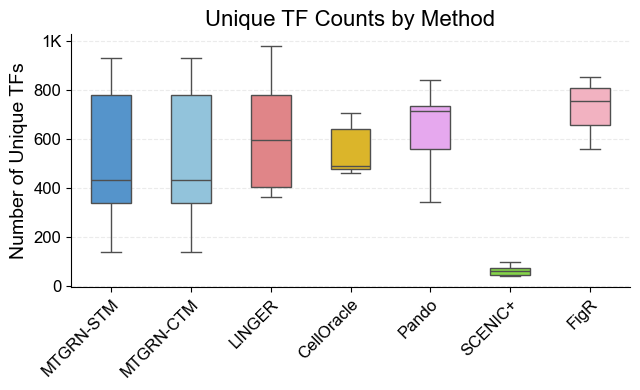

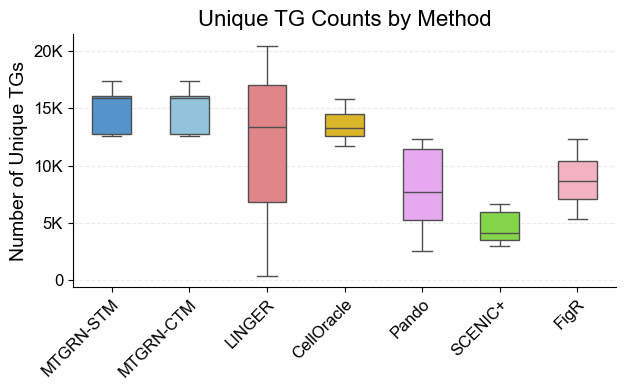

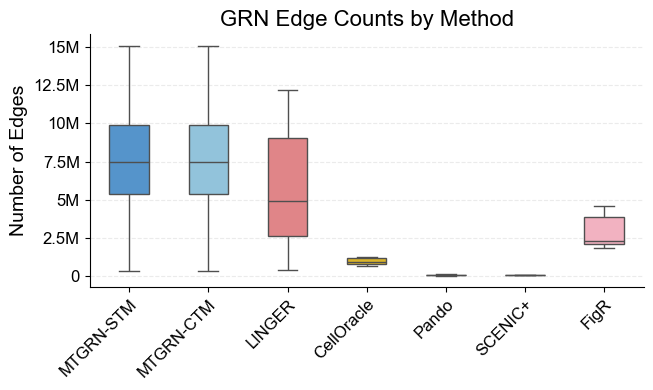

In [38]:
# Plot GRN-size boxplots for AUPRC GRNs
auprc_tf_by_method_boxplot_fig, auprc_tf_by_method_boxplot_ax = (
    plot_grn_size_boxplot(
        summary_df=combined_summary_df,
        method_color_dict=method_color_dict,
        method_rename_map=method_rename_map,
        variable_name="num_unique_tfs",
        title_suffix="",
        figsize=(6.5, 4),
        showfliers=False,
    )
)

auprc_tg_by_method_boxplot_fig, auprc_tg_by_method_boxplot_ax = (
    plot_grn_size_boxplot(
        summary_df=combined_summary_df,
        method_color_dict=method_color_dict,
        method_rename_map=method_rename_map,
        variable_name="num_unique_tgs",
        title_suffix="",
        figsize=(6.5, 4),
        showfliers=False,
    )
)

auprc_edge_by_method_boxplot_fig, auprc_edge_by_method_boxplot_ax = (
    plot_grn_size_boxplot(
        summary_df=combined_summary_df,
        method_color_dict=method_color_dict,
        method_rename_map=method_rename_map,
        variable_name="num_edges",
        title_suffix="",
        figsize=(6.5, 4),
        showfliers=False,
    )
)

# Save AUPRC figures
auprc_tf_by_method_boxplot_fig.savefig(
    grn_sizes_by_method_dir / "num_tfs_by_method_boxplot_auprc.png",
    dpi=300,
    bbox_inches="tight",
)

auprc_tg_by_method_boxplot_fig.savefig(
    grn_sizes_by_method_dir / "num_tgs_by_method_boxplot_auprc.png",
    dpi=300,
    bbox_inches="tight",
)

auprc_edge_by_method_boxplot_fig.savefig(
    grn_sizes_by_method_dir / "num_edges_by_method_boxplot_auprc.png",
    dpi=300,
    bbox_inches="tight",
)

grn_size_boxplots = {
    "auprc": {
        "num_unique_tfs": (
            auprc_tf_by_method_boxplot_fig,
            auprc_tf_by_method_boxplot_ax,
        ),
        "num_unique_tgs": (
            auprc_tg_by_method_boxplot_fig,
            auprc_tg_by_method_boxplot_ax,
        ),
        "num_edges": (
            auprc_edge_by_method_boxplot_fig,
            auprc_edge_by_method_boxplot_ax,
        ),
    },

}

all_figure_axes["grn_size_boxplots"] = grn_size_boxplots

### Network size jitter plots

INFO:root:Ignoring method_color_dict entries not present in the data: ['GRaNIE']


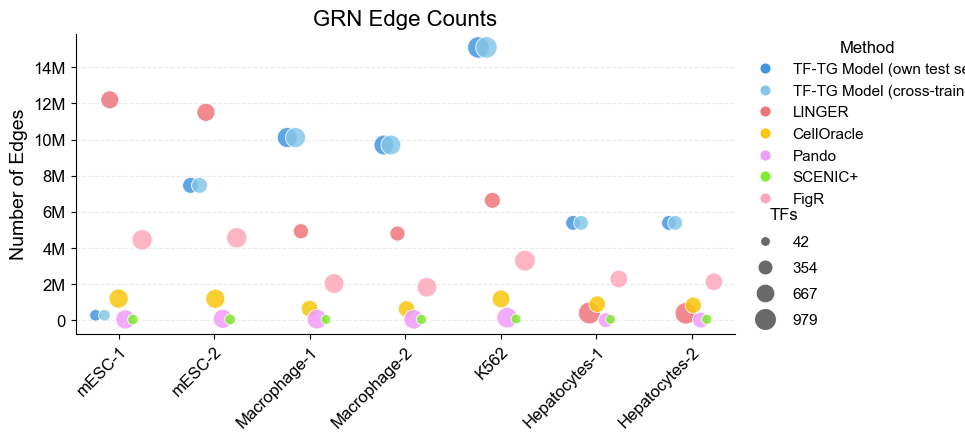

In [39]:
sample_order = list(sample_rename_map.keys())

auprc_edge_jitter_fig, auprc_edge_jitter_ax = plot_grn_size_jitter(
    summary_df=combined_summary_df,
    method_color_dict=method_color_dict,
    variable_name="num_edges",
    sample_col="sample_name",
    point_size_col="num_unique_tfs",
    sample_order=sample_order,
    sample_rename_map=sample_rename_map,
    figsize=(10, 5),
)

#title_suffix="\n(AUPRC GRNs)",

auprc_edge_jitter_fig.savefig(
    grn_sizes_by_method_dir / "num_edges_jitter_auprc.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

# auroc_edge_jitter_fig, auroc_edge_jitter_ax = plot_grn_size_jitter(
#     summary_df=auroc_summary_df,
#     method_color_dict=method_color_dict,
#     variable_name="num_edges",
#     sample_col="sample_name",
#     point_size_col="num_unique_tfs",
#     sample_order=sample_order,
#     sample_rename_map=sample_rename_map,
#     title_suffix="\n(AUROC GRNs)",
#     figsize=(10, 5),
# )

# auroc_edge_jitter_fig.savefig(
#     grn_sizes_by_method_dir / "num_edges_jitter_auroc.png",
#     dpi=300,
#     bbox_inches="tight",
#     facecolor="white",
# )

# plt.show()

all_figure_axes["grn_size_jitter"] = {
    "auprc": (auprc_edge_jitter_fig, auprc_edge_jitter_ax),
    # "auroc": (auroc_edge_jitter_fig, auroc_edge_jitter_ax),
}

### Percent of edge combination box and whisker plots

INFO:root:Ignoring method_color_dict entries not present in the data: ['GRaNIE']


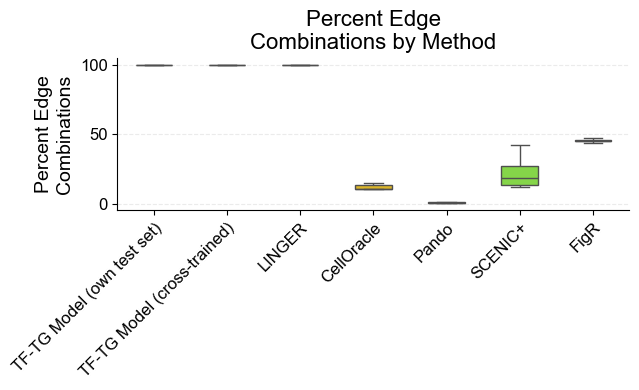

In [40]:
summary_percent_df = add_percent_edges_vs_own(combined_summary_df, percent_col="percent_edge\ncombinations")

percent_edges_boxplot_fig, percent_edges_boxplot_ax = plot_grn_size_boxplot(
    summary_percent_df,
    method_color_dict,
    variable_name="percent_edge\ncombinations",
)

percent_edges_boxplot_fig.savefig(
    grn_sizes_by_method_dir / "percent_edge_combinations_test_set_boxplot.png",
    dpi=300,
    bbox_inches="tight",
)

all_figure_axes["percent_edges_boxplot"] = (percent_edges_boxplot_fig, percent_edges_boxplot_ax)

---

## Scalability

### Scalability Plotting Functions

In [41]:
def plot_scalability_metric(
    summary_df,
    method_color_dict,
    method_rename_map=None,
    variable_name="wall_seconds",
    title_suffix=None,
    figsize=(6.5, 4),
    showfliers=False,
):
    """Plot a boxplot of a GRN summary variable for each method."""
    required_columns = {"method_name", variable_name}
    missing_columns = required_columns.difference(summary_df.columns)
    if missing_columns:
        raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

    label_map = {
        "wall_seconds": "Wall Time (seconds)",
        "wall_minutes": "Wall Time (minutes)",
        "wall_hours": "Wall Time (hours)",
        "user_seconds": "User Time (seconds)",
        "user_hours": "User Time (hours)",
        "cpu_percent": "CPU Usage (%)",
        "max_rss_kb": "Max RSS (KB)",
        "max_rss_gb": "Max RAM (GB)",
    }
    variable_label = label_map.get(
        variable_name,
        variable_name.replace("_", " ").title(),
    )
    
    title_map = {
        "wall_seconds": "Wall Time by Method",
        "wall_minutes": "Wall Time by Method",
        "wall_hours": "Wall Time by Method",
        "user_seconds": "User Time by Method",
        "user_hours": "User Time by Method",
        "cpu_percent": "CPU Usage by Method",
        "max_rss_kb": "Max RAM by Method",
        "max_rss_gb": "Max RAM by Method",
    }
    
    plot_df = summary_df.copy()
    plot_df[variable_name] = pd.to_numeric(
        plot_df[variable_name], errors="coerce"
    )

    rows_before = len(plot_df)
    plot_df = plot_df.dropna(subset=["method_name", variable_name]).copy()
    dropped_rows = rows_before - len(plot_df)
    if dropped_rows:
        logging.warning(
            "Dropped %d row(s) with missing/non-numeric method or %s values.",
            dropped_rows,
            variable_name,
        )

    plot_df, clean_color_dict, method_order = _prepare_method_columns(
        plot_df=plot_df,
        method_color_dict=method_color_dict,
        method_rename_map=method_rename_map,
    )

    if plot_df.empty:
        raise ValueError("No observations remain after method matching.")

    fig, ax = plt.subplots(figsize=figsize)

    sns.boxplot(
        data=plot_df,
        x="method_name_clean",
        y=variable_name,
        hue="method_name_clean",
        order=method_order,
        hue_order=method_order,
        palette=clean_color_dict,
        showfliers=showfliers,
        width=0.5,
        dodge=False,
        ax=ax,
    )

    if ax.get_legend() is not None:
        ax.get_legend().remove()

    ax.tick_params(axis="x", labelrotation=45, labelsize=12)
    for tick_label in ax.get_xticklabels():
        tick_label.set_horizontalalignment("right")
        tick_label.set_rotation_mode("anchor")

    ax.tick_params(axis="y", labelsize=12)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(_format_large_number))
    ax.set_ylabel(variable_label, fontsize=14)
    ax.set_xlabel("")
    
    plot_title = title_map.get(
        variable_name,
        f"{variable_label} by Method",
    )
    ax.set_title(
        _append_title_suffix(plot_title, title_suffix),
        fontsize=16,
    )
    ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()
    return fig, ax


### Data - Load Scalability Results

In [42]:
scalability_summary_file = RESULT_DIR / "scalability" / "scalability_summary.csv"
scalability_df = pd.read_csv(scalability_summary_file, sep=",", header=0, index_col=None)

scalability_df["user_hours"] = scalability_df["user_seconds"] / 3600
scalability_df

,sample_name,cell_type,method_name,status,scope,hardware,source_file,wall_seconds,user_seconds,system_seconds,...,model_load_seconds,gpu_peak_allocated_mb,n_edges,edges_per_second,sample_label,method_label,wall_minutes,wall_hours,max_rss_gb,user_hours
0,E7.5_rep1,mESC,CellOracle,ok,full pipeline,cpu,CellOracle_mESC_E7.5_rep1_task4.time,57736.000,59107.08,275.55,...,NaN,NaN,NaN,NaN,mESC-1,CellOracle,962.266667,16.037778,16.712467,16.418633
1,E7.5_rep1,mESC,FigR,ok,full pipeline,cpu,FigR_mESC_E7.5_rep1_task1.time,25751.000,34933.04,30754.42,...,NaN,NaN,NaN,NaN,mESC-1,FigR,429.183333,7.153056,43.956356,9.703622
2,E7.5_rep1,mESC,LINGER,ok,full pipeline,cpu,LINGER_mESC_E7.5_rep1_task3.time,18611.000,102631.41,348.53,...,NaN,NaN,NaN,NaN,mESC-1,LINGER,310.183333,5.169722,37.639488,28.508725
3,E7.5_rep1,mESC,Pando,ok,full pipeline,cpu,Pando_mESC_E7.5_rep1_task0.time,2766.420,873.79,42.59,...,NaN,NaN,NaN,NaN,mESC-1,Pando,46.107000,0.768450,26.144432,0.242719
4,E7.5_rep1,mESC,SCENIC+,ok,full pipeline,cpu,SCENIC_PLUS_mESC_E7.5_rep1_task2.time,12969.000,61998.92,2323.36,...,NaN,NaN,NaN,NaN,mESC-1,SCENIC+,216.150000,3.602500,62.385780,17.221922
5,E7.5_rep1,mESC,TF-TG Model (cross-trained),ok,inference only,Tesla V100-PCIE-32GB,resource_usage_mESC_E7.5_rep1_all_chroms.tsv,192.772,122.00,90.46,...,0.0,20519.8,281535.0,1460.5,mESC-1,MTGRN-CTM,3.212867,0.053548,17.954730,0.033889
6,E7.5_rep1,mESC,TF-TG Model (own test set),ok,inference only,Tesla V100-PCIE-32GB,resource_usage_mESC_E7.5_rep1_all_chroms.tsv,664.462,351.33,306.95,...,0.0,22298.8,281535.0,423.7,mESC-1,MTGRN-STM,11.074367,0.184573,16.773465,0.097592
7,E8.5_rep1,mESC,CellOracle,ok,full pipeline,cpu,CellOracle_mESC_E8.5_rep1_task9.time,62768.000,63814.31,230.32,...,NaN,NaN,NaN,NaN,mESC-2,CellOracle,1046.133333,17.435556,18.383877,17.726197
8,E8.5_rep1,mESC,FigR,ok,full pipeline,cpu,FigR_mESC_E8.5_rep1_task6.time,26840.000,43537.53,28976.04,...,NaN,NaN,NaN,NaN,mESC-2,FigR,447.333333,7.455556,41.519928,12.093758
9,E8.5_rep1,mESC,LINGER,ok,full pipeline,cpu,LINGER_mESC_E8.5_rep1_task8.time,18331.000,92226.20,360.89,...,NaN,NaN,NaN,NaN,mESC-2,LINGER,305.516667,5.091944,41.920536,25.618389


In [43]:
own_method_grn_size = combined_summary_df[combined_summary_df["method_name"] == OWN_MODEL_METHOD]
own_method_grn_edges = own_method_grn_size[["sample_name", "num_edges"]]

own_method_scalability = scalability_df[scalability_df["method_name"] == OWN_MODEL_METHOD]
own_method_user_seconds = own_method_scalability[["sample_name", "user_seconds"]]

own_method_combined = pd.merge(
    own_method_grn_edges,
    own_method_user_seconds,
    on="sample_name",
    how="inner",
)
own_method_combined["edges_per_second"] = (
    own_method_combined["num_edges"] / own_method_combined["user_seconds"]
)
own_method_combined

,sample_name,num_edges,user_seconds,edges_per_second
0,buffer_2,9696096,4117.17,2355.039020
1,buffer_1,10106964,4519.82,2236.143032
2,sample_1,15092970,6804.23,2218.174577
3,hepatocytes_3,5388744,2648.61,2034.555484
4,hepatocytes_1,5388744,2682.62,2008.761584
5,E7.5_rep1,281535,351.33,801.340620
6,E8.5_rep1,7464370,3181.64,2346.076237


In [44]:
mean_edges_per_second = own_method_combined["edges_per_second"].mean()
print(f"Mean Edges Per Second: {mean_edges_per_second:,.0f}")

Mean Edges Per Second: 2,000


### Scalability Boxplots

INFO:root:Ignoring method_color_dict entries not present in the data: ['GRaNIE']


INFO:root:Ignoring method_color_dict entries not present in the data: ['GRaNIE']
INFO:root:Ignoring method_color_dict entries not present in the data: ['GRaNIE']


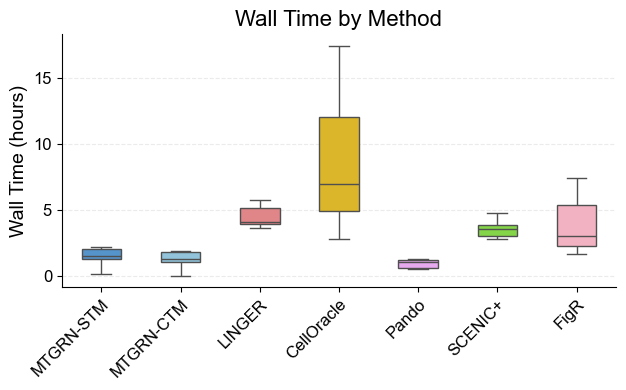

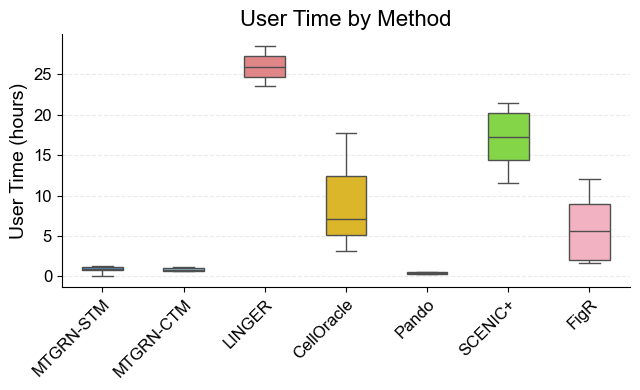

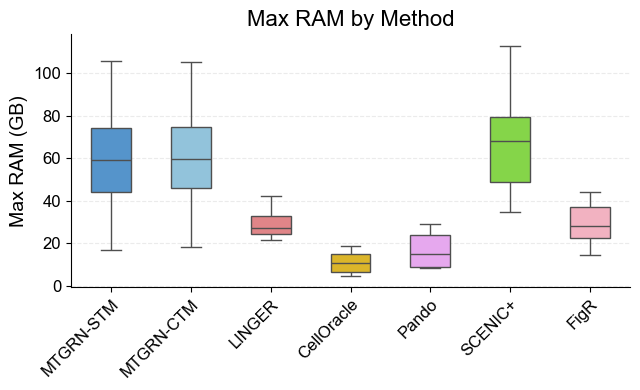

In [45]:

wall_time_boxplot_fig, wall_time_boxplot_ax = plot_scalability_metric(
    summary_df=scalability_df,
    method_color_dict=method_color_dict,
    method_rename_map=method_rename_map,
    variable_name="wall_hours",
    title_suffix=None,
    figsize=(6.5, 4),
    showfliers=False,
)

user_time_boxplot_fig, user_time_boxplot_ax = plot_scalability_metric(
    summary_df=scalability_df,
    method_color_dict=method_color_dict,
    method_rename_map=method_rename_map,
    variable_name="user_hours",
    title_suffix=None,
    figsize=(6.5, 4),
    showfliers=False,
)

max_rss_gb_boxplot_fig, max_rss_gb_boxplot_ax = plot_scalability_metric(
    summary_df=scalability_df,
    method_color_dict=method_color_dict,
    method_rename_map=method_rename_map,
    variable_name="max_rss_gb",
    title_suffix=None,
    figsize=(6.5, 4),
    showfliers=False,
)

wall_time_boxplot_fig.savefig(
    scalability_plot_dir / "wall_time_boxplot.png",
    dpi=300,
    bbox_inches="tight",
)

user_time_boxplot_fig.savefig(
    scalability_plot_dir / "user_time_boxplot.png",
    dpi=300,
    bbox_inches="tight",
)

max_rss_gb_boxplot_fig.savefig(
    scalability_plot_dir / "max_ram_gb_boxplot.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show(wall_time_boxplot_fig)
plt.show(user_time_boxplot_fig)
plt.show(max_rss_gb_boxplot_fig)

---

## Stability

In [46]:
method_rename_map = {
    "TF-TG Model (own test set)": "MTGRN-STM",
    "TF-TG Model (cross-trained)": "MTGRN-CTM",
    "LINGER": "LINGER",
    "SCENIC_PLUS": "SCENIC+",
    "CellOracle": "CellOracle",
    "FigR": "FigR",
}

### Stability Functions

In [47]:
import re
import zlib

def generate_randomized_df(df, sample_name, subsample_num):
    random_df = df.copy()
    seed = zlib.crc32(f"{sample_name}_{subsample_num}".encode())  # stable across processes
    rng = np.random.default_rng(seed)
    random_df["Score"] = rng.permutation(random_df["Score"].to_numpy())
    return random_df

def calculate_jaccard_index(df_x, df_y, top_pct=0.1, restrict_to_common=True):
    """Top-`top_pct` Jaccard. With restrict_to_common, both GRNs are cut down to the
    edges they share before ranking, so the result measures ranking disagreement
    rather than differences in which edges were scored at all."""
    def keyed(df):
        d = df.drop_duplicates(["Source", "Target"]).copy()
        d["_key"] = list(zip(d["Source"].str.upper(), d["Target"].str.upper()))
        return d

    dx, dy = keyed(df_x), keyed(df_y)

    if restrict_to_common:
        common = set(dx["_key"]) & set(dy["_key"])
        dx = dx[dx["_key"].isin(common)]
        dy = dy[dy["_key"].isin(common)]
        k = int(top_pct * len(common))
    else:
        k = None

    # deterministic tie-breaking
    dx = dx.sort_values(["Score", "Source", "Target"], ascending=[False, True, True])
    dy = dy.sort_values(["Score", "Source", "Target"], ascending=[False, True, True])

    kx = k if k is not None else int(top_pct * len(dx))
    ky = k if k is not None else int(top_pct * len(dy))
    if kx == 0 or ky == 0:
        return np.nan  # don't silently report 0.0

    a, b = set(dx.head(kx)["_key"]), set(dy.head(ky)["_key"])
    return len(a & b) / len(a | b) if (a | b) else np.nan


_STABILITY_GRN_PATTERN = re.compile(
    r"^(?P<model>.+?)_model_vs_(?P<test>.+?)_test_grn_(?P<subset>.+?)_stability_(?P<num>\d+)\.csv$"
)


def load_tether_stability_labeled_grns(tether_stability_grn_dir, models_to_plot):
    """
    Load the stability GRNs written by generate_stability_test_set_grns.py.

    Files are named:
        {model_sample}_model_vs_{test_sample}_test_grn_{subset}_stability_{N}.csv

    Returns two dicts, keeping self-trained and cross-trained runs separate:
      - own_stability_dfs[test_sample][subsample_num]                    (model_sample == test_sample)
      - cross_stability_dfs[(model_sample, test_sample)][subsample_num]  (model_sample != test_sample)
    """
    own_stability_dfs = {}
    cross_stability_dfs = {}

    if not tether_stability_grn_dir.exists():
        logging.warning(f"Stability GRN directory does not exist: {tether_stability_grn_dir}")
        return own_stability_dfs, cross_stability_dfs

    for prediction_save_file in sorted(tether_stability_grn_dir.glob("*_model_vs_*_test_grn_*_stability_*.csv")):
        match = _STABILITY_GRN_PATTERN.match(prediction_save_file.name)
        if match is None:
            logging.debug(f"Skipping unrecognized stability GRN file: {prediction_save_file.name}")
            continue

        model_sample = match.group("model")
        test_sample = match.group("test")
        subsample_num = int(match.group("num"))

        # Only keep the samples we're plotting
        if model_sample not in models_to_plot or test_sample not in models_to_plot:
            continue

        labeled_score_df = pd.read_csv(prediction_save_file)

        if model_sample == test_sample:
            own_stability_dfs.setdefault(test_sample, {})[subsample_num] = labeled_score_df
        else:
            cross_stability_dfs.setdefault((model_sample, test_sample), {})[subsample_num] = labeled_score_df

    return own_stability_dfs, cross_stability_dfs


def calculate_tether_jaccard_indices(stability_labeled_score_dfs, method_name):
    # Calculate the pairwise Jaccard indices for the top 10% of edges across subsamples.
    # `stability_labeled_score_dfs` maps a group key -> {subsample_num: df}, where the key is
    # a sample_name string (own-model runs) or a (model_sample, test_sample) tuple
    # (cross-trained runs). Every row is tagged with `method_name` so the own and
    # cross-trained results stay separate metrics.
    jaccard_plot_data = []
    for group_key, score_by_subsample in stability_labeled_score_dfs.items():
        if isinstance(group_key, tuple):
            model_sample, test_sample = group_key
            seed_name = f"{model_sample}|{test_sample}"
        else:
            model_sample = test_sample = group_key
            seed_name = group_key

        available_subsamples = sorted(score_by_subsample.keys())

        for i, subsample_num_x in enumerate(available_subsamples):
            for subsample_num_y in available_subsamples[i + 1:]:
                df_x = score_by_subsample[subsample_num_x]
                df_y = score_by_subsample[subsample_num_y]

                random_df_x = generate_randomized_df(df_x, seed_name, subsample_num_x)
                random_df_y = generate_randomized_df(df_y, seed_name, subsample_num_y)

                jaccard_index = calculate_jaccard_index(df_x, df_y)
                random_jaccard_index = calculate_jaccard_index(random_df_x, random_df_y)

                # Ceiling for jaccard_index. 1.0 means both subsamples scored the same
                # edges, so the top-10% disagreement is ranking instability alone.
                universe_jaccard = stat_utils.calculate_universe_jaccard(df_x, df_y)

                jaccard_plot_data.append({
                    "method_name": method_name,
                    "sample_name": test_sample,
                    "subsample_pair": f"{subsample_num_x}-{subsample_num_y}",
                    "jaccard_index": jaccard_index,
                    "random_jaccard_index": random_jaccard_index,
                    "universe_jaccard": universe_jaccard
                })

    tether_jaccard_plot_df = pd.DataFrame(jaccard_plot_data)

    return tether_jaccard_plot_df


def load_other_method_stability_score_dfs(other_method_stability_grn_dir, models_to_plot, org_dict):
    def _label_df(df, gt_tfs, gt_tgs, gt_pairs):
        df = df.copy()
        
        df = df[
            (df["Source"].str.upper().isin(gt_tfs)) &
            (df["Target"].str.upper().isin(gt_tgs))
            ]
        
        df["_in_gt"] = (
            (df["Source"].str.upper() + "\t" + df["Target"].str.upper()).isin(gt_pairs)
        )
        return df

    ground_truth_by_celltype = {}
    
    other_method_stability_score_dfs = {}
    for method_name_dir in other_method_stability_grn_dir.iterdir():
        if method_name_dir.is_dir():
            method_name = method_name_dir.name
            
            if method_name == ".staging":
                logging.debug(f"Skipping staging directory: {method_name_dir}")
                continue
            
            logging.info(f"Processing stability GRNs for method: {method_name}")
            
            other_method_stability_score_dfs[method_name] = {}
            
            for sample_name in models_to_plot:
                logging.info(f"  - Sample: {sample_name}")
                n_subsamples = 0
                cell_type = org_dict[sample_name][1]
                
                sample_dir = method_name_dir / f"{cell_type}/{sample_name}"
                
                # Load the merged ground truth for this celltype unless it has already been loaded
                if cell_type not in ground_truth_by_celltype:
                    cell_type_cache_dir = DATA_DIR / f"{cell_type}_cache"
                    merged_ground_truth_df = pd.read_parquet(cell_type_cache_dir / f"{cell_type}_merged_ground_truth.parquet")
                    
                    ground_truth_by_celltype[cell_type] = merged_ground_truth_df
                else:
                    merged_ground_truth_df = ground_truth_by_celltype[cell_type]

                gt_tfs = set(merged_ground_truth_df["Source"].str.upper().unique())
                gt_tgs = set(merged_ground_truth_df["Target"].str.upper().unique())
                gt_pairs = (merged_ground_truth_df["Source"].str.upper() + "\t" + merged_ground_truth_df["Target"].str.upper()).drop_duplicates()
                    
                if sample_dir.exists() and sample_dir.is_dir():
                    
                    other_method_stability_score_dfs[method_name][sample_name] = {}
                    for subsample_num in range(0, 10):
                        prediction_save_file = sample_dir / f"subsample_{subsample_num}.tsv"
                        
                        if prediction_save_file.exists():
                            labeled_score_df = _label_df(pd.read_csv(prediction_save_file, sep="\t"), gt_tfs, gt_tgs, gt_pairs)
                            other_method_stability_score_dfs[method_name][sample_name][subsample_num] = labeled_score_df
                            
                            n_subsamples += 1
                        else:
                            logging.debug(f"Missing prediction file: {prediction_save_file}")
                logging.info(f"    - Num Subsamples: {n_subsamples}")
            
    return other_method_stability_score_dfs


def calculate_other_method_jaccard_indices(other_method_stability_score_dfs):
    other_method_jaccard_indices = {}
    for method_name, subsample_dict in other_method_stability_score_dfs.items():
        other_method_jaccard_indices[method_name] = {}

        for sample_name, score_by_subsample in subsample_dict.items():
            other_method_jaccard_indices[method_name][sample_name] = []
            available_subsamples = sorted(score_by_subsample.keys())

            for i, subsample_num_x in enumerate(available_subsamples):
                for subsample_num_y in available_subsamples[i + 1:]:
                    if subsample_num_x != subsample_num_y:
                        df_x = score_by_subsample[subsample_num_x]
                        df_y = score_by_subsample[subsample_num_y]
                        
                        random_df_x = generate_randomized_df(df_x, sample_name, subsample_num_x)
                        random_df_y = generate_randomized_df(df_y, sample_name, subsample_num_y)
                        
                        jaccard_index = calculate_jaccard_index(df_x, df_y)
                        random_jaccard_index = calculate_jaccard_index(random_df_x, random_df_y)
                        universe_jaccard = stat_utils.calculate_universe_jaccard(df_x, df_y)
                        
                        other_method_jaccard_indices[method_name][sample_name].append((subsample_num_x, subsample_num_y, jaccard_index, random_jaccard_index, universe_jaccard))
    
    other_method_jaccard_plot_data = []
    for method_name, sample_dict in other_method_jaccard_indices.items():
        for sample_name, jaccard_list in sample_dict.items():
            for subsample_num_x, subsample_num_y, jaccard_index, random_jaccard_index, universe_jaccard in jaccard_list:
                other_method_jaccard_plot_data.append({
                    "method_name": method_name,
                    "sample_name": sample_name,
                    "subsample_pair": f"{subsample_num_x}-{subsample_num_y}",
                    "jaccard_index": jaccard_index,
                    "random_jaccard_index": random_jaccard_index,
                    "universe_jaccard": universe_jaccard
                })

    other_method_jaccard_plot_df = pd.DataFrame(other_method_jaccard_plot_data)
        
    return other_method_jaccard_plot_df


### Stability Plotting Functions

In [48]:
def plot_method_stability_by_sample_boxplot(
    jaccard_plot_df,
    sample_order,
    sample_rename_map,
    methods=(OWN_MODEL_METHOD, CROSS_MODEL_METHOD),
):
    # Show the self-trained (own test set) and cross-trained TF-TG models
    # side-by-side within each sample.
    plot_df = jaccard_plot_df[jaccard_plot_df["method_name"].isin(methods)].copy()

    present = [s for s in sample_order if s in set(plot_df["sample_name"])]
    method_order = [m for m in methods if m in set(plot_df["method_name"])]
    palette = {m: method_color_dict.get(m) for m in method_order}

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_title("Stability", fontsize=16)
    sns.boxplot(
        data=plot_df,
        x="sample_name",
        y="jaccard_index",
        hue="method_name",
        order=present,
        hue_order=method_order,
        palette=palette,
        showfliers=False,
        ax=ax,
    )

    ax.set_xticks(range(len(present)))
    ax.set_xticklabels(
        [sample_rename_map.get(s, s) for s in present],
        rotation=45, ha="right", fontsize=12,
    )

    ax.tick_params(axis="y", labelsize=12)
    ax.set_ylabel("Pairwise Jaccard Index\n(Top 10% Edges, 10 subsamples)", fontsize=14)
    ax.set_xlabel("")
    ax.set_ylim(0, 1)

    # Rename the legend entries (e.g. MTGRN-STM / MTGRN-CTM)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles,
        [method_rename_map.get(l, l) for l in labels],
        title="",
        fontsize=11,
        frameon=False,
        loc="upper right",
    )

    return fig, ax


def plot_method_stability_boxplot(jaccard_plot_df, method_rename_map):
    fig, ax = plt.subplots(figsize=(5, 4))

    medians = (
        jaccard_plot_df.groupby("method_name")["jaccard_index"]
        .median()
        .sort_values(ascending=False)
    )
    median_order = medians.index

    sns.boxplot(
        data=jaccard_plot_df,
        x="method_name",
        y="jaccard_index",
        showfliers=False,
        hue="method_name",
        order=median_order,
        hue_order=median_order,
        ax=ax,
        legend=False,
    )

    ax.set_title("Stability", fontsize=16)
    ax.set_xticklabels(
        [method_rename_map.get(m, m) for m in median_order],
        rotation=45, ha="right", fontsize=12,
    )
    ax.tick_params(axis="y", labelsize=12)
    ax.set_ylabel("Pairwise Jaccard Index\n(Top 10% Edges, 10 subsamples)", fontsize=14)
    ax.set_xlabel("")
    ax.set_ylim(0, 1)

    # Pull the actual box colors seaborn used, so the legend matches exactly
    palette = sns.color_palette(n_colors=len(median_order))
    handles = [
        mpatches.Patch(
            color=palette[i],
            label=f"{method_rename_map.get(m, m)} = {medians[m]:.3f}",
        )
        for i, m in enumerate(median_order)
    ]

    ax.legend(
        handles=handles,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=11,
        title="Median Jaccard",
        title_fontsize=12,
        frameon=False,
    )

    return fig, ax
    

def plot_method_stability_heatmap(jaccard_plot_df, sample_rename_map):
    med_df = (
        jaccard_plot_df
        .groupby(["method_name", "sample_name"])
        .median("jaccard_index")
        .reset_index()
    )

    # Long -> two value types (stability + random) stacked per sample
    stab = med_df[["method_name", "sample_name", "jaccard_index"]].copy()
    stab["kind"] = "Stability"
    stab = stab.rename(columns={"jaccard_index": "value"})

    rand = med_df[["method_name", "sample_name", "random_jaccard_index"]].copy()
    rand["kind"] = "Random"
    rand = rand.rename(columns={"random_jaccard_index": "value"})

    long_df = pd.concat([stab, rand], ignore_index=True)

    # Build a (sample, kind) row index with Stability on top, Random below, per sample
    long_df["row"] = list(zip(long_df["sample_name"], long_df["kind"]))

    heat = long_df.pivot_table(
        index="row",
        columns="method_name",
        values="value",
        aggfunc="median",
    )

    # Order rows: group by sample, Stability then Random within each
    sample_order = sorted(med_df["sample_name"].unique())
    row_order = [(s, k) for s in sample_order for k in ("Stability", "Random")]
    row_order = [r for r in row_order if r in heat.index]
    heat = heat.reindex(row_order)

    # Optional: order methods however you like
    heat = heat.reindex(sorted(heat.columns), axis=1)

    fig, ax = plt.subplots(figsize=(1.1 * heat.shape[1] + 3, 0.4 * heat.shape[0] + 2))
    sns.heatmap(
        heat,
        annot=True,
        fmt=".2f",
        cmap="viridis_r",
        annot_kws={"fontsize": 16},
        vmin=0,
        vmax=1,
        square=False,
        cbar_kws={"label": "Median Pairwise Jaccard Index"},
        ax=ax,
    )

    ax.set_yticklabels(
        [f"{sample_rename_map[s]}-{k}" for (s, k) in heat.index],
        rotation=0, fontsize=14,
    )
    
    ax.set_xticklabels(
        [method_rename_map.get(m, m) for m in heat.columns],
        rotation=45, ha="right", fontsize=12,
    )

    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title("Stability", fontsize=22)

    plt.tight_layout()
    
    return fig, ax

### Data - Load Stability and Calculate JI

In [49]:
force_reload = False   # recompute the Jaccard indices from parsed data (Tier-2 cache)
force_reparse = False  # re-parse + re-label the raw subsample GRNs (Tier-1 cache; slow)

stability_results_dir = RESULT_DIR / "stability_results"
stability_results_dir.mkdir(parents=True, exist_ok=True)

tether_stability_grn_dir = stability_results_dir / "stability_grns"
parsed_cache_path = stability_results_dir / "parsed_stability_score_dfs.pkl"
jaccard_plot_save_path = stability_results_dir / "stability_jaccard_indices_by_method.csv"


def load_parsed_stability_score_dfs(force_reparse=False):
    """Tier-1 cache: parse + ground-truth-label the raw subsample GRNs once.

    Reading the per-subsample TSV/CSV files and filtering them against the ground
    truth is the slow step, so the parsed structures are pickled and reused.
    Returns (own_stability_dfs, cross_stability_dfs, other_method_stability_score_dfs).
    """
    if parsed_cache_path.exists() and not force_reparse:
        logging.info(f"Loading cached parsed stability score dfs from {parsed_cache_path}")
        cached = pd.read_pickle(parsed_cache_path)
        return cached["own"], cached["cross"], cached["other"]

    logging.info("Parsing raw stability subsample GRNs (this can take a while)...")
    own_stability_dfs, cross_stability_dfs = load_tether_stability_labeled_grns(
        tether_stability_grn_dir, models_to_plot
    )
    other_method_stability_score_dfs = load_other_method_stability_score_dfs(
        other_method_stability_grn_dir, models_to_plot, org_dict
    )

    pd.to_pickle(
        {
            "own": own_stability_dfs,
            "cross": cross_stability_dfs,
            "other": other_method_stability_score_dfs,
        },
        parsed_cache_path,
    )
    return own_stability_dfs, cross_stability_dfs, other_method_stability_score_dfs


if jaccard_plot_save_path.exists() and not force_reload and not force_reparse:
    # Tier-2 cache hit: the small Jaccard table is all the plots need
    jaccard_plot_df = pd.read_csv(jaccard_plot_save_path)
else:
    # Parse (or reuse the parsed) subsample GRNs, then compute Jaccard indices
    own_stability_dfs, cross_stability_dfs, other_method_stability_score_dfs = load_parsed_stability_score_dfs(force_reparse)

    own_jaccard_plot_df = calculate_tether_jaccard_indices(own_stability_dfs, OWN_MODEL_METHOD)
    cross_jaccard_plot_df = calculate_tether_jaccard_indices(cross_stability_dfs, CROSS_MODEL_METHOD)
    other_method_jaccard_plot_df = calculate_other_method_jaccard_indices(other_method_stability_score_dfs)

    jaccard_plot_df = pd.concat(
        [own_jaccard_plot_df, cross_jaccard_plot_df, other_method_jaccard_plot_df],
        ignore_index=True,
    )

    # Edge-universe ceiling check. Any group below 1.0 has subsamples that scored
    # partly different edge sets, so its top-10% Jaccard is deflated by universe
    # drift rather than by model instability alone.
    universe_summary_rows = (
        [stat_utils.summarize_universe_overlap(dfs, OWN_MODEL_METHOD, sample_name=key)
         for key, dfs in own_stability_dfs.items()]
        + [stat_utils.summarize_universe_overlap(dfs, CROSS_MODEL_METHOD, sample_name=key[1])
           for key, dfs in cross_stability_dfs.items()]
        + [stat_utils.summarize_universe_overlap(dfs, other_method_name, sample_name=other_sample_name)
           for other_method_name, dfs_by_sample in other_method_stability_score_dfs.items()
           for other_sample_name, dfs in dfs_by_sample.items()]
    )
    universe_summary_df = pd.DataFrame([row for row in universe_summary_rows if row is not None])
    universe_summary_df.to_csv(stability_results_dir / "stability_universe_overlap.csv", index=False)

    confounded_df = universe_summary_df[universe_summary_df["mean_universe_jaccard"] < 1.0]
    if not confounded_df.empty:
        logging.warning(
            "Subsamples scored different edge sets for these groups, so their Jaccard "
            f"index is capped below what ranking stability alone would give:\n{confounded_df.to_string(index=False)}"
        )

    # Save the Jaccard indices to a CSV file
    jaccard_plot_df.to_csv(jaccard_plot_save_path, index=False)

# Defined on both the cache-hit and recompute paths so downstream cells always work.
tether_jaccard_plot_df = jaccard_plot_df[
    jaccard_plot_df["method_name"].isin([OWN_MODEL_METHOD, CROSS_MODEL_METHOD])
].copy()

# Median Jaccard index for each method and sample combination
median_jaccard_plot_df = (
    jaccard_plot_df.groupby(["method_name", "sample_name"])
    .median(numeric_only=True)
    .reset_index()
    .sort_values(by=["method_name", "sample_name"])
)

In [50]:
tether_jaccard_plot_df.groupby("sample_name")["jaccard_index"].median().sort_values(ascending=False)

sample_name
sample_1         0.517254
hepatocytes_3    0.488256
hepatocytes_1    0.423300
buffer_2         0.395254
E7.5_rep1        0.365567
buffer_1         0.321531
E8.5_rep1        0.315916
Name: jaccard_index, dtype: float64

In [51]:
tether_jaccard_plot_df

,method_name,sample_name,subsample_pair,jaccard_index,random_jaccard_index,universe_jaccard
0,TF-TG Model (own test set),E7.5_rep1,0-1,0.509847,0.052632,1.0
1,TF-TG Model (own test set),E7.5_rep1,0-2,0.490281,0.060723,1.0
2,TF-TG Model (own test set),E7.5_rep1,0-3,0.469649,0.045455,1.0
3,TF-TG Model (own test set),E7.5_rep1,0-4,0.498371,0.051829,1.0
4,TF-TG Model (own test set),E7.5_rep1,0-5,0.514819,0.056662,1.0
...,...,...,...,...,...,...
625,TF-TG Model (cross-trained),buffer_2,6-8,0.385576,0.061073,1.0
626,TF-TG Model (cross-trained),buffer_2,6-9,0.422064,0.049921,1.0
627,TF-TG Model (cross-trained),buffer_2,7-8,0.376033,0.046621,1.0
628,TF-TG Model (cross-trained),buffer_2,7-9,0.360109,0.059385,1.0


### TETHER Stability by Sample

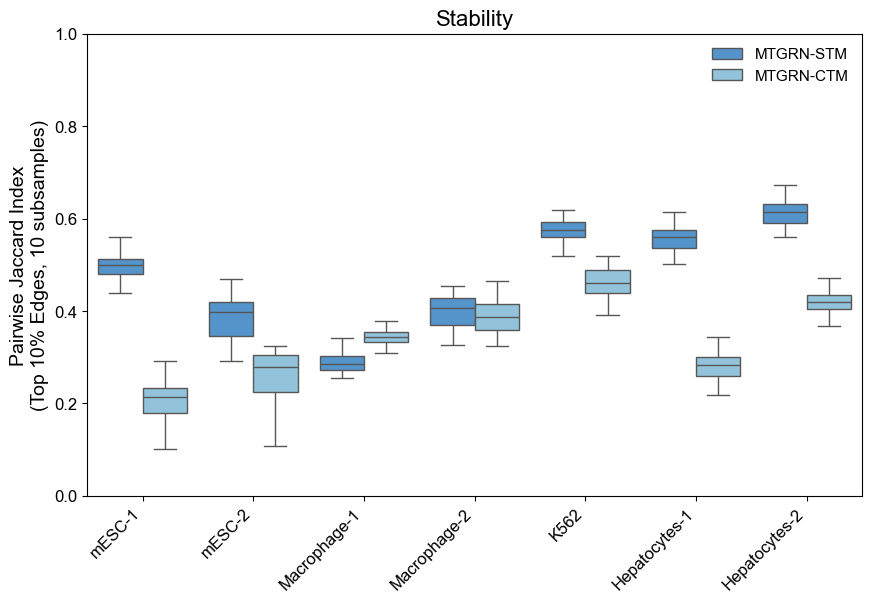

In [52]:
stability_boxplot_fig, stability_boxplot_ax = plot_method_stability_by_sample_boxplot(tether_jaccard_plot_df, sample_order, sample_rename_map)
stability_boxplot_fig.show()

stability_boxplot_fig.savefig(
    stability_plot_dir / "stability_by_sample_tether_boxplot.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

all_figure_axes["tether_stability_boxplot"] = (stability_boxplot_fig, stability_boxplot_ax)

### Stability by Inference Method - Boxplots

/tmp/ipykernel_183334/2812027131.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


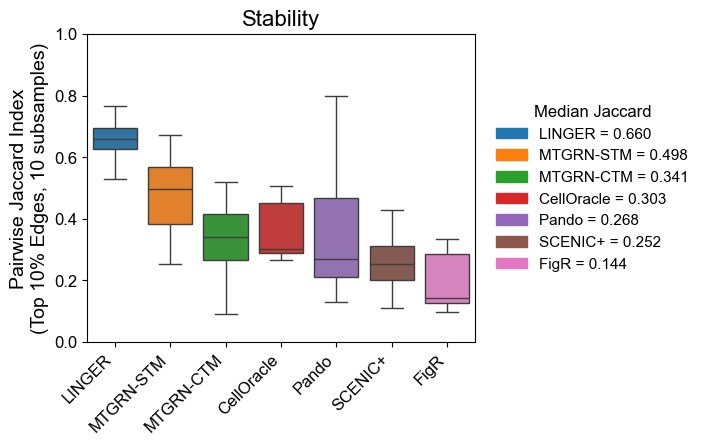

In [53]:
stability_method_boxplot_fig, stability_method_boxplot_ax = plot_method_stability_boxplot(jaccard_plot_df, method_rename_map)
stability_method_boxplot_fig.show()

stability_method_boxplot_fig.savefig(
    stability_plot_dir / "stability_by_method_boxplot.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

all_figure_axes["stability_by_method_boxplot"] = (stability_method_boxplot_fig, stability_method_boxplot_ax)

### Stability by Inference Method - Heatmap

In [54]:
jaccard_plot_df.groupby("method_name")["jaccard_index"].median().sort_values(ascending=False)


method_name
LINGER                         0.660046
TF-TG Model (own test set)     0.498371
TF-TG Model (cross-trained)    0.340603
CellOracle                     0.303001
Pando                          0.268293
SCENIC_PLUS                    0.252162
FigR                           0.143810
Name: jaccard_index, dtype: float64

In [55]:
jaccard_plot_df.groupby(["method_name", "sample_name"])["jaccard_index"].count().sort_values(ascending=False).reset_index()

,method_name,sample_name,jaccard_index
0,CellOracle,E7.5_rep1,45
1,CellOracle,E8.5_rep1,45
2,CellOracle,buffer_1,45
3,CellOracle,buffer_2,45
4,CellOracle,hepatocytes_1,45
5,CellOracle,hepatocytes_3,45
6,CellOracle,sample_1,45
7,FigR,E7.5_rep1,45
8,FigR,E8.5_rep1,45
9,FigR,buffer_1,45


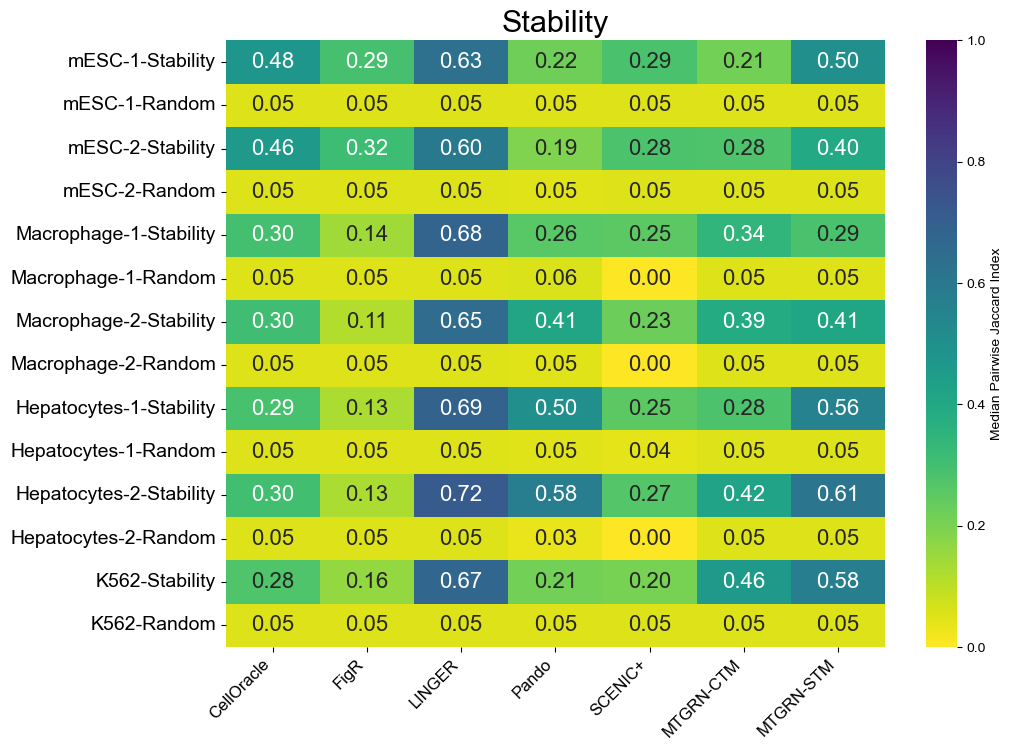

In [56]:
stability_method_heatmap_fig, stability_method_heatmap_ax = plot_method_stability_heatmap(
    jaccard_plot_df, 
    sample_rename_map
    )    
    
stability_method_heatmap_fig.savefig(
    stability_plot_dir / "stability_by_method_heatmap.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
    
all_figure_axes["stability_by_method_heatmap"] = (stability_method_heatmap_fig, stability_method_heatmap_ax)
    
stability_method_heatmap_fig.show()

---

## Recovery of Regulatory Programs

Test to see if the top TGs for a TF are enriched in known pathways that are associated with that TF.

In [57]:
import gseapy as gp

from statsmodels.stats.multitest import multipletests

# Define biological programs
process_definitions = {
    "E7.5": {
        "Neural plate and head process formation": {
            "tfs": [
                "SOX2",
                "OTX2",
                "ZIC2",
                "ZIC3",
                "LHX1",
            ],
            "go_terms": [
                "Neural Plate Formation (GO:0021990)",
                "Neural Plate Morphogenesis (GO:0001839)",
            ],
        },

        "Axial mesendoderm and notochordal plate formation": {
            "tfs": [
                "T",
                "EOMES",
                "FOXA2",
                "LHX1",
                "GSC",
            ],
            "go_terms": [
                "Notochord Formation (GO:0014028)",
                "Notochord Morphogenesis (GO:0048570)",
            ],
        },

        "Foregut pocket initiation": {
            "tfs": [
                "FOXA2",
                "SOX17",
                "GATA4",
                "GATA6",
                "HHEX",
            ],
            "go_terms": [
                "Embryonic Foregut Morphogenesis (GO:0048617)",
                "Foregut Morphogenesis (GO:0007440)",
            ],
        },

        "Cardiac progenitor convergence and linear heart tube formation": {
            "tfs": [
                "NKX2-5",
                "GATA4",
                "MEF2C",
                "TBX5",
                "HAND1",
                "ISL1",
            ],
            "go_terms": [
                "Embryonic Heart Tube Development (GO:0035050)",
                "Heart Rudiment Development (GO:0003313)",
            ],
        },

        "Allantoic bud elongation": {
            "tfs": [
                "T",
                "TBX4",
            ],
            "go_terms": [
                "Allantois Development (GO:1905069)",
            ],
        },

        "Primitive hematopoiesis and yolk-sac vasculogenesis": {
            "tfs": [
                "TAL1",
                "ETV2",
                "GATA1",
                "GATA2",
                "FLI1",
            ],
            "go_terms": [
                "Primitive Hemopoiesis (GO:0060215)",
                "Vasculogenesis (GO:0001570)",
            ],
        },
    },

    "E7.75": {
        "Head-fold and neural-fold morphogenesis": {
            "tfs": [
                "SOX2",
                "OTX2",
                "ZIC2",
                "ZIC3",
                "PAX3",
            ],
            "go_terms": [
                "Neural Plate Morphogenesis (GO:0001839)",
                "Neural Plate Formation (GO:0021990)",
            ],
        },

        "Heart tube assembly and midline fusion": {
            "tfs": [
                "NKX2-5",
                "GATA4",
                "MEF2C",
                "TBX5",
                "HAND1",
                "ISL1",
            ],
            "go_terms": [
                "Embryonic Heart Tube Development (GO:0035050)",
                "Heart Rudiment Development (GO:0003313)",
            ],
        },

        "Presomitic mesoderm segmentation and onset of somitogenesis": {
            "tfs": [
                "TBX6",
                "MSGN1",
                "HES7",
                "MESP2",
            ],
            "go_terms": [
                "Regulation Of Somitogenesis (GO:0014807)",
                "Somitogenesis (GO:0001756)",
            ],
        },

        "Foregut invagination and anterior endoderm morphogenesis": {
            "tfs": [
                "FOXA2",
                "SOX17",
                "GATA4",
                "HHEX",
                "LHX1",
            ],
            "go_terms": [
                "Embryonic Foregut Morphogenesis (GO:0048617)",
                "Foregut Morphogenesis (GO:0007440)",
            ],
        },

        "Allantois extension and extraembryonic vascular maturation": {
            "tfs": [
                "T",
                "TBX4",
                "ETV2",
                "FLI1",
            ],
            "go_terms": [
                "Allantois Development (GO:1905069)",
                "Vasculogenesis (GO:0001570)",
            ],
        },
    },

    "E8.0": {
        "First somite formation": {
            "tfs": [
                "TBX6",
                "MSGN1",
                "HES7",
                "MESP2",
            ],
            "go_terms": [
                "Somitogenesis (GO:0001756)",
                "Somite Development (GO:0061053)",
            ],
        },

        "Initiation of neural tube closure": {
            "tfs": [
                "PAX3",
                "ZIC2",
                "ZIC3",
                "GRHL2",
                "SOX2",
            ],
            "go_terms": [
                "Initiation Of Neural Tube Closure (GO:0021993)",
                "Neural Tube Closure (GO:0001843)",
            ],
        },

        "Heart rudiment and early heart tube maturation": {
            "tfs": [
                "NKX2-5",
                "GATA4",
                "MEF2C",
                "TBX5",
                "HAND1",
                "HAND2",
                "ISL1",
            ],
            "go_terms": [
                "Heart Rudiment Development (GO:0003313)",
                "Embryonic Heart Tube Development (GO:0035050)",
            ],
        },

        "First pharyngeal arch morphogenesis": {
            "tfs": [
                "TBX1",
                "TFAP2A",
                "DLX5",
                "DLX6",
                "HAND2",
            ],
            "go_terms": [
                "Pharyngeal System Development (GO:0060037)",
            ],
        },

        "Eye field and optic primordium formation": {
            "tfs": [
                "RAX",
                "SIX3",
                "PAX6",
                "LHX2",
                "OTX2",
            ],
            "go_terms": [
                "Embryonic Camera-Type Eye Formation (GO:0060900)",
            ],
        },
    },

    "E8.5": {
        "Heart looping and cardiac regionalization": {
            "tfs": [
                "NKX2-5",
                "GATA4",
                "HAND1",
                "HAND2",
                "TBX20",
                "PITX2",
                "ISL1",
            ],
            "go_terms": [
                "Heart Looping (GO:0001947)",
                "Embryonic Heart Tube Morphogenesis (GO:0003143)",
            ],
        },

        "Progressive neural tube closure": {
            "tfs": [
                "PAX3",
                "ZIC2",
                "ZIC3",
                "GRHL2",
                "NR6A1",
            ],
            "go_terms": [
                "Neural Tube Closure (GO:0001843)",
            ],
        },

        "Otic placode formation": {
            "tfs": [
                "PAX2",
                "PAX8",
                "GATA3",
                "SOX2",
                "SIX1",
            ],
            "go_terms": [
                "Otic Placode Formation (GO:0043049)",
            ],
        },

        "Neural crest specification and early cranial migration": {
            "tfs": [
                "PAX3",
                "TFAP2A",
                "FOXD3",
                "SOX9",
                "SOX10",
                "NR6A1",
            ],
            "go_terms": [
                "Neural Crest Formation (GO:0014029)",
                "Neural Crest Cell Migration (GO:0001755)",
            ],
        },

        "Second pharyngeal arch emergence and patterning": {
            "tfs": [
                "TBX1",
                "TFAP2A",
                "HOXA2",
                "DLX5",
                "DLX6",
                "HAND2",
            ],
            "go_terms": [
                "Pharyngeal System Development (GO:0060037)",
            ],
        },

        "Continued somitogenesis": {
            "tfs": [
                "TBX6",
                "MSGN1",
                "HES7",
                "MESP2",
            ],
            "go_terms": [
                "Somitogenesis (GO:0001756)",
                "Somite Development (GO:0061053)",
            ],
        },
    },
}


def top_n_genes_by_tf(tf_name, grn_df, n=100):
    tf_df = grn_df[
        grn_df["Source"].str.upper() == tf_name.upper()
    ].drop_duplicates("Target")

    if tf_df.empty:
        logging.warning(f"TF '{tf_name}' not found.")
        return []

    return tf_df.head(n)["Target"].str.upper().tolist()

def create_process_gene_sets(go_sets, process_definitions):
    result = {}

    for process, info in process_definitions.items():
        genes = set()

        for term in info["go_terms"]:
            if term in go_sets:
                genes.update(go_sets[term])
            else:
                logging.warning(f"GO term not found: {term}")

        result[process] = genes

    return result

def evaluate_tf_process(tf, process, grn_df, process_gene_sets, n=100):
    tf = tf.upper()

    tf_df = (
        grn_df[grn_df["Source"].str.upper() == tf]
        .drop_duplicates("Target")
    )

    if tf_df.empty:
        return None

    background = set(tf_df["Target"].str.upper())
    top_targets = set(tf_df.head(n)["Target"].str.upper())
    process_genes = process_gene_sets[process] & background
    overlap = top_targets & process_genes

    if not process_genes:
        return {
            "TF": tf,
            "Process": process,
            "Top_N": len(top_targets),
            "Background_Genes": len(background),
            "Process_Genes_Scoreable": 0,
            "Process_Genes_in_Top_N": 0,
            "Fold_Enrichment": np.nan,
            "Odds_Ratio": np.nan,
            "P_Value": np.nan,
            "Genes": None,
        }

    enr = gp.enrich(
        gene_list=list(top_targets),
        gene_sets={process: list(process_gene_sets[process])},
        background=list(background),
        outdir=None,
    )

    # No genes overlap the process gene set
    if enr.res2d is None or enr.res2d.empty:
        odds_ratio, p_value = 0.0, 1.0
    else:
        row = enr.res2d.iloc[0]
        odds_ratio = row["Odds Ratio"]
        p_value = row["P-value"]

    top_fraction = len(overlap) / len(top_targets)
    background_fraction = len(process_genes) / len(background)

    return {
        "TF": tf,
        "Process": process,
        "Top_N": len(top_targets),
        "Background_Genes": len(background),
        "Process_Genes_Scoreable": len(process_genes),
        "Process_Genes_in_Top_N": len(overlap),
        "Fold_Enrichment": top_fraction / background_fraction,
        "Odds_Ratio": odds_ratio,
        "P_Value": p_value,
        "Genes": ";".join(sorted(overlap)),
    }

time_point = "E8.5"

time_point_to_sample = {
    "E7.5": "E7.5_rep1",
    "E8.5": "E8.5_rep1",
}

sample = time_point_to_sample[time_point]

# Load GRN
grn_df = load_full_grn_df(sample, sample)
grn_sorted_df = grn_df.sort_values("Score", ascending=False).copy()

# Load GO gene sets
go_bp_mouse = gp.get_library(
    name="GO_Biological_Process_2023",
    organism="Mouse",
)

go_bp_mouse = {
    term: [g.upper() for g in genes]
    for term, genes in go_bp_mouse.items()
}

time_point_process_definitions = process_definitions[time_point]

process_gene_sets = create_process_gene_sets(
    go_bp_mouse,
    time_point_process_definitions,
)

process_results = [
    evaluate_tf_process(
        tf=tf,
        process=process,
        grn_df=grn_sorted_df,
        process_gene_sets=process_gene_sets,
        n=500,
    )
    for process, info in time_point_process_definitions.items()
    for tf in info["tfs"]
]

process_results_df = pd.DataFrame(
    [x for x in process_results if x is not None]
)

# FDR correction across TF × process tests
mask = process_results_df["P_Value"].notna()

process_results_df["Adjusted_P_Value"] = np.nan
process_results_df.loc[mask, "Adjusted_P_Value"] = multipletests(
    process_results_df.loc[mask, "P_Value"],
    method="fdr_bh",
)[1]

process_results_df["Process_Recovered"] = (
    process_results_df["Adjusted_P_Value"] < 0.05
)

process_results_df = process_results_df.sort_values(
    ["Process", "Adjusted_P_Value"]
).reset_index(drop=True)

process_results_df

INFO:root:Downloading and generating Enrichr library gene sets...
INFO:root:0001 gene_sets have been filtered out when max_size=2000 and min_size=0
2026-08-18 10:03:51,212 [ERROR] No hits returned for all input gene sets!
2026-08-18 10:03:56,138 [ERROR] No hits returned for all input gene sets!
2026-08-18 10:04:28,626 [ERROR] No hits returned for all input gene sets!


,TF,Process,Top_N,Background_Genes,Process_Genes_Scoreable,Process_Genes_in_Top_N,Fold_Enrichment,Odds_Ratio,P_Value,Genes,Adjusted_P_Value,Process_Recovered
0,ISL1,Heart looping and cardiac regionalization,500,17359,31,4,4.479742,5.547652,0.011555,APLNR;SMO;VANGL2;ZIC3,0.032281,True
1,HAND1,Heart looping and cardiac regionalization,500,17359,31,3,3.359806,4.154827,0.058865,GATA4;VANGL2;ZIC3,0.106032,False
2,HAND2,Heart looping and cardiac regionalization,500,17359,31,1,1.119935,1.657018,0.596192,SOX17,0.745240,False
3,GATA4,Heart looping and cardiac regionalization,500,17359,31,0,0.000000,0.000000,1.000000,,1.000000,False
4,TBX20,Heart looping and cardiac regionalization,500,17359,31,0,0.000000,0.000000,1.000000,,1.000000,False
5,SOX9,Neural crest specification and early cranial m...,500,17359,32,4,4.339750,5.352679,0.012912,FN1;SEMA3A;SEMA3E;SEMA5A,0.032281,True
6,SOX10,Neural crest specification and early cranial m...,500,17359,32,4,4.339750,5.352679,0.012912,FN1;SEMA6D;SOX10;TBX1,0.032281,True
7,PAX3,Neural crest specification and early cranial m...,500,17359,32,3,3.254813,4.013747,0.063619,FN1;SEMA3A;SEMA6A,0.106032,False
8,TFAP2A,Neural crest specification and early cranial m...,500,17359,32,2,2.169875,2.767236,0.234983,SEMA3A;SEMA5B,0.320432,False
9,PAX8,Otic placode formation,500,17359,0,0,NaN,NaN,NaN,None,NaN,False


In [58]:
n_values = [100, 500, 1000]

all_results = []

for n in n_values:
    print(f"Evaluating top {n} targets for each TF and process...")
    results = [
        evaluate_tf_process(
            tf=tf,
            process=process,
            grn_df=grn_sorted_df,
            process_gene_sets=process_gene_sets,
            n=n,
        )
        for process, info in time_point_process_definitions.items()
        for tf in info["tfs"]
    ]

    df = pd.DataFrame([x for x in results if x is not None])
    df["N"] = n
    all_results.append(df)

process_by_n_df = pd.concat(all_results, ignore_index=True)

Evaluating top 100 targets for each TF and process...


2026-08-18 10:04:44,864 [ERROR] No hits returned for all input gene sets!
2026-08-18 10:04:48,141 [ERROR] No hits returned for all input gene sets!
2026-08-18 10:04:49,770 [ERROR] No hits returned for all input gene sets!
2026-08-18 10:04:53,016 [ERROR] No hits returned for all input gene sets!
2026-08-18 10:05:10,910 [ERROR] No hits returned for all input gene sets!
2026-08-18 10:05:22,202 [ERROR] No hits returned for all input gene sets!


Evaluating top 500 targets for each TF and process...


2026-08-18 10:05:38,367 [ERROR] No hits returned for all input gene sets!
2026-08-18 10:05:43,307 [ERROR] No hits returned for all input gene sets!
2026-08-18 10:06:15,726 [ERROR] No hits returned for all input gene sets!


Evaluating top 1000 targets for each TF and process...


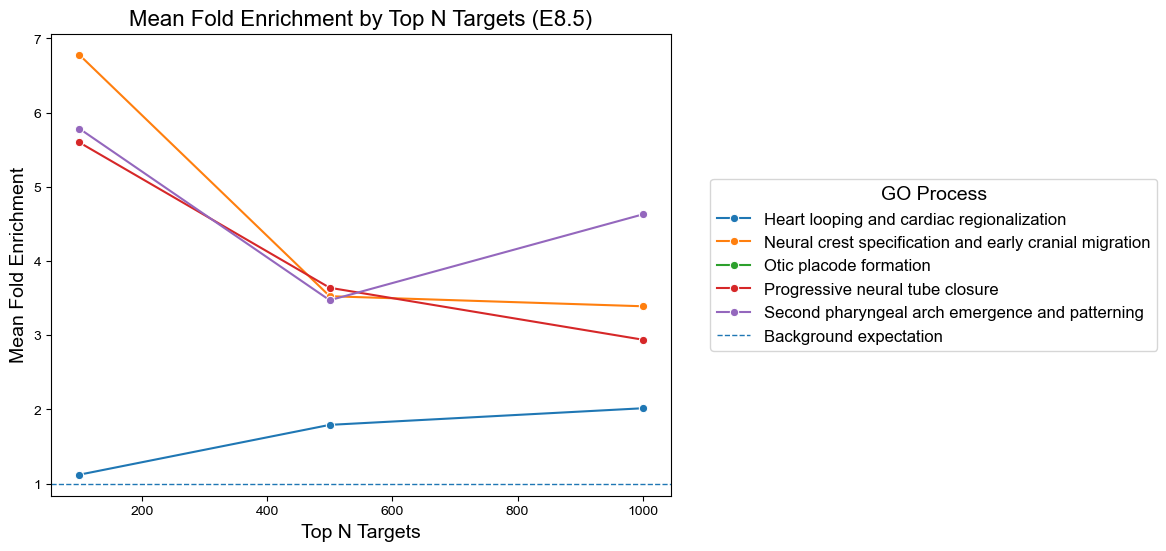

In [59]:
mean_fold_enrichment_df = (
    process_by_n_df.groupby(["Process", "N"])["Fold_Enrichment"]
    .mean()
    .reset_index()
    .pivot(index="Process", columns="N", values="Fold_Enrichment")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.lineplot(
    data=mean_fold_enrichment_df.melt(id_vars="Process", value_vars=n_values),
    x="N",
    y="value",
    hue="Process",
    marker="o",
    ax=ax,
)

# Expected enrichment under random ranking
ax.axhline(
    1,
    linestyle="--",
    linewidth=1,
    label="Background expectation",
)

ax.set_title(f"Mean Fold Enrichment by Top N Targets ({time_point})", fontsize=16)
ax.set_xlabel("Top N Targets", fontsize=14)
ax.set_ylabel("Mean Fold Enrichment", fontsize=14)

ax.legend(bbox_to_anchor=(1.05, 0.5), loc="center left", fontsize=12, title="GO Process", title_fontsize=14)



/tmp/ipykernel_183334/1748465010.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), fontsize=14)


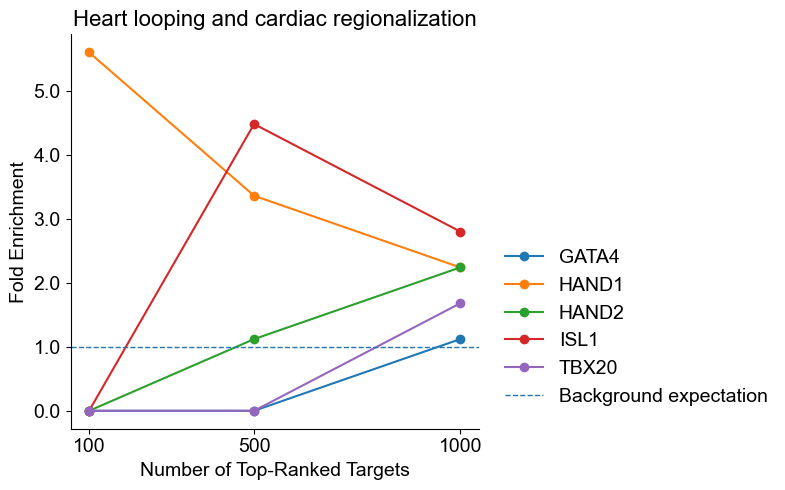

/tmp/ipykernel_183334/1748465010.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), fontsize=14)


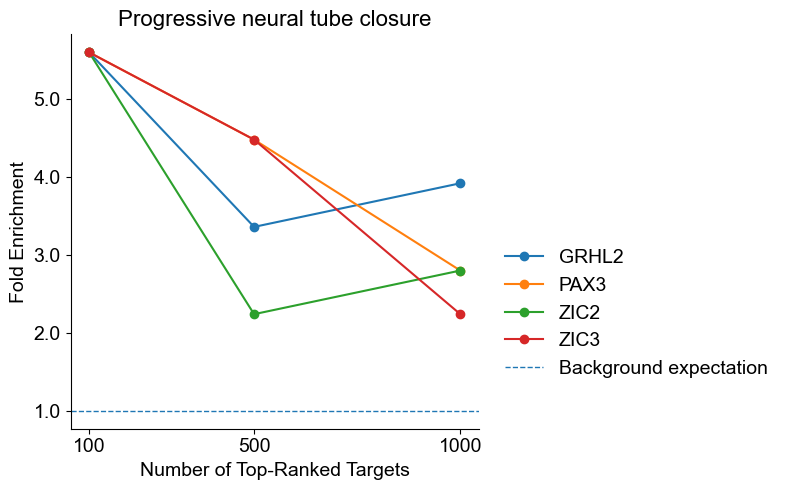

/tmp/ipykernel_183334/1748465010.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), fontsize=14)


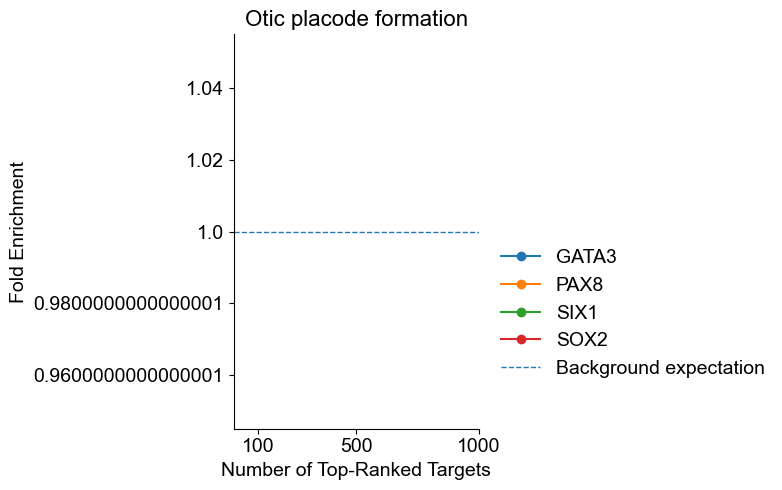

/tmp/ipykernel_183334/1748465010.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), fontsize=14)


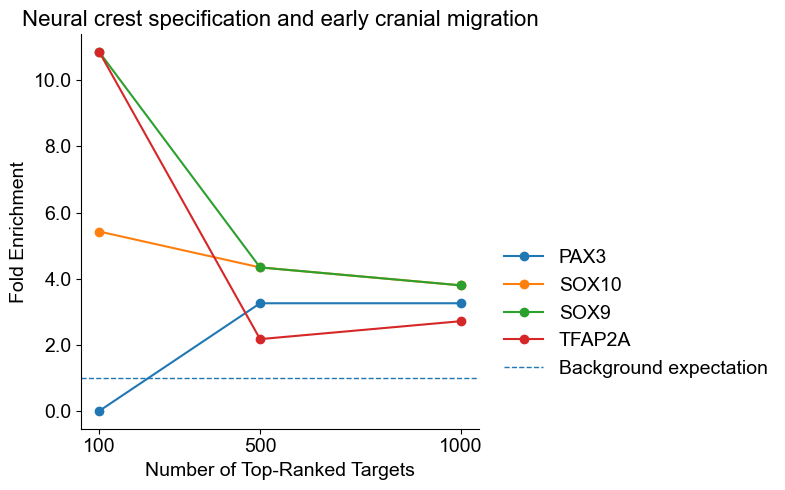

/tmp/ipykernel_183334/1748465010.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), fontsize=14)


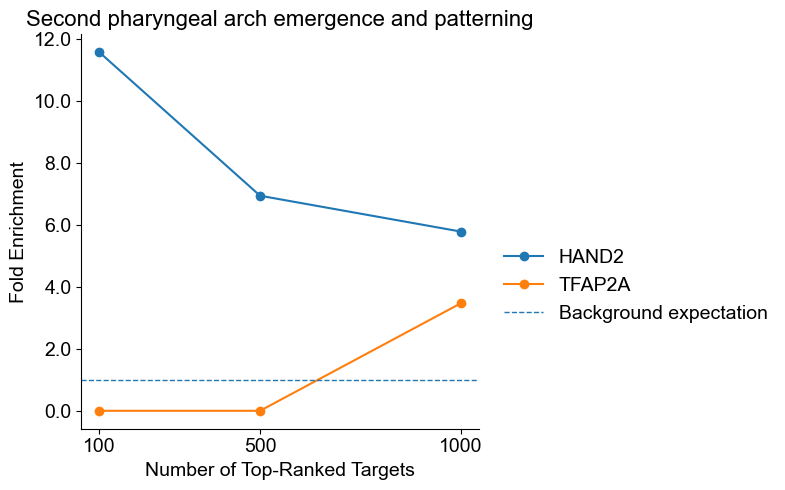

In [60]:
for process in process_by_n_df["Process"].unique():

    plot_df = process_by_n_df[
        process_by_n_df["Process"] == process
    ]

    fig, ax = plt.subplots(figsize=(8, 5))

    for tf, tf_df in plot_df.groupby("TF"):
        tf_df = tf_df.sort_values("N")

        ax.plot(
            tf_df["N"],
            tf_df["Fold_Enrichment"],
            marker="o",
            label=tf,
        )

    # Expected enrichment under random ranking
    ax.axhline(
        1,
        linestyle="--",
        linewidth=1,
        label="Background expectation",
    )

    ax.set_xlabel("Number of Top-Ranked Targets", fontsize=14)
    ax.set_ylabel("Fold Enrichment", fontsize=14)
    ax.set_title(process, fontsize=16)

    ax.set_xticks(n_values)
    ax.set_xticklabels(n_values, fontsize=14)
    ax.set_yticklabels(ax.get_yticks(), fontsize=14)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        bbox_to_anchor=(1.02, 0.5),
        loc="upper left",
        frameon=False,
        fontsize=14
    )

    fig.tight_layout()

    plt.show()

---

## Driver TFs

Looking for driver TFs using network centrality

In [61]:
import networkx as nx

# Load full GRN for the sample
model_sample = "hepatocytes_1"
data_sample = "E8.5_rep1"

grn_df = load_full_grn_df(model_sample, data_sample)

G = nx.from_pandas_edgelist(
    grn_df,
    source="Source",
    target="Target",
    edge_attr="Score",
    create_using=nx.DiGraph(),  # Use nx.Graph() if undirected
)
G_reversed = G.reverse(copy=True)

# Calculate PageRank on the reversed network
weighted_pagerank = nx.pagerank(G_reversed, weight='Score')
tf_centrality_df = (
    pd.DataFrame.from_dict(weighted_pagerank, orient="index", columns=["pagerank"])
    .sort_values(by="pagerank", ascending=False)
    .reset_index()
    .rename(columns={"index": "TF"})
)

# Filter to get the pagerank of TFs
unique_tfs = set(grn_df["Source"])
tf_only_centrality_df = tf_centrality_df[tf_centrality_df["TF"].isin(unique_tfs)].reset_index(drop=True)

# Min-Max normalization for the filtered TF dataframe
tf_only_centrality_df["Normalized_Score"] = (
    tf_only_centrality_df["pagerank"] - tf_only_centrality_df["pagerank"].min()
) / (tf_only_centrality_df["pagerank"].max() - tf_only_centrality_df["pagerank"].min())

# Check your top 10 Master Regulators
print(tf_only_centrality_df[["TF", "pagerank", "Normalized_Score"]].head(15))

        TF  pagerank  Normalized_Score
0    TBX20  0.003742          1.000000
1    RUNX1  0.003653          0.975178
2     TAL1  0.003616          0.964771
3    IKZF1  0.003604          0.961390
4     KLF1  0.003560          0.948958
5        T  0.003559          0.948868
6    ZFPM1  0.003498          0.931688
7     PAX6  0.003488          0.929000
8    ZFPM2  0.003462          0.921744
9    MEF2C  0.003452          0.918780
10    LEF1  0.003433          0.913506
11     JUN  0.003427          0.912021
12   MEIS1  0.003412          0.907871
13  TFAP2A  0.003411          0.907438
14   PITX1  0.003375          0.897372


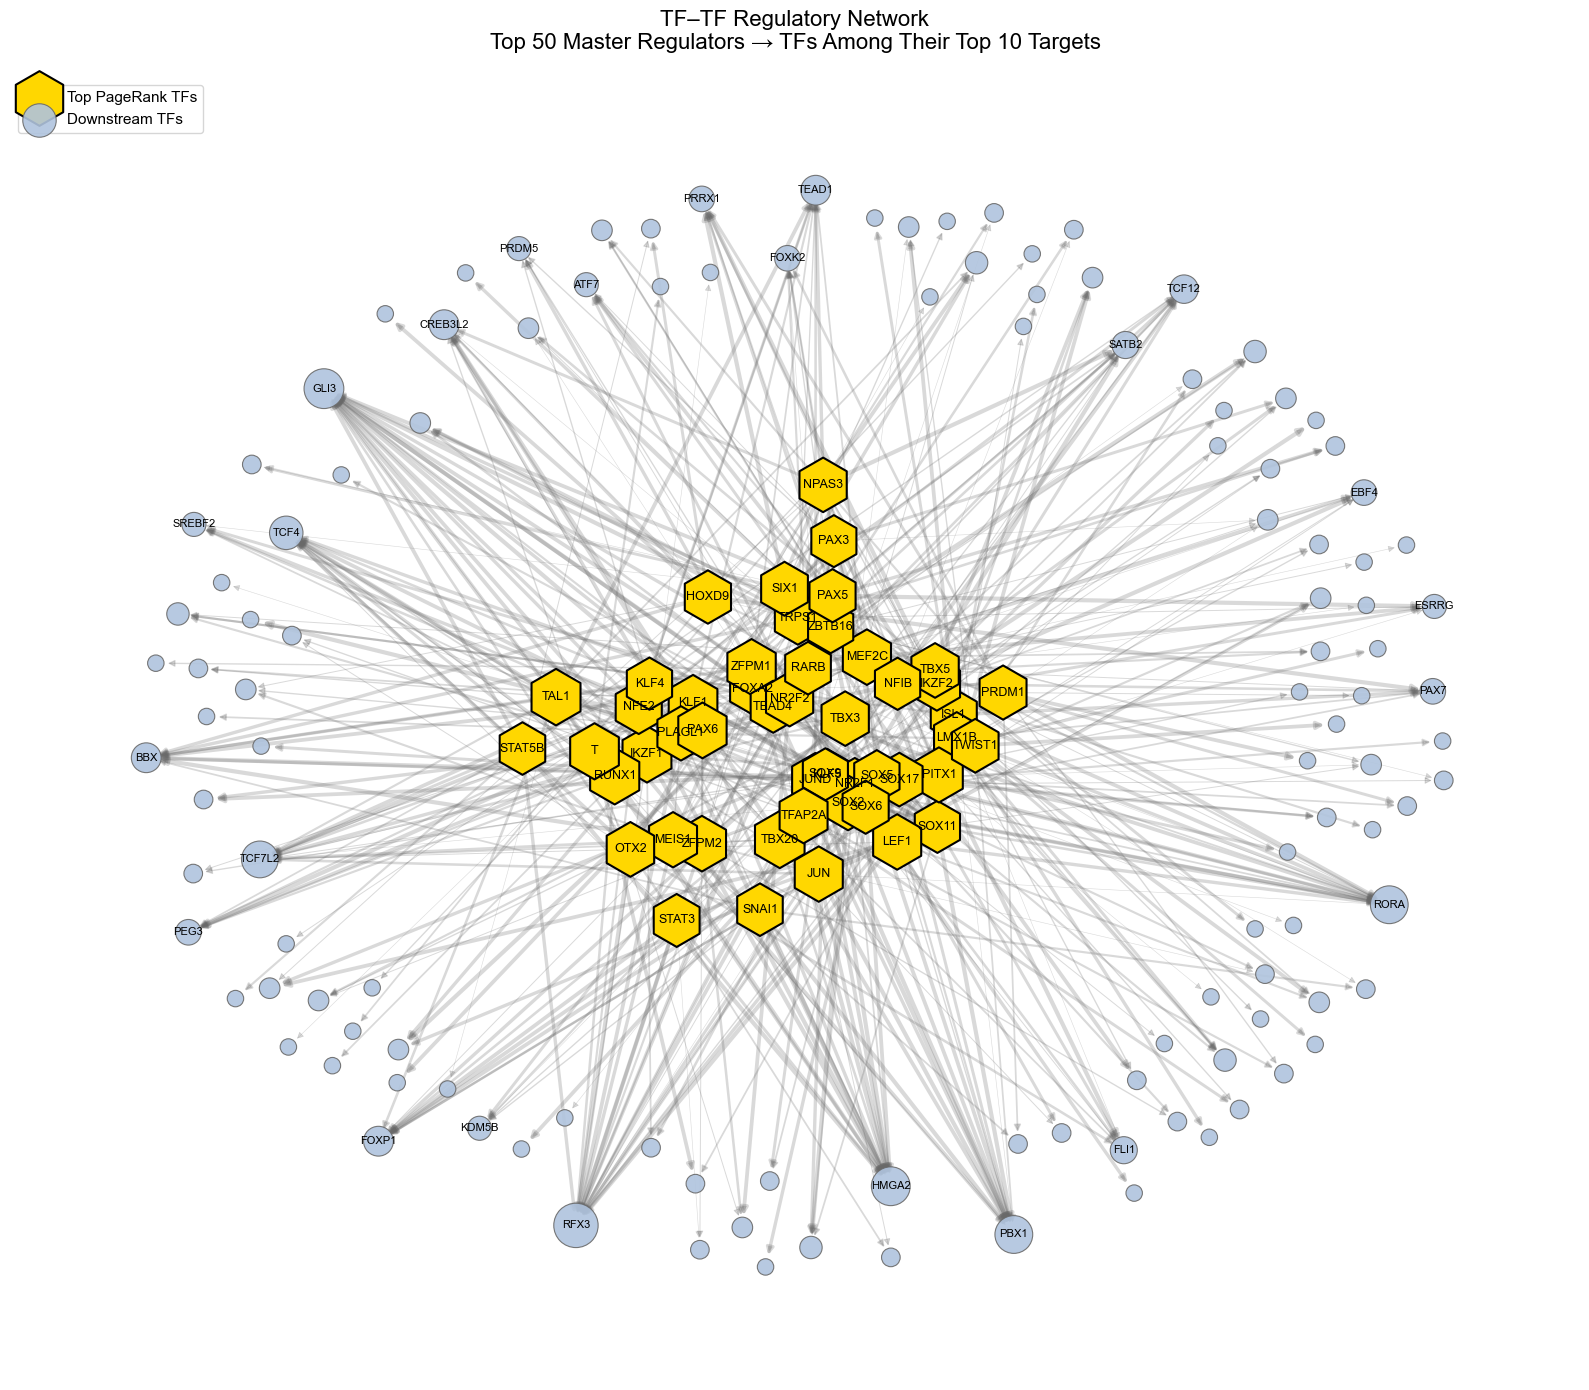

In [62]:
n_tfs = 50
n_tf_targets_per_tf = 10

top_tfs = (
    tf_only_centrality_df
    .head(n_tfs)["TF"]
    .tolist()
)

tf_set = set(unique_tfs)

# ---------------------------------------------------------
# Restrict to TF -> TF interactions first
# ---------------------------------------------------------

tf_tf_edges_df = grn_df[
    grn_df["Source"].isin(top_tfs)
    & grn_df["Target"].isin(tf_set)
    & (grn_df["Source"] != grn_df["Target"])
].copy()


# ---------------------------------------------------------
# Rank TF targets within each source TF
# ---------------------------------------------------------

tf_tf_edges_df = tf_tf_edges_df.sort_values(
    ["Source", "Score"],
    ascending=[True, False],
)

tf_tf_edges_df["TF_Target_Rank"] = (
    tf_tf_edges_df
    .groupby("Source")
    .cumcount()
    + 1
)

# ---------------------------------------------------------
# Keep top TF -> TF interactions per regulator
# ---------------------------------------------------------

top_tf_target_edges_df = tf_tf_edges_df[
    tf_tf_edges_df["TF_Target_Rank"] <= n_tf_targets_per_tf
].copy()

# ---------------------------------------------------------
# Create network
# ---------------------------------------------------------

G_sub = nx.from_pandas_edgelist(
    top_tf_target_edges_df,
    source="Source",
    target="Target",
    edge_attr=["Score", "TF_Target_Rank"],
    create_using=nx.DiGraph(),
)

G_sub.remove_edges_from(nx.selfloop_edges(G_sub))


# ---------------------------------------------------------
# Separate master TFs from downstream-only TFs
# ---------------------------------------------------------

nodes = list(G_sub.nodes())

master_tf_nodes = [
    node for node in nodes
    if node in top_tfs
]

downstream_tf_nodes = [
    node for node in nodes
    if node not in top_tfs
]


# ---------------------------------------------------------
# Layout:
# master regulators in the inner shell,
# downstream TFs in the outer shell
# ---------------------------------------------------------

pos = nx.forceatlas2_layout(
    G_sub
)


# ---------------------------------------------------------
# Node sizes
#
# Master TF size = normalized PageRank
# ---------------------------------------------------------

pagerank_map = dict(
    zip(
        tf_only_centrality_df["TF"],
        tf_only_centrality_df["Normalized_Score"],
    )
)

master_node_sizes = [
    500 + 1200 * pagerank_map.get(node, 0)
    for node in master_tf_nodes
]

# Downstream TF size = number of master TFs targeting it
in_degree = dict(G_sub.in_degree())

downstream_node_sizes = [
    100 + 40 * in_degree[node]
    for node in downstream_tf_nodes
]


# ---------------------------------------------------------
# Edge width based on target rank
#
# Rank 1 = thickest
# Rank 100 = thinnest
# ---------------------------------------------------------

edge_widths = []

for u, v in G_sub.edges():
    rank = G_sub[u][v]["TF_Target_Rank"]

    width = 0.4 + 2.6 * (
        1 - (rank - 1) / (n_tf_targets_per_tf - 1)
    )

    edge_widths.append(width)


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

plt.figure(figsize=(16, 14))


# Master regulators
nx.draw_networkx_nodes(
    G_sub,
    pos,
    nodelist=master_tf_nodes,
    node_color="gold",
    node_size=master_node_sizes,
    node_shape="h",
    edgecolors="black",
    linewidths=1.5,
    label="Top PageRank TFs",
)


# Downstream TF targets
nx.draw_networkx_nodes(
    G_sub,
    pos,
    nodelist=downstream_tf_nodes,
    node_color="lightsteelblue",
    node_size=downstream_node_sizes,
    node_shape="o",
    edgecolors="dimgray",
    linewidths=0.8,
    alpha=0.9,
    label="Downstream TFs",
)


# Directed edges
nx.draw_networkx_edges(
    G_sub,
    pos,
    width=edge_widths,
    edge_color="dimgray",
    alpha=0.25,
    arrowsize=10,
    arrowstyle="-|>",
)


# Label master TFs
master_labels = {
    node: node
    for node in master_tf_nodes
}

nx.draw_networkx_labels(
    G_sub,
    pos,
    labels=master_labels,
    font_size=9,
    font_weight="bold",
)


# Optionally label highly convergent downstream TFs
min_downstream_indegree_to_label = 5

downstream_labels = {
    node: node
    for node in downstream_tf_nodes
    if in_degree[node] >= min_downstream_indegree_to_label
}

nx.draw_networkx_labels(
    G_sub,
    pos,
    labels=downstream_labels,
    font_size=8,
)


plt.title(
    f"TF–TF Regulatory Network\n"
    f"Top {n_tfs} Master Regulators → "
    f"TFs Among Their Top {n_tf_targets_per_tf} Targets",
    fontsize=16,
    pad=20,
)

plt.legend(
    scatterpoints=1,
    loc="upper left",
    fontsize=11,
)

plt.axis("off")
plt.tight_layout()
plt.show()

---

## Labeling Cell Lineages

Does the model, when trained using hepatocyte data, correctly identify lineage-specific signaling in mouse embryonic cells? To test this, I first need to 

In [63]:
def load_expression_data(cell_type, sample_name):
    import muon as mu
    mudata_path = Path(f"/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/sample_input_data/{cell_type}/{sample_name}/multiome_processed.h5mu")
    
    mudata = mu.read_h5mu(mudata_path)
    return mudata

In [64]:
import scanpy as sc

e85_expression = load_expression_data("mESC", "E8.5_rep1")
rna = e85_expression["rna"]


/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/muon/_core/preproc.py:32: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become t

In [65]:
# Keep original object untouched
rna_de = rna.copy()

# Restore raw counts into X
rna_de.X = rna_de.layers["counts"].copy()

# Standard single-cell normalization
sc.pp.normalize_total(
    rna_de,
    target_sum=1e4
)

sc.pp.log1p(rna_de)

sc.tl.rank_genes_groups(
    rna_de,
    groupby="leiden",
    reference="rest",
    method="wilcoxon",
    use_raw=False,
    pts=True,
    key_added="leiden_markers"
)

clusters_of_interest = ["2", "10", "14", "19", "20", "21", "24"]

for cluster in clusters_of_interest:
    df = sc.get.rank_genes_groups_df(
        rna_de,
        group=cluster,
        key="leiden_markers"
    )

    print(f"\n===== CLUSTER {cluster} =====")
    print(
        df[
            [
                "names",
                "scores",
                "logfoldchanges",
                "pvals_adj",
                "pct_nz_group",
                "pct_nz_reference",
            ]
        ]
        .head(20)
        .to_string(index=False)
    )

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_g


===== CLUSTER 2 =====
   names    scores  logfoldchanges     pvals_adj  pct_nz_group  pct_nz_reference
   Rspo3 22.990526        3.961679 1.350718e-112      0.981900          0.203070
    Dll1 22.382010        5.056960 6.863661e-107      0.923077          0.076756
    Lef1 22.049660        2.187530 7.473416e-104      0.990950          0.585016
    Smc6 21.953691        1.733295 4.650182e-103      0.986425          0.720174
    Dll3 21.684914        4.616401 1.326868e-100      0.904977          0.094277
  Pcdh19 20.579256        4.403404  1.634902e-90      0.868778          0.125313
  Kif26b 19.959095        2.662048  4.158341e-85      0.968326          0.373436
   Smoc1 19.650990        2.680816  1.650926e-82      0.950226          0.370098
   Rftn1 19.615614        4.054100  2.944312e-82      0.841629          0.108794
Tmem132c 19.602613        2.400280  3.421598e-82      0.977376          0.450692
  Rnf213 19.170191        3.828723  1.390662e-78      0.841629          0.128817
   Ml

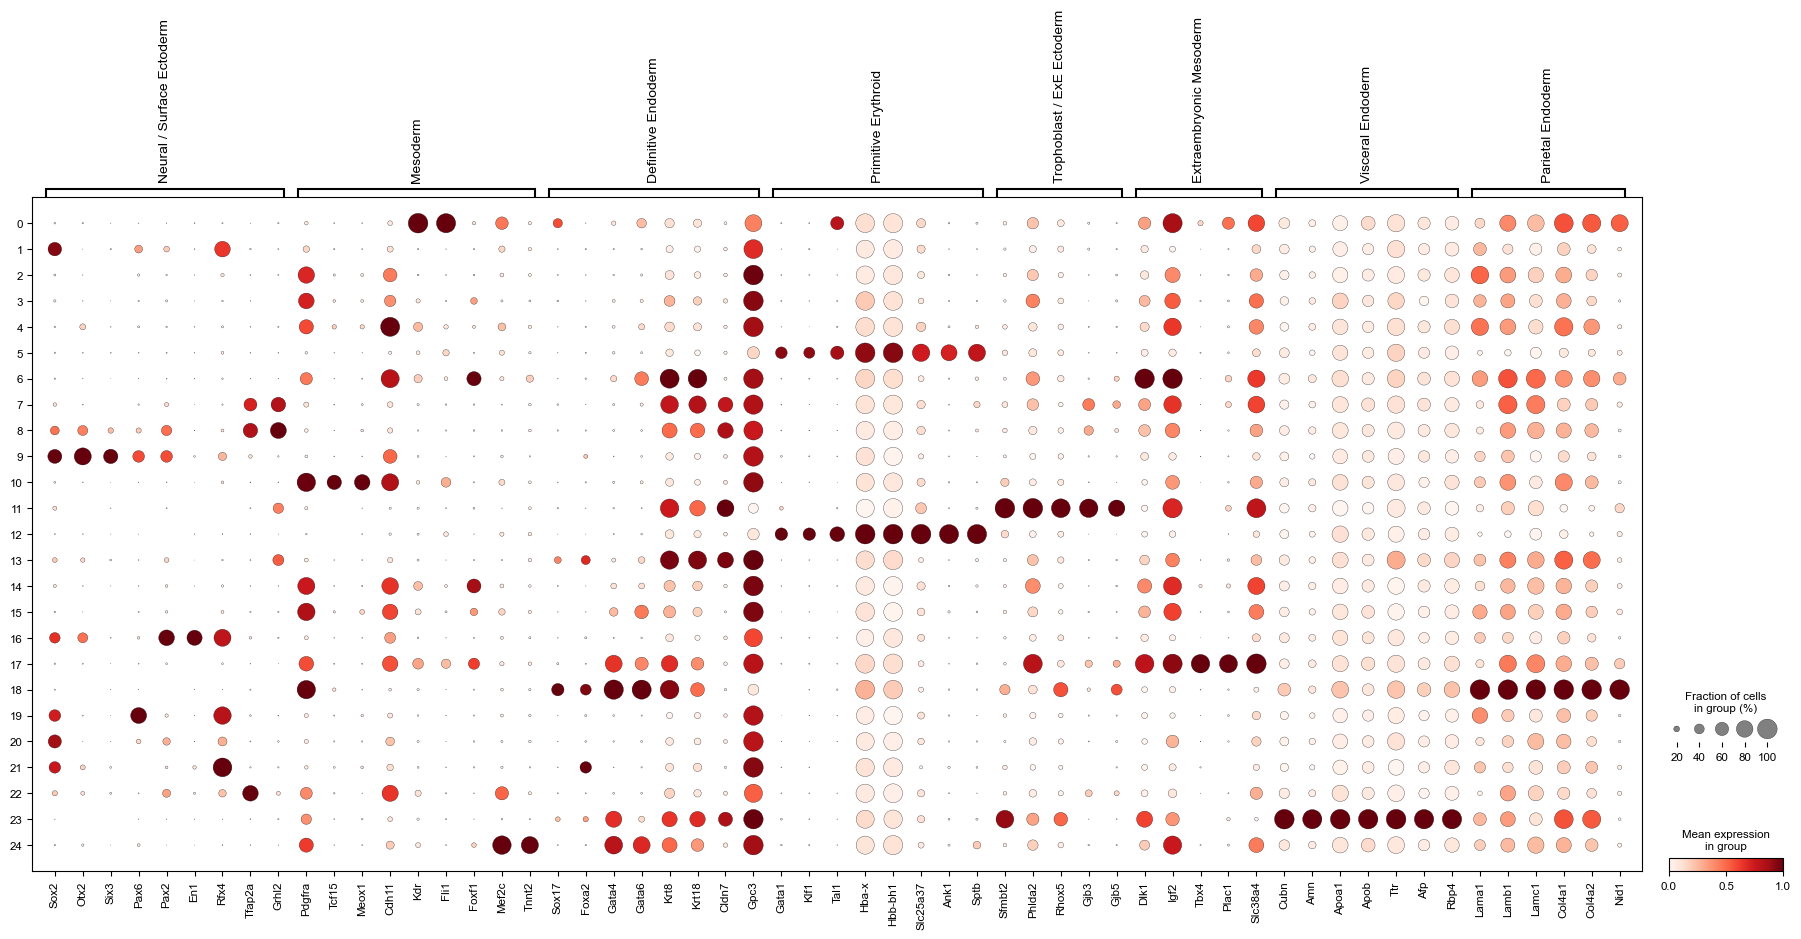

In [75]:
marker_groups = {
    "Neural / Surface Ectoderm": [
        "Sox2", "Otx2", "Six3", "Pax6",
        "Pax2", "En1", "Rfx4",
        "Tfap2a", "Grhl2",
    ],

    "Mesoderm": [
        "Pdgfra", "Tcf15", "Meox1",
        "Cdh11", "Kdr", "Fli1",
        "Foxf1", "Mef2c", "Tnnt2",
    ],

    "Definitive Endoderm": [
        "Sox17", "Foxa2", "Gata4", "Gata6",
        "Krt8", "Krt18", "Cldn7", "Gpc3",
    ],

    "Primitive Erythroid": [
        "Gata1", "Klf1", "Tal1",
        "Hba-x", "Hbb-bh1", "Slc25a37",
        "Ank1", "Sptb",
    ],

    "Trophoblast / ExE Ectoderm": [
        "Sfmbt2", "Phlda2", "Rhox5",
        "Gjb3", "Gjb5",
    ],

    "Extraembryonic Mesoderm": [
        "Dlk1", "Igf2", "Tbx4",
        "Plac1", "Slc38a4",
    ],

    "Visceral Endoderm": [
        "Cubn", "Amn", "Apoa1",
        "Apob", "Ttr", "Afp", "Rbp4",
    ],

    "Parietal Endoderm": [
        "Lama1", "Lamb1", "Lamc1",
        "Col4a1", "Col4a2", "Nid1",
    ],
}

# Drop unused Leiden categories
rna_de.obs["leiden"] = (
    rna_de.obs["leiden"]
    .cat.remove_unused_categories()
)

# Remove genes absent from the dataset
marker_groups = {
    group: [gene for gene in genes if gene in rna_de.var_names]
    for group, genes in marker_groups.items()
}

# Remove empty marker groups
marker_groups = {
    group: genes
    for group, genes in marker_groups.items()
    if len(genes) > 0
}

# Order clusters numerically
clusters_of_interest = [
    str(i)
    for i in range(25)
    if str(i) in rna_de.obs["leiden"].cat.categories
]

sc.pl.dotplot(
    rna_de,
    marker_groups,
    groupby="leiden",
    categories_order=clusters_of_interest,
    standard_scale="var",
    swap_axes=False,
    use_raw=False,
)

In [67]:
all_clusters = [str(x) for x in rna_de.obs["leiden"].cat.categories]

summary = {}

for cluster in all_clusters:
    df = sc.get.rank_genes_groups_df(
        rna_de,
        group=cluster,
        key="leiden_markers"
    ).copy()

    df = df[
        (df["scores"] > 0) &
        (df["pvals_adj"] < 0.05)
    ]

    df["specificity"] = (
        df["pct_nz_group"] - df["pct_nz_reference"]
    )

    # Combine statistical rank and specificity
    df = df.sort_values(
        ["scores", "specificity"],
        ascending=False
    )

    summary[cluster] = df["names"].head(15).tolist()

for cluster, genes in summary.items():
    print(f"Cluster {cluster}: {', '.join(genes)}")

Cluster 0: Kdr, Fli1, Plvap, Egfl7, Flt1, Shank3, Elk3, Igfbp4, Tek, Ramp2, Flt4, Rhoj, Arap3, Vav3, Ptprm
Cluster 1: Ptn, Mast4, Npas3, Adgrv1, Sox2ot, Car10, Ctnna2, Fgf15, Fst, Slc35f1, Zfp423, Efna5, Ptpn13, Fmn2, Epha4
Cluster 2: Rspo3, Dll1, Lef1, Smc6, Dll3, Pcdh19, Kif26b, Smoc1, Rftn1, Tmem132c, Rnf213, Mllt3, Epha4, Laptm4b, Hoxd4
Cluster 3: Laptm4b, Lef1, Hoxaas3, Ifitm1, Fn1, Ptk7, Smc6, Mdk, Cited1, Pcdh19, Prtg, Ptma, Gja1, Rspo3, Rps2
Cluster 4: Cdh11, Col26a1, Ebf2, Ebf1, Fbn2, Dlc1, Vcan, Prkg1, Col23a1, Colec12, Itga9, Cped1, Tbx1, Foxp2, Auts2
Cluster 5: Hbb-bh1, Hba-x, Hba-a1, Fth1, Rplp0, Abcb10, Hba-a2, Rps9, Gpx1, Reln, Frrs1, Blvrb, Mir142hg, Sptb, Slc25a21
Cluster 6: Pmp22, Dlk1, Nrp1, Ahnak, Ece1, Igf2, Col1a2, Tmem108, Podxl, Stard8, Mest, Prdm6, Col5a2, Serpinh1, Pcdh7
Cluster 7: Wnt6, Slc2a3, Bcam, Frem2, Dag1, Epcam, Cdh3, Spint2, Npnt, Cdh1, Esrp1, Hapln1, Cldn6, F11r, Wls
Cluster 8: Epcam, Slc2a3, Grhl2, Cldn6, Frem2, Esrp1, Cdh1, Eya1, Ikzf2, Etl4, Spin

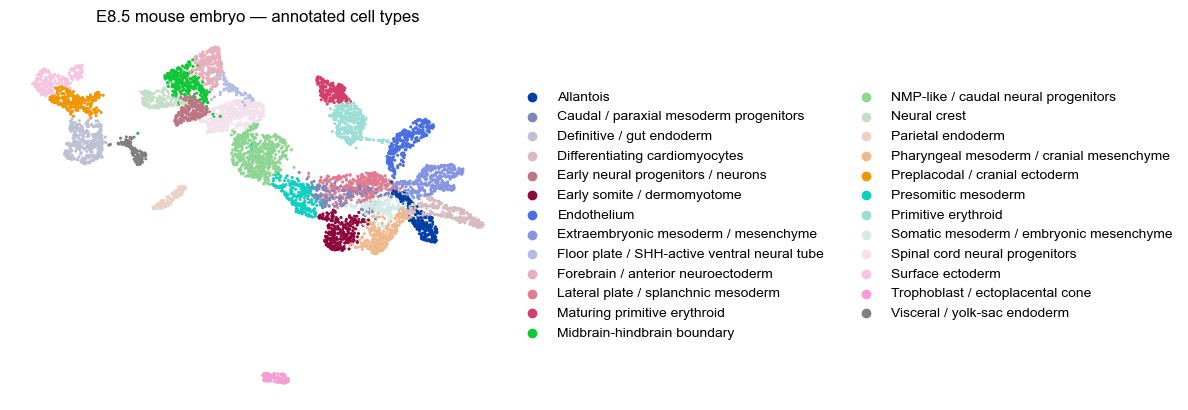

In [68]:
cluster_to_celltype = {
    "0":  "Endothelium",
    "1":  "Early neural progenitors / neurons",
    "2":  "Presomitic mesoderm",
    "3":  "Caudal / paraxial mesoderm progenitors",
    "4":  "Pharyngeal mesoderm / cranial mesenchyme",
    "5":  "Primitive erythroid",
    "6":  "Extraembryonic mesoderm / mesenchyme",
    "7":  "Surface ectoderm",
    "8":  "Preplacodal / cranial ectoderm",
    "9":  "Forebrain / anterior neuroectoderm",
    "10": "Early somite / dermomyotome",
    "11": "Trophoblast / ectoplacental cone",
    "12": "Maturing primitive erythroid",
    "13": "Definitive / gut endoderm",
    "14": "Lateral plate / splanchnic mesoderm",
    "15": "Somatic mesoderm / embryonic mesenchyme",
    "16": "Midbrain-hindbrain boundary",
    "17": "Allantois",
    "18": "Parietal endoderm",
    "19": "Spinal cord neural progenitors",
    "20": "NMP-like / caudal neural progenitors",
    "21": "Floor plate / SHH-active ventral neural tube",
    "22": "Neural crest",
    "23": "Visceral / yolk-sac endoderm",
    "24": "Differentiating cardiomyocytes",
}

rna.obs["cell_type"] = (
    rna.obs["leiden"]
    .astype(str)
    .map(cluster_to_celltype)
)

rna.obs["cell_type"] = pd.Categorical(rna.obs["cell_type"])

rna.obs[["leiden", "cell_type"]].drop_duplicates().sort_values("leiden")

sc.pl.umap(
    rna,
    color="cell_type",
    legend_loc="right margin",
    frameon=False,
    size=20,
    title="E8.5 mouse embryo — annotated cell types"
)

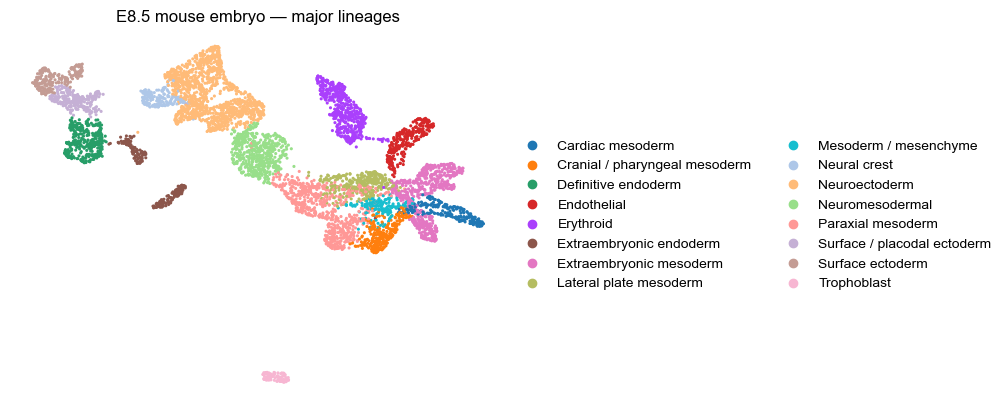

In [69]:
cluster_to_lineage = {
    "0":  "Endothelial",
    "1":  "Neuroectoderm",
    "2":  "Paraxial mesoderm",
    "3":  "Paraxial mesoderm",
    "4":  "Cranial / pharyngeal mesoderm",
    "5":  "Erythroid",
    "6":  "Extraembryonic mesoderm",
    "7":  "Surface ectoderm",
    "8":  "Surface / placodal ectoderm",
    "9":  "Neuroectoderm",
    "10": "Paraxial mesoderm",
    "11": "Trophoblast",
    "12": "Erythroid",
    "13": "Definitive endoderm",
    "14": "Lateral plate mesoderm",
    "15": "Mesoderm / mesenchyme",
    "16": "Neuroectoderm",
    "17": "Extraembryonic mesoderm",
    "18": "Extraembryonic endoderm",
    "19": "Neuroectoderm",
    "20": "Neuromesodermal",
    "21": "Neuroectoderm",
    "22": "Neural crest",
    "23": "Extraembryonic endoderm",
    "24": "Cardiac mesoderm",
}

rna.obs["lineage"] = pd.Categorical(
    rna.obs["leiden"].astype(str).map(cluster_to_lineage)
)

sc.pl.umap(
    rna,
    color="lineage",
    legend_loc="right margin",
    frameon=False,
    size=20,
    title="E8.5 mouse embryo — major lineages"
)

Overlap the genes in the GRN with the genes in the dataset

In [70]:
grn = (
    grn_df[
        ["Source", "Target", "Score"]
    ]
    .dropna()
    .groupby(["Source", "Target"], as_index=False)["Score"]
    .max()
)

print(grn.shape)
print(grn["Source"].nunique(), "TFs")
print(grn["Target"].nunique(), "targets")

gene_lookup = {
    gene.upper(): gene
    for gene in rna.var_names
}

grn["Source_gene"] = (
    grn["Source"]
    .astype(str)
    .str.upper()
    .map(gene_lookup)
)

grn["Target_gene"] = (
    grn["Target"]
    .astype(str)
    .str.upper()
    .map(gene_lookup)
)

print(
    "Mapped sources:",
    grn["Source_gene"].notna().mean()
)

print(
    "Mapped targets:",
    grn["Target_gene"].notna().mean()
)

grn_e85 = (
    grn
    .dropna(subset=["Source_gene", "Target_gene"])
    .query("Source_gene != Target_gene")
    .copy()
)

TOP_K = 100

grn_top = (
    grn_e85
    .sort_values(
        ["Source_gene", "Score"],
        ascending=[True, False]
    )
    .groupby("Source_gene")
    .head(TOP_K)
    .copy()
)

grn_top.groupby("Source_gene").size().describe()

(7464370, 3)
430 TFs
17359 targets
Mapped sources: 1.0
Mapped targets: 1.0


count    430.0
mean     100.0
std        0.0
min      100.0
25%      100.0
50%      100.0
75%      100.0
max      100.0
dtype: float64

In [71]:
import scanpy as sc
import pandas as pd
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

cluster_markers = {}

for cluster in rna_de.obs["leiden"].cat.categories:

    df = sc.get.rank_genes_groups_df(
        rna_de,
        group=cluster,
        key="leiden_markers"
    )

    df = df[
        (df["scores"] > 0) &
        (df["pvals_adj"] < 0.01)
    ]

    # Top 200 positive markers
    cluster_markers[str(cluster)] = set(
        df["names"].head(200)
    )
    
universe = set(rna.var_names)

records = []

for cluster, markers in cluster_markers.items():

    for tf, sub in grn_top.groupby("Source_gene"):

        targets = set(sub["Target_gene"]) & universe

        if len(targets) < 10:
            continue

        a = len(markers & targets)
        b = len(targets - markers)
        c = len(markers - targets)
        d = len(universe - markers - targets)

        odds_ratio, pval = fisher_exact(
            [[a, b], [c, d]],
            alternative="greater"
        )

        records.append({
            "cluster": cluster,
            "TF": tf,
            "overlap": a,
            "n_targets": len(targets),
            "odds_ratio": odds_ratio,
            "pval": pval
        })

enrichment = pd.DataFrame(records)

enrichment["FDR"] = multipletests(
    enrichment["pval"],
    method="fdr_bh"
)[1]

for cluster in sorted(
    enrichment["cluster"].unique(),
    key=int
):

    x = enrichment[
        enrichment["cluster"] == cluster
    ].sort_values(
        ["FDR", "odds_ratio"],
        ascending=[True, False]
    )

    print(f"\n===== CLUSTER {cluster} =====")

    print(
        x[
            ["TF", "overlap", "odds_ratio", "FDR"]
        ]
        .head(10)
        .to_string(index=False)
    )


===== CLUSTER 0 =====
    TF  overlap  odds_ratio          FDR
  Irf2       16   23.820911 6.754374e-15
  Zeb1       14   20.137909 2.146846e-12
 Zfpm2       14   20.137909 2.146846e-12
  Nfib       10   13.453216 8.815104e-08
Plagl1       10   13.453216 8.815104e-08
  Ctcf        9   11.911628 9.680258e-07
  Rest        9   11.911628 9.680258e-07
  Rfx2        9   11.911628 9.680258e-07
 Rreb1        9   11.911628 9.680258e-07
   Sp1        9   11.911628 9.680258e-07

===== CLUSTER 1 =====
     TF  overlap  odds_ratio          FDR
  Tcf12       26   46.485399 8.150501e-29
   Irf4       25   43.847619 2.280927e-27
L3mbtl3       25   43.847619 2.280927e-27
  Mecp2       24   41.302033 6.923436e-26
    Jun       22   36.471766 4.585379e-23
  Kdm2a       22   36.471766 4.585379e-23
   Mbd3       22   36.471766 4.585379e-23
Neurod1       22   36.471766 4.585379e-23
 Tcf7l1       22   36.471766 4.585379e-23
 Pou2f1       21   34.179761 1.160398e-21

===== CLUSTER 2 =====
     TF  overlap  

In [72]:
X_expr = rna.layers["counts"]

import numpy as np
import scipy.sparse as sp

clusters = [
    str(x)
    for x in rna.obs["leiden"].cat.categories
]

pb = []

for cluster in clusters:

    mask = (
        rna.obs["leiden"].astype(str).values
        == cluster
    )

    m = X_expr[mask].mean(axis=0)

    pb.append(
        np.asarray(m).ravel()
    )

pb = pd.DataFrame(
    pb,
    index=clusters,
    columns=rna.var_names
)

pb_z = (
    pb - pb.mean(axis=0)
) / pb.std(axis=0)

pb_z = pb_z.fillna(0)

gene_index = {
    gene: i
    for i, gene in enumerate(rna.var_names)
}

tfs = sorted(
    grn_top["Source_gene"].unique()
)

tf_index = {
    tf: i
    for i, tf in enumerate(tfs)
}

rows = []
cols = []
weights = []

for tf, sub in grn_top.groupby("Source_gene"):

    sub = sub[
        sub["Target_gene"].isin(gene_index)
    ].copy()

    if len(sub) == 0:
        continue

    w = sub["Score"].to_numpy(dtype=float)

    # Scores appear to represent confidence/strength rather than
    # activation vs repression.
    w = np.maximum(w, 0)

    if w.sum() == 0:
        continue

    # Normalize within TF
    w = w / w.sum()

    for target, weight in zip(sub["Target_gene"], w):

        rows.append(gene_index[target])
        cols.append(tf_index[tf])
        weights.append(weight)

W = sp.csr_matrix(
    (weights, (rows, cols)),
    shape=(len(rna.var_names), len(tfs))
)

regulon_activity = pb_z.values @ W

regulon_activity = pd.DataFrame(
    regulon_activity,
    index=clusters,
    columns=tfs
)

regulon_activity_z = (
    regulon_activity -
    regulon_activity.mean(axis=0)
) / regulon_activity.std(axis=0)

regulon_activity_z = regulon_activity_z.fillna(0)

for cluster in clusters:

    top = (
        regulon_activity_z.loc[cluster]
        .sort_values(ascending=False)
        .head(15)
    )

    print(f"\n===== CLUSTER {cluster} =====")
    print(top)


===== CLUSTER 0 =====
Nfib     3.864922
Nr5a2    3.201556
Zeb1     3.105560
Irf2     3.063650
Fli1     3.008256
Zfpm2    2.855657
Ets1     2.475556
Erg      2.368988
Pdx1     2.116843
Etv5     2.016002
Pitx1    1.817397
Spi1     1.606712
Foxa1    1.576623
Nrf1     1.576025
Nfia     1.573499
Name: 0, dtype: float64

===== CLUSTER 1 =====
Npas3      1.853485
Tcf7       1.544461
Rbpj       1.521750
L3mbtl3    1.517578
Hand1      1.434910
E2f3       1.411639
Foxp1      1.398270
Mesp1      1.377441
Dpf3       1.353277
Gata2      1.341539
Kdm2b      1.337134
Klf15      1.320361
Duxbl1     1.304109
Runx2      1.299333
Prrx1      1.292171
Name: 1, dtype: float64

===== CLUSTER 2 =====
Lef1       1.682023
Tgif2      1.677375
Kdm5b      1.564797
Nfat5      1.555581
Onecut1    1.531498
Mesp1      1.526659
Nrf1       1.499252
Elf4       1.490457
Taf1       1.471607
Mybl1      1.460711
Hoxc8      1.428777
Mycn       1.401912
Zfp217     1.391131
Ikzf3      1.391094
Cebpd      1.388348
Name: 2, dtyp

Hedgehog_GLI using: ['Gli1', 'Gli2', 'Gli3']
WNT_TCF_LEF using: ['Lef1', 'Tcf7l1', 'Tcf7l2']
Notch using: ['Rbpj', 'Hes1', 'Hey1']
FGF_MAPK using: ['Etv5', 'Elk1', 'Elk3', 'Fos', 'Jun', 'Jund']
Retinoic_acid using: ['Rara', 'Rarb', 'Rarg', 'Nr2f1', 'Nr2f2']
BMP_SMAD using: ['Smad1', 'Smad4']
TGFb_SMAD using: ['Smad3', 'Smad4']
Hippo_TEAD using: ['Tead1', 'Tead2', 'Tead4']


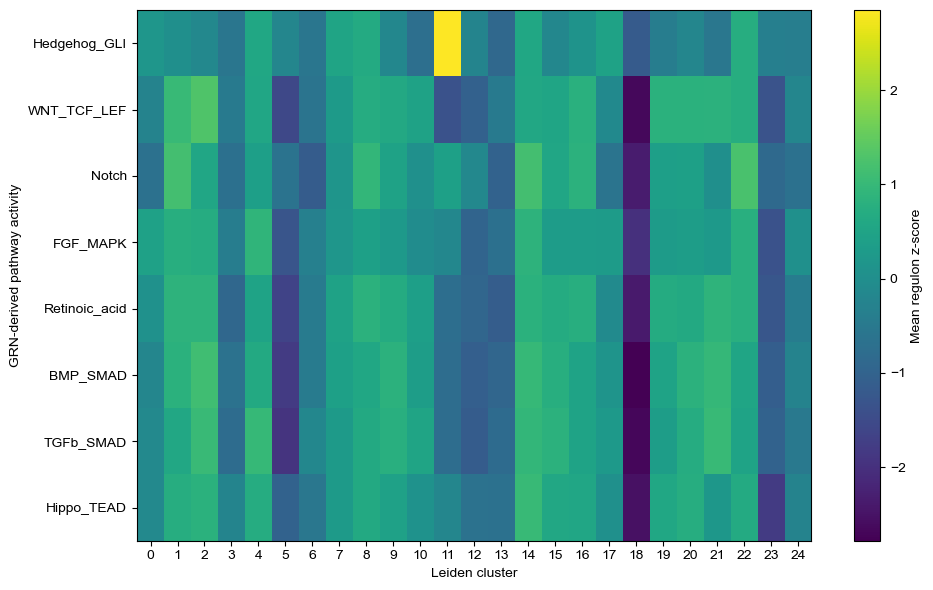

In [73]:
pathway_tfs = {

    "Hedgehog_GLI": [
        "Gli1", "Gli2", "Gli3"
    ],

    "WNT_TCF_LEF": [
        "Lef1", "Tcf7l1", "Tcf7l2"
    ],

    "Notch": [
        "Rbpj", "Hes1", "Hes7",
        "Hey1", "Hey2"
    ],

    "FGF_MAPK": [
        "Etv4", "Etv5",
        "Elk1", "Elk3",
        "Fos", "Jun", "Jund"
    ],

    "Retinoic_acid": [
        "Rara", "Rarb", "Rarg",
        "Nr2f1", "Nr2f2"
    ],

    "BMP_SMAD": [
        "Smad1", "Smad5", "Smad4"
    ],

    "TGFb_SMAD": [
        "Smad2", "Smad3", "Smad4"
    ],

    "Hippo_TEAD": [
        "Tead1", "Tead2",
        "Tead3", "Tead4"
    ],
}

pathway_activity = pd.DataFrame(
    index=regulon_activity_z.index
)

for pathway, regulators in pathway_tfs.items():

    available = [
        tf for tf in regulators
        if tf in regulon_activity_z.columns
    ]

    print(
        pathway,
        "using:",
        available
    )

    if len(available) > 0:

        pathway_activity[pathway] = (
            regulon_activity_z[
                available
            ].mean(axis=1)
        )
        
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.imshow(
    pathway_activity.T,
    aspect="auto"
)

plt.xticks(
    range(len(pathway_activity.index)),
    pathway_activity.index
)

plt.yticks(
    range(len(pathway_activity.columns)),
    pathway_activity.columns
)

plt.xlabel("Leiden cluster")
plt.ylabel("GRN-derived pathway activity")
plt.colorbar(label="Mean regulon z-score")

plt.tight_layout()
plt.show()

In [74]:
cell_regulon_activity = X_expr @ W

cell_regulon_activity = np.asarray(
    cell_regulon_activity
)

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

y = rna.obs["lineage"].astype(str).values

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=3000,
        class_weight="balanced"
    )
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

scores = cross_val_score(
    model,
    cell_regulon_activity,
    y,
    cv=cv,
    scoring="balanced_accuracy"
)

print(
    "GRN balanced accuracy:",
    scores.mean(),
    "+/-",
    scores.std()
)

TypeError: Input should have at least 1 dimension i.e. satisfy `len(x.shape) > 0`, got scalar `array(<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2672020 stored elements and shape (6214, 430)>, dtype=object)` instead.

In [ ]:
G_sub.edges(data=True)

OutEdgeDataView([('FOXA2', 'GLI3', {'Score': 0.9984028, 'TF_Target_Rank': 1}), ('FOXA2', 'BBX', {'Score': 0.99051136, 'TF_Target_Rank': 2}), ('FOXA2', 'PBX1', {'Score': 0.98864895, 'TF_Target_Rank': 3}), ('FOXA2', 'SOX11', {'Score': 0.97043544, 'TF_Target_Rank': 4}), ('FOXA2', 'TCF12', {'Score': 0.9676116, 'TF_Target_Rank': 5}), ('FOXA2', 'GLIS3', {'Score': 0.96332055, 'TF_Target_Rank': 6}), ('FOXA2', 'RORA', {'Score': 0.96194524, 'TF_Target_Rank': 7}), ('FOXA2', 'TRPS1', {'Score': 0.9612181, 'TF_Target_Rank': 8}), ('FOXA2', 'NRF1', {'Score': 0.9594985, 'TF_Target_Rank': 9}), ('FOXA2', 'ZEB1', {'Score': 0.94873214, 'TF_Target_Rank': 10}), ('SOX11', 'PBX1', {'Score': 0.9764361, 'TF_Target_Rank': 1}), ('SOX11', 'HOXB1', {'Score': 0.97187907, 'TF_Target_Rank': 2}), ('SOX11', 'ZIC3', {'Score': 0.9685498, 'TF_Target_Rank': 3}), ('SOX11', 'FLI1', {'Score': 0.9621731, 'TF_Target_Rank': 4}), ('SOX11', 'RORA', {'Score': 0.95752954, 'TF_Target_Rank': 5}), ('SOX11', 'NPAS3', {'Score': 0.94112253,

---

## Feature ablation

### Feature Ablation Functions

In [ ]:
def get_feature_ablation_data(api: wandb.Api) -> pd.DataFrame:
    """
    Retrieve feature ablation data from Weights & Biases and sconvert it to a DataFrame.
    """
    # Project is specified by <entity/project-name>
    runs = api.runs("luminarada-penn-state-health/tf_tg_feature_ablation")

    summary_list, config_list, name_list = [], [], []
    for run in runs:
        # .summary contains the output keys/values for metrics like accuracy.
        #  We call ._json_dict to omit large files
        summary_list.append(run.summary._json_dict)

        # .config contains the hyperparameters.
        #  We remove special values that start with _.
        config_list.append(
            {k: v for k,v in run.config.items()
            if not k.startswith('_')})

        # .name is the human-readable name of the run.
        name_list.append(run.name)

    runs_df = pd.DataFrame({
        "summary": summary_list,
        "config": config_list,
        "name": name_list
        })

    run_summary_df = runs_df["summary"].apply(pd.Series)
    run_summary_df["name"] = runs_df["name"]

    run_config_df = runs_df["config"].apply(pd.Series)

    # Add the run config columns to the summary dataframe
    full_run_df = pd.concat([run_summary_df, run_config_df], axis=1)
    
    return full_run_df


### Feature Ablation Plotting functions

In [ ]:
def plot_feature_ablation_boxplot(full_run_df, metric_col="val/auroc"):
    """
    Create a box plot of validation AUROC for different model variants.
    """
    variant_order = [
        "normal",
        "no_peak_tg_distance",
        "no_expr_info",
        "no_tf_dna_binding",
        "no_peak_info",
    ]

    xtick_name_map = {
        "normal": "Full Model",
        "no_peak_tg_distance": "No Peak-TG Distance",
        "no_expr_info": "No Expression Info",
        "no_tf_dna_binding": "No TF-DNA Binding",
        "no_peak_info": "No Peak Info",
    }

    fig, ax = plt.subplots(figsize=(8, 6))

    sns.boxplot(
        data=full_run_df,
        x="model_variant",
        y=metric_col,
        order=variant_order,
        ax=ax,
    )

    ax.set_xticks(range(len(variant_order)))
    ax.set_xticklabels(
        [xtick_name_map[x] for x in variant_order],
        rotation=45, ha="right", fontsize=14,
    )
    
    if metric_col == "val/auroc":
        metric_name = "Validation AUROC"
        ylim = (0.0, 1.0)
    elif metric_col == "val/auprc":
        metric_name = "Validation AUPRC"
        ylim = (0.0, 1.0)
    elif metric_col == "val/acc":
        metric_name = "Accuracy"
        ylim = (0.0, 1.0)
    else:
        metric_name = metric_col

    ax.set_title(f"Feature Ablation\n{metric_name}", fontsize=18)
    ax.set_ylabel(metric_name, fontsize=16)
    ax.set_xlabel("Model Variant", fontsize=16)
    ax.tick_params(axis="y", labelsize=14)
    ax.tick_params(axis="x", labelsize=14)
    ax.set_ylim(ylim)

    return fig, ax

### Data - Load Feature Ablation Data

In [ ]:
api = wandb.Api()
    
full_run_df = get_feature_ablation_data(api)
full_run_df.to_csv(RESULT_DIR / "feature_ablation_wandb_data.csv", index=False)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /gpfs/Home/esm5360/.netrc.


### Val Metrics by Ablation Boxplots

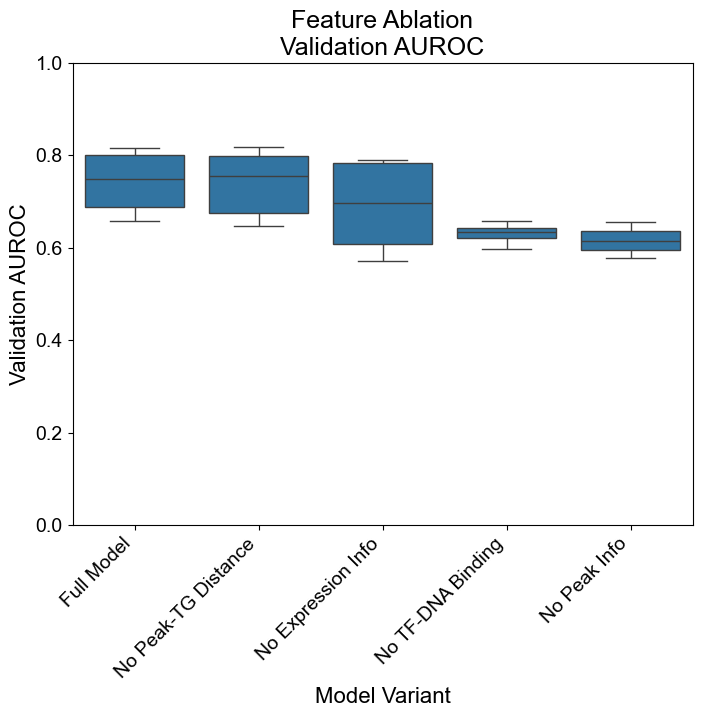

In [ ]:
metric_col = "val/auroc"
assert metric_col in ["val/auroc", "val/auprc", "val/acc"], f"Invalid metric_col: {metric_col}"

feature_ablation_fig, feature_ablation_ax = plot_feature_ablation_boxplot(full_run_df, metric_col=metric_col)

if metric_col == "val/auroc":
    feature_ablation_plot_filename = "feature_ablation_auroc_boxplot.png"
    feature_ablation_key = "feature_ablation_auroc_boxplot"
elif metric_col == "val/auprc":
    feature_ablation_plot_filename = "feature_ablation_auprc_boxplot.png"
    feature_ablation_key = "feature_ablation_auprc_boxplot"
elif metric_col == "val/acc":
    feature_ablation_plot_filename = "feature_ablation_accuracy_boxplot.png"
    feature_ablation_key = "feature_ablation_accuracy_boxplot"

feature_ablation_fig.savefig(
    feature_ablation_plot_dir / feature_ablation_plot_filename, 
    dpi=300, 
    bbox_inches="tight", 
    facecolor="white"
    )

all_figure_axes[feature_ablation_key] = (feature_ablation_fig, feature_ablation_ax)

feature_ablation_fig.show()

### mESC feature ablation

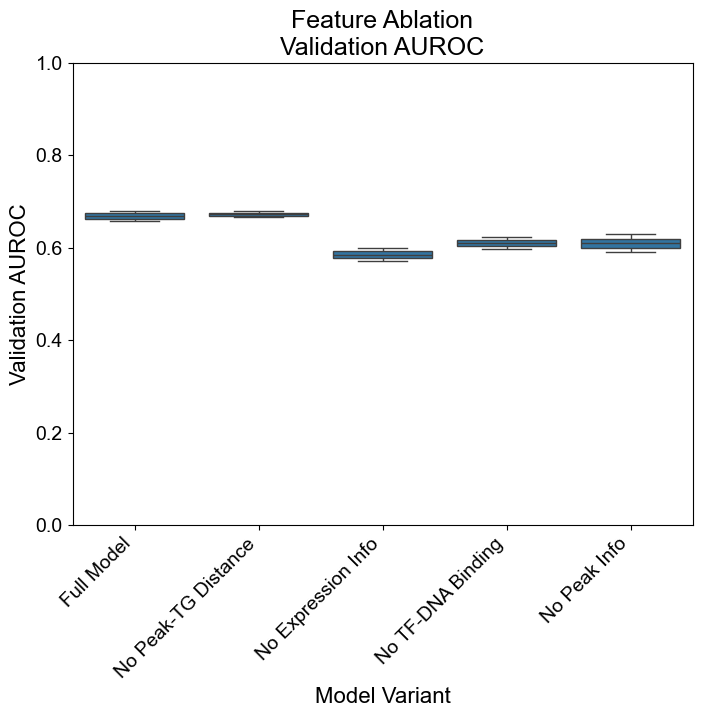

In [ ]:
mESC_full_run_df = full_run_df[full_run_df["cell_type"] == "mESC"].copy()

mESC_feature_ablation_fig, mESC_feature_ablation_ax = plot_feature_ablation_boxplot(mESC_full_run_df)

mESC_ablation_plot_dir = feature_ablation_plot_dir / "mESC_feature_ablation_plots"
mESC_ablation_plot_dir.mkdir(parents=True, exist_ok=True)

mESC_feature_ablation_fig.savefig(
    mESC_ablation_plot_dir / "mESC_feature_ablation_auroc_boxplot.png", 
    dpi=300, 
    bbox_inches="tight", 
    facecolor="white"
    )

### Hepatocyte feature ablation

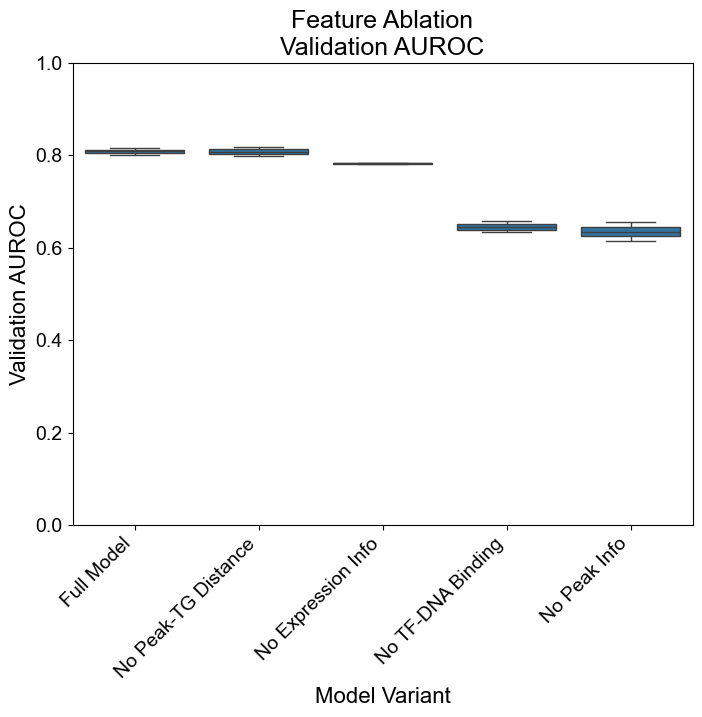

In [ ]:
hepatocytes_full_run_df = full_run_df[full_run_df["cell_type"] == "mouse_hepatocytes"].copy()

hepatocytes_feature_ablation_fig, hepatocytes_feature_ablation_ax = plot_feature_ablation_boxplot(hepatocytes_full_run_df)

hepatocytes_ablation_plot_dir = feature_ablation_plot_dir / "hepatocytes_feature_ablation_plots"
hepatocytes_ablation_plot_dir.mkdir(parents=True, exist_ok=True)

hepatocytes_feature_ablation_fig.savefig(hepatocytes_ablation_plot_dir / "hepatocytes_feature_ablation_boxplot.png", dpi=300, bbox_inches="tight", facecolor="white")

### K562 feature ablation

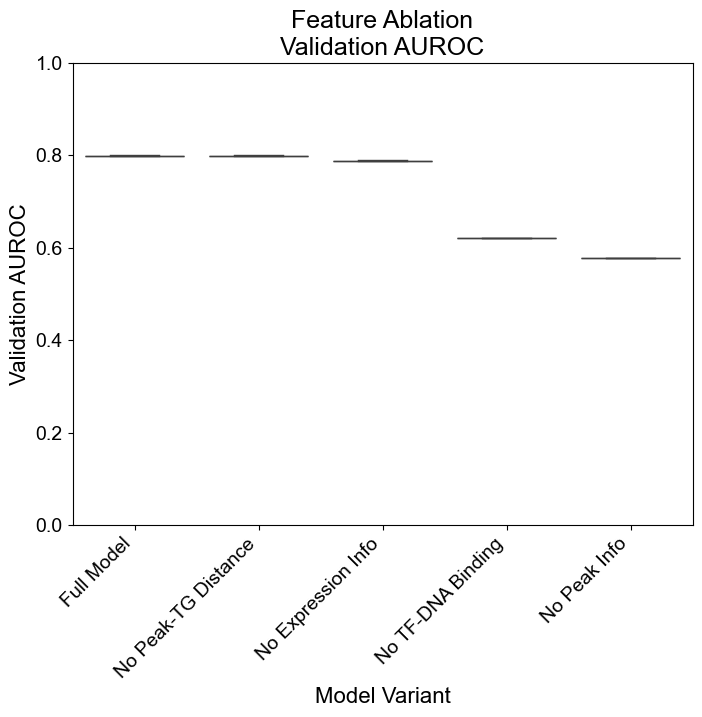

In [ ]:
K562_full_run_df = full_run_df[full_run_df["cell_type"] == "K562"].copy()

K562_ablation_plot_dir = feature_ablation_plot_dir / "K562_feature_ablation_plots"
K562_ablation_plot_dir.mkdir(parents=True, exist_ok=True)

K562_feature_ablation_fig, K562_feature_ablation_ax = plot_feature_ablation_boxplot(K562_full_run_df)
K562_feature_ablation_fig.savefig(K562_ablation_plot_dir / "K562_feature_ablation_boxplot.png", dpi=300, bbox_inches="tight", facecolor="white")

### Macrophage

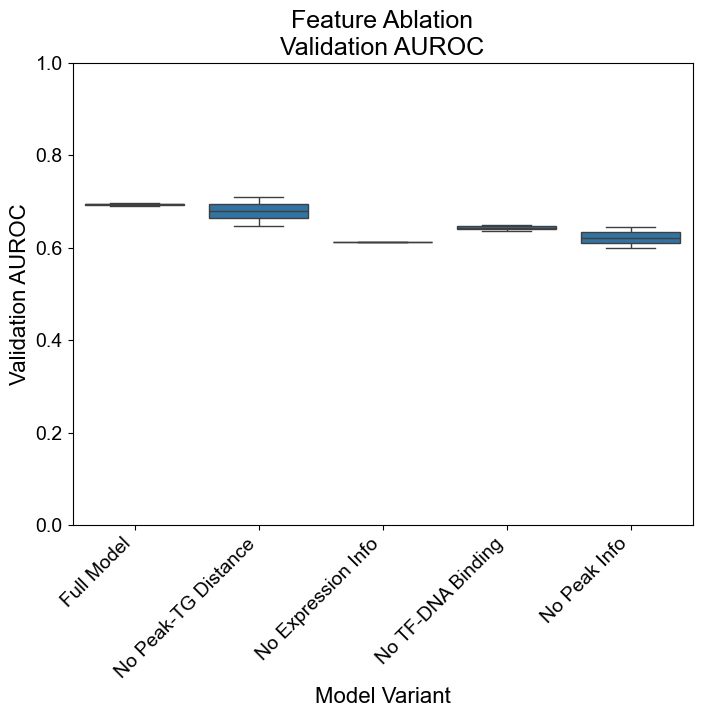

In [ ]:
macrophage_full_run_df = full_run_df[full_run_df["cell_type"] == "Macrophage"].copy()

macrophage_ablation_dir = feature_ablation_plot_dir / "macrophage_feature_ablation_plots"
macrophage_ablation_dir.mkdir(parents=True, exist_ok=True)

macrophage_feature_ablation_fig, macrophage_feature_ablation_ax = plot_feature_ablation_boxplot(macrophage_full_run_df)
macrophage_feature_ablation_fig.savefig(macrophage_ablation_dir / "macrophage_feature_ablation_boxplot.png", dpi=300, bbox_inches="tight", facecolor="white")

---